# Data-driven cooling energy consumption analysis and prediction

## Notebook Setup

### Dependencies

In [1]:
!pip3 install trino sqlalchemy pandas matplotlib seaborn plotly

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 58 kB 1.6 MB/s eta 0:00:011
     |████████████████████████████████| 2.2 MB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 640 kB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 207 kB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 245 kB 911 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


### connection to the DB

In [ ]:
from trino.dbapi import connect
from trino.auth import OAuth2Authentication

try:
    conn = connect(
    )

    print(conn)
    print("✅ Connection object created successfully.")
except Exception as e:
    print("❌ Connection creation failed.")
    print(e)


✅ Connection object created successfully.


In [9]:
# check connection
import pandas as pd

tables = []

try:
    tables = pd.read_sql("SHOW TABLES", conn)
    print("✅ Available tables:")
    display(tables)
except Exception as e:
    print("❌ Could not list tables.")
    print(e)


/var/folders/bx/66bm_m4d7yb4ytknfx69y7780000gp/T/ipykernel_47521/2488069501.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql("SHOW TABLES", conn)


Open the following URL in browser for the external authentication:
https://trino.astra.icp.corproot.net/oauth2/token/initiate/ae19e1643239d7edf601fd1ca0abf6b5b4a8f847ac33a3571e76a05f85cfefc6
✅ Available tables:


,Table
0,datapoint
1,enmos_datapoint
2,measurement
3,measurement_all
4,measuring_point
5,mobnot
6,mobnot_reported_state
7,monitoring_site
8,monitoring_site_model
9,swenex_file_data


## A. Site Selection and Initial Source Qualification

This section identifies the experimental case-study site using lightweight metadata and supporting site-level information before any heavy measurement extraction is performed.

Site candidates are screened using:
- ENMOS signal richness,
- presence of cooling-, energy-, and temperature-related metadata,
- monitoring-site support information,
- and SWENEX utility support where available.

The goal is to choose one site with sufficiently rich cooling-relevant telemetry and supporting operational context for the downstream analysis.

### A1. Source inventory and lightweight metadata setup

In [1482]:
table_info = []
for t in tables['Table']:
    df = pd.read_sql(f"SHOW COLUMNS FROM {t}", conn)
    df['table_name'] = t
    table_info.append(df)

columns_df = pd.concat(table_info, ignore_index=True)
columns_df.to_csv("data/A_Data_Discovery/columns_metadata.csv", index=False)
print("✅ columns_metadata.csv file saved.")


✅ columns_metadata.csv file saved.


In [1483]:
relations = pd.read_csv("data/A_Data_Discovery/tables_relations.csv")
display(relations.head())

,source_table,source_column,target_table,target_column
0,monitoring_site_model,monitoring_site_id,monitoring_site,id
1,enmos_datapoint,site_code,monitoring_site,site_code
2,mobnot_reported_state,mobnot_id,mobnot,mobnot_id
3,swenex_file_data,code,monitoring_site,site_code


### A2. Candidate site screening

In [13]:
import pandas as pd

SCHEMA_NAME = "reporting"
TOP_N_SITES = 10

# ----------------------------
# 1. LOAD LIGHT TABLES
# ----------------------------
monitoring_site = pd.read_sql(f"""
    SELECT id, site_code, path
    FROM {SCHEMA_NAME}.monitoring_site
""", conn)

monitoring_site_model = pd.read_sql(f"""
    SELECT monitoring_site_id
    FROM {SCHEMA_NAME}.monitoring_site_model
""", conn)

enmos_datapoint = pd.read_sql(f"""
    SELECT site_code, name, description, source_class, status, unit
    FROM {SCHEMA_NAME}.enmos_datapoint
""", conn)

datapoint = pd.read_sql(f"""
    SELECT id, measuring_point_id, type, name, description, vendor, device_type, quantity, uom
    FROM {SCHEMA_NAME}.datapoint
""", conn)

measuring_point = pd.read_sql(f"""
    SELECT id, mp_id, type, name, description, vendor, device_type, path
    FROM {SCHEMA_NAME}.measuring_point
""", conn)

# SWENEX light table
swenex = pd.read_sql(f"""
    SELECT
        code,
        location_type,
        customer,
        city,
        canton,
        street,
        house_number,
        from_date,
        to_date,
        total_kwh_consumption,
        total_cost,
        total_price_of_energy,
        total_price_of_network_cost,
        total_price_of_fees
    FROM {SCHEMA_NAME}.swenex_file_data
""", conn)

# ----------------------------
# 2. KEYWORDS (EN + DE)
# ----------------------------
cooling_keywords = [
    "cool", "cooling", "hvac", "ac", "aircon", "chiller", "compressor",
    "vent", "ventilation", "fan", "free cooling", "climate",
    "kühl", "kuehl", "kühlung", "kuehlung", "klima", "klimatisierung",
    "lüft", "lueft", "lüftung", "lueftung", "ventilator", "verdichter"
]

energy_keywords = [
    "energy", "power", "consumption", "electric", "electricity", "load",
    "kw", "kwh", "w", "watt",
    "energie", "verbrauch", "leistung", "strom", "elektrisch", "last"
]

temperature_keywords = [
    "temp", "temperature", "ambient", "room temperature", "outdoor temperature",
    "temperatur", "raumtemperatur", "aussentemperatur", "außentemperatur",
    "innen", "aussen", "außen", "umgebung"
]

status_keywords = [
    "status", "state", "running", "on/off", "alarm", "mode",
    "zustand", "betrieb", "ein", "aus", "störung", "stoerung", "modus"
]

target_keywords = cooling_keywords + energy_keywords
context_keywords = temperature_keywords + status_keywords
all_keywords = target_keywords + context_keywords

# ----------------------------
# 3. HELPERS
# ----------------------------
def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = x.replace("_", " ").replace("-", " ")
    return x

def contains_any(text, keywords):
    return any(k in text for k in keywords)

def count_matches(text, keywords):
    return sum(1 for k in keywords if k in text)

# ----------------------------
# 4. PHASE 1A: SCORE SITES FROM ENMOS_DATAPOINT
# ----------------------------
enmos = enmos_datapoint.copy()

for col in ["site_code", "name", "description", "source_class", "status", "unit"]:
    if col not in enmos.columns:
        enmos[col] = ""

enmos["text"] = (
    enmos["name"].map(normalize_text) + " " +
    enmos["description"].map(normalize_text) + " " +
    enmos["source_class"].map(normalize_text) + " " +
    enmos["status"].map(normalize_text) + " " +
    enmos["unit"].map(normalize_text)
)

enmos["cooling_flag"] = enmos["text"].apply(lambda x: contains_any(x, cooling_keywords))
enmos["energy_flag"] = enmos["text"].apply(lambda x: contains_any(x, energy_keywords))
enmos["temp_flag"] = enmos["text"].apply(lambda x: contains_any(x, temperature_keywords))
enmos["status_flag"] = enmos["text"].apply(lambda x: contains_any(x, status_keywords))

enmos["keyword_score"] = (
    enmos["cooling_flag"].astype(int) * 4 +
    enmos["energy_flag"].astype(int) * 4 +
    enmos["temp_flag"].astype(int) * 3 +
    enmos["status_flag"].astype(int) * 1 +
    enmos["text"].apply(lambda x: count_matches(x, all_keywords))
)

site_score_enmos = (
    enmos.groupby("site_code")
    .agg(
        enmos_total_signals=("site_code", "size"),
        enmos_cooling_signals=("cooling_flag", "sum"),
        enmos_energy_signals=("energy_flag", "sum"),
        enmos_temp_signals=("temp_flag", "sum"),
        enmos_status_signals=("status_flag", "sum"),
        enmos_score=("keyword_score", "sum")
    )
    .reset_index()
)

# ----------------------------
# 5. PHASE 1B: ADD SITE METADATA
# ----------------------------
site_meta = monitoring_site.copy()
site_meta["has_site_model"] = site_meta["id"].isin(monitoring_site_model["monitoring_site_id"]).astype(int)
site_meta["path_text"] = site_meta["path"].map(normalize_text)
site_meta["path_score"] = site_meta["path_text"].apply(lambda x: count_matches(x, all_keywords))
site_meta = site_meta[["site_code", "path", "has_site_model", "path_score"]]

site_ranking = site_score_enmos.merge(site_meta, on="site_code", how="left")

site_ranking["final_score"] = (
    site_ranking["enmos_score"] +
    site_ranking["has_site_model"] * 3 +
    site_ranking["path_score"]
)

site_ranking = site_ranking.sort_values(
    ["final_score", "enmos_energy_signals", "enmos_cooling_signals", "enmos_temp_signals", "enmos_total_signals"],
    ascending=False
).reset_index(drop=True)

print("=== TOP CANDIDATE SITES (METADATA SCORE) ===")
display(site_ranking.head(TOP_N_SITES))

# ----------------------------
# 6. PHASE 1C: SHOW REPRESENTATIVE SIGNALS FOR TOP SITES
# ----------------------------
top_sites = site_ranking.head(TOP_N_SITES)["site_code"].tolist()

top_site_signals = enmos[enmos["site_code"].isin(top_sites)].copy()
top_site_signals = top_site_signals[
    top_site_signals["cooling_flag"] |
    top_site_signals["energy_flag"] |
    top_site_signals["temp_flag"] |
    top_site_signals["status_flag"]
].copy()

top_site_signals = top_site_signals[
    ["site_code", "name", "description", "source_class", "status", "unit",
     "cooling_flag", "energy_flag", "temp_flag", "status_flag", "keyword_score"]
].sort_values(["site_code", "keyword_score"], ascending=[True, False])

print("=== RELEVANT SIGNALS FOR TOP SITES ===")
display(top_site_signals.head(100))

# ----------------------------
# 7. FILTER CANDIDATE SITES
# ----------------------------
candidate_sites = site_ranking[
    (site_ranking["enmos_energy_signals"] >= 1) &
    (site_ranking["enmos_temp_signals"] >= 1)
].copy()

print("=== FILTERED CANDIDATE SITES ===")
display(candidate_sites.head(TOP_N_SITES))

# ----------------------------
# 8. PHASE 2: SWENEX CHECK
# ----------------------------
# Purpose:
# - avoid touching heavy measurement tables
# - see whether candidate site_code exists in SWENEX code
# - get period coverage and cost/consumption magnitude

swenex["code"] = swenex["code"].astype(str)
candidate_site_codes = candidate_sites["site_code"].astype(str).tolist()

swenex_candidate = swenex[swenex["code"].isin(candidate_site_codes)].copy()

swenex_summary = (
    swenex_candidate.groupby("code")
    .agg(
        swenex_rows=("code", "size"),
        swenex_min_from_date=("from_date", "min"),
        swenex_max_to_date=("to_date", "max"),
        swenex_sum_kwh=("total_kwh_consumption", "sum"),
        swenex_sum_total_cost=("total_cost", "sum"),
        swenex_avg_total_cost=("total_cost", "mean"),
        swenex_rows_with_cost=("total_cost", lambda s: s.notna().sum()),
        swenex_rows_with_kwh=("total_kwh_consumption", lambda s: s.notna().sum()),
        swenex_customer=("customer", lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else None),
        swenex_city=("city", lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else None),
        swenex_canton=("canton", lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else None),
        swenex_location_type=("location_type", lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else None)
    )
    .reset_index()
    .rename(columns={"code": "site_code"})
)


# ----------------------------
# 9. COMBINE METADATA + SWENEX
# ----------------------------
final_candidates = candidate_sites.merge(
    swenex_summary,
    on="site_code",
    how="left"
)

# flags
final_candidates["has_swenex_match"] = final_candidates["swenex_rows"].notna().astype(int)
final_candidates["days_covered"] = (
    pd.to_datetime(final_candidates["swenex_max_to_date"]) -
    pd.to_datetime(final_candidates["swenex_min_from_date"])
).dt.days

# final experiment score:
# metadata relevance + presence of SWENEX + cost/consumption support + date coverage
final_candidates["experiment_score"] = (
    final_candidates["final_score"] +
    final_candidates["has_swenex_match"] * 10 +
    final_candidates["days_covered"].fillna(0).clip(upper=365) / 30 +
    final_candidates["swenex_rows_with_cost"].fillna(0).clip(upper=24) / 2 +
    final_candidates["swenex_rows_with_kwh"].fillna(0).clip(upper=24) / 2 +
    final_candidates["swenex_sum_total_cost"].fillna(0).clip(upper=50000) / 5000 +
    final_candidates["swenex_sum_kwh"].fillna(0).clip(upper=500000) / 50000
)

final_candidates = final_candidates.sort_values(
    ["experiment_score", "final_score", "swenex_sum_total_cost", "swenex_sum_kwh"],
    ascending=False
).reset_index(drop=True)

# ----------------------------
# 10. RECOMMENDED SITE
# ----------------------------
recommended_site_code = final_candidates.iloc[0]["site_code"] if not final_candidates.empty else None

print("=== RECOMMENDED SITE FOR EXPERIMENT ===")
print("Recommended site_code:", recommended_site_code)

/var/folders/bx/66bm_m4d7yb4ytknfx69y7780000gp/T/ipykernel_47521/1778667718.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monitoring_site = pd.read_sql(f"""
/var/folders/bx/66bm_m4d7yb4ytknfx69y7780000gp/T/ipykernel_47521/1778667718.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monitoring_site_model = pd.read_sql(f"""
/var/folders/bx/66bm_m4d7yb4ytknfx69y7780000gp/T/ipykernel_47521/1778667718.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  enmos_datapoint = pd.read_sql(f"""
/var/folders/bx/66bm_m4d7yb4ytkn

=== TOP CANDIDATE SITES (METADATA SCORE) ===


,site_code,enmos_total_signals,enmos_cooling_signals,enmos_energy_signals,enmos_temp_signals,enmos_status_signals,enmos_score,path,has_site_model,path_score,final_score
0,790ZHB,567,515,548,4,13,6245,CH.790.ZHB,1,0,6248
1,790LIM,90,89,78,1,10,957,CH.790.LIM,1,0,960


=== RELEVANT SIGNALS FOR TOP SITES ===


,site_code,name,description,source_class,status,unit,cooling_flag,energy_flag,temp_flag,status_flag,keyword_score
58,790LIM,E_UTY_D_30,E_UTY Betrieb (Tageswert) [kWh],MESA_FML,ACTIVE,kW,True,True,False,True,14
593,790LIM,R790LIM_Meteo_RT,Aussentemperatur,MESA_FML,ACTIVE,°C,True,False,True,True,14
6,790LIM,E_ICTEQNE,Energie pro NE [kWh],MESA_FML,ACTIVE,kW,True,True,False,False,13
7,790LIM,E_ICTEQNE_KPI,Energie pro NE [kWh],MESA_FML,ACTIVE,kWh,True,True,False,False,13
8,790LIM,E_ICTEQNE_M,Energie pro NE [kWh],MESA_FML,ACTIVE,kWh,True,True,False,False,13
...,...,...,...,...,...,...,...,...,...,...,...
444,790ZHB,COOL_01_XU02_0214A_K01_K04_K01_J22,COOL KMA Verdichter 3 El.- Leistung,MESA_BOX,ACTIVE,kW,True,True,False,False,14
446,790ZHB,COOL_01_XU02_0214A_K01_K05_K02_J30,COOL KMC Verdichter 1 El.- Leistung,MESA_BOX,ACTIVE,kW,True,True,False,False,14
461,790ZHB,V_E77_RP,E77 Wirkenergie COOL Rückkühler 3-4,MESA_BOX,ACTIVE,kW,True,True,False,False,14
467,790ZHB,V_E91_RZ,E91 Luftaufbereitung Anlage 2 ZUL Ventilator,MESA_BOX,ACTIVE,kWh,True,True,False,False,14


=== FILTERED CANDIDATE SITES ===


,site_code,enmos_total_signals,enmos_cooling_signals,enmos_energy_signals,enmos_temp_signals,enmos_status_signals,enmos_score,path,has_site_model,path_score,final_score
0,790ZHB,567,515,548,4,13,6245,CH.790.ZHB,1,0,6248
1,790LIM,90,89,78,1,10,957,CH.790.LIM,1,0,960


=== RECOMMENDED SITE FOR EXPERIMENT ===
Recommended site_code: 790ZHB


### Site-selection decision

The final site is selected using a combined screening score that prioritizes:
- strong cooling-related signal availability,
- sufficient energy-related signal coverage,
- at least minimal temperature/context support,
- and supporting site-level utility metadata.

The selected site will be used in all later sections for signal qualification, target construction, dataset creation, and forecasting analysis.

**Decision.**  
Site `790ZHB` is selected as the experimental case site because it has the highest combined metadata and SWENEX-based screening score, the richest cooling- and energy-related signal environment, and sufficient supporting site-level information for downstream signal qualification and modeling.

## B. Site Signal Qualification

### B1. Raw Site Signal Load and Cross-Table Mapping

This step loads the selected-site signals from `enmos_datapoint` and `datapoint`, then checks how strongly the two source tables overlap. The goal is to determine whether ENMOS metadata and datapoint-level metadata describe the same signal universe or only partially overlapping subsets.

In [1485]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

SCHEMA_NAME = "reporting"
site_code = recommended_site_code
measuring_point_id = 1

# ----------------------------
# OUTPUT FOLDERS
# ----------------------------
data_dir = Path("data")
section_dir = data_dir / f"B_site_qualification_{site_code}"
csv_dir = section_dir / "csv"
fig_dir = section_dir / "figures"

csv_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# 1. LOAD ENMOS DATAPOINTS
# ----------------------------
enmos_signals = pd.read_sql(f"""
    SELECT
        site_code,
        name,
        description,
        source_class,
        status,
        unit,
        object_id
    FROM {SCHEMA_NAME}.enmos_datapoint
    WHERE site_code = '{site_code}'
""", conn)

# ----------------------------
# 2. LOAD DATAPOINTS
# ----------------------------
datapoint_signals = pd.read_sql(f"""
    SELECT
        measuring_point_id,
        id,
        dp_id,
        name,
        description,
        type,
        vendor,
        device_type,
        quantity,
        uom
    FROM {SCHEMA_NAME}.datapoint
    WHERE measuring_point_id = {measuring_point_id}
""", conn)

# ----------------------------
# 3. SAVE RAW OUTPUTS
# ----------------------------
enmos_signals.to_csv(csv_dir / "enmos_signals_raw.csv", index=False)
datapoint_signals.to_csv(csv_dir / "datapoint_signals_raw.csv", index=False)

print("enmos_datapoint rows:", len(enmos_signals))
print("datapoint rows:", len(datapoint_signals))
print("Saved:", csv_dir / "enmos_signals_raw.csv")
print("Saved:", csv_dir / "datapoint_signals_raw.csv")

enmos_datapoint rows: 567
datapoint rows: 223
Saved: data/B_site_qualification_790ZHB/csv/enmos_signals_raw.csv
Saved: data/B_site_qualification_790ZHB/csv/datapoint_signals_raw.csv


In [1486]:
## MERGE

# ----------------------------
# 1. PREPARE KEYS
# ----------------------------
dp_merge = datapoint_signals.copy()
en_merge = enmos_signals.copy()

dp_merge["dp_id"] = dp_merge["dp_id"].astype(str).str.strip()
en_merge["name"] = en_merge["name"].astype(str).str.strip()

# ----------------------------
# 2. INNER JOIN (MATCHED ONLY)
# ----------------------------
merged_inner = dp_merge.merge(
    en_merge,
    left_on="dp_id",
    right_on="name",
    how="inner",
    suffixes=("_dp", "_enmos")
)

# ----------------------------
# 3. LEFT JOIN (ALL DATAPOINTS)
# ----------------------------
merged_left = dp_merge.merge(
    en_merge,
    left_on="dp_id",
    right_on="name",
    how="left",
    suffixes=("_dp", "_enmos")
)

# ----------------------------
# 4. RIGHT JOIN (ALL ENMOS)
# ----------------------------
merged_right = dp_merge.merge(
    en_merge,
    left_on="dp_id",
    right_on="name",
    how="right",
    suffixes=("_dp", "_enmos")
)

# ----------------------------
# 5. BASIC STATS
# ----------------------------
summary_merge = pd.DataFrame({
    "metric": [
        "datapoint_total",
        "enmos_total",
        "matched_signals_inner",
        "datapoint_without_match",
        "enmos_without_match"
    ],
    "value": [
        len(dp_merge),
        len(en_merge),
        len(merged_inner),
        merged_left["name_enmos"].isna().sum(),
        merged_right["dp_id"].isna().sum()
    ]
})

summary_merge.to_csv(csv_dir / "merge_summary.csv", index=False)

print(summary_merge)

                    metric  value
0          datapoint_total    223
1              enmos_total    567
2    matched_signals_inner    223
3  datapoint_without_match      0
4      enmos_without_match    344


In [4]:
from pathlib import Path

# paths
data_dir = Path("data")
section_dir = data_dir / f"B_site_qualification_790ZHB"
csv_dir = section_dir / "csv"
csv_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
import pandas as pd

# input files
datapoint_path = csv_dir / "datapoint_signals_raw.csv"
enmos_path = csv_dir / "enmos_signals_raw.csv"

# load
datapoint_df = pd.read_csv(datapoint_path)
enmos_df = pd.read_csv(enmos_path)

# keep original copies
dp = datapoint_df.copy()
en = enmos_df.copy()

# normalize join columns
dp["dp_id_norm"] = dp["dp_id"].astype(str).str.strip()
en["name_norm"] = en["name"].astype(str).str.strip()

# anti-join: ENMOS rows not present in datapoint
enmos_without_match = en.merge(
    dp[["dp_id_norm"]],
    left_on="name_norm",
    right_on="dp_id_norm",
    how="left",
    indicator=True
)

enmos_without_match = enmos_without_match[
    enmos_without_match["_merge"] == "left_only"
].drop(columns=["dp_id_norm", "_merge"])

# save result
output_path = csv_dir / "enmos_without_match.csv"
enmos_without_match.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Rows in result: {len(enmos_without_match)}")
display(enmos_without_match.head(20))

Saved: data/B_site_qualification_790ZHB/csv/enmos_without_match.csv
Rows in result: 344


,site_code,name,description,source_class,status,unit,object_id,name_norm
0,790ZHB,COOL_01_XO07_0N750_L01_L01_P01_T02,COOL Annex 2 Summe Strom,MESA_BOX,ACTIVE,kW,234'382,COOL_01_XO07_0N750_L01_L01_P01_T02
1,790ZHB,COOL_01_XO07_0N750_L02_L01_P01_T02,COOL Annex 1 Summe Strom,MESA_BOX,ACTIVE,kW,234'345,COOL_01_XO07_0N750_L02_L01_P01_T02
2,790ZHB,DD_MNG_SANKE_1,MNG Sanke 1,MESA_FML,ACTIVE,kW,215'060,DD_MNG_SANKE_1
3,790ZHB,DD_NOBR_SANKE,Sanke NOBR,MESA_FML,ACTIVE,kW,214'227,DD_NOBR_SANKE
4,790ZHB,DD_T10_SANKE_1,Verbrauch SVA Trafo 10,MESA_FML,ACTIVE,kW,213'593,DD_T10_SANKE_1
5,790ZHB,DD_T10_SANKE_2,Verbrauch Diverses Trafo 10,MESA_FML,ACTIVE,kW,213'509,DD_T10_SANKE_2
6,790ZHB,DD_T3_SANKE_1,Verbrauch SVA Trafo 3,MESA_FML,ACTIVE,kW,213'735,DD_T3_SANKE_1
7,790ZHB,DD_T3_SANKE_2,Verbrauch Diverses Trafo 3,MESA_FML,ACTIVE,kW,213'767,DD_T3_SANKE_2
8,790ZHB,DD_T6_SANKE_1,Verbrauch SVA Trafo 6,MESA_FML,ACTIVE,kW,213'661,DD_T6_SANKE_1
9,790ZHB,DD_T6_SANKE_2,Verbrauch Diverses Trafo 6,MESA_FML,ACTIVE,kW,213'681,DD_T6_SANKE_2


### B2. Measurement-Layer Signal Profiling and Source Consistency Check

This step profiles the mapped datapoint signals in the measurement layer and compares `measurement` with `measurement_all` for the same candidate set. The goal is to verify practical signal availability, temporal coverage, and whether both measurement sources behave consistently for the matched datapoint-based signals.

In [5]:
matched_pool = pd.read_csv(csv_dir / "datapoint_signals_raw.csv")

print(matched_pool.columns.tolist())
print(matched_pool.shape)

candidate_ids = (
    matched_pool["id"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

len(candidate_ids)

['measuring_point_id', 'id', 'dp_id', 'name', 'description', 'type', 'vendor', 'device_type', 'quantity', 'uom']
(223, 10)


223

In [12]:
values_sql = ",\n".join(f"({x})" for x in candidate_ids)

candidate_cte = f"""
candidate_ids (datapoint_id) AS (
    VALUES
    {values_sql}
)
"""

In [14]:
signal_profile = pd.read_sql(f"""
WITH
{candidate_cte},
filtered AS (
    SELECT
        m.datapoint_id,
        m.time,
        CAST(m.value AS double) AS value
    FROM {SCHEMA_NAME}.measurement m
    INNER JOIN candidate_ids c
        ON m.datapoint_id = c.datapoint_id
    WHERE m.value IS NOT NULL
        AND m.time >= TIMESTAMP '2025-01-01 00:00:00 UTC'
        AND m.time < TIMESTAMP '2025-03-01 00:00:00 UTC'
)
SELECT
    datapoint_id,
    COUNT(*) AS n_obs,
    MIN(time) AS start_ts,
    MAX(time) AS end_ts,
    AVG(value) AS mean_value,
    STDDEV(value) AS std_value,
    MIN(value) AS min_value,
    MAX(value) AS max_value,
    APPROX_DISTINCT(value) AS approx_n_distinct,
    AVG(CASE WHEN value = 0 THEN 1.0 ELSE 0.0 END) AS zero_ratio,
    APPROX_PERCENTILE(value, 0.25) AS q25,
    APPROX_PERCENTILE(value, 0.50) AS median_value,
    APPROX_PERCENTILE(value, 0.75) AS q75
FROM filtered
GROUP BY datapoint_id
ORDER BY n_obs DESC
""", conn)

signal_profile.to_csv(csv_dir / "signal_profile_2025.csv", index=False)
signal_profile.head()

/var/folders/bx/66bm_m4d7yb4ytknfx69y7780000gp/T/ipykernel_47521/580980614.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signal_profile = pd.read_sql(f"""


,datapoint_id,n_obs,start_ts,end_ts,mean_value,std_value,min_value,max_value,approx_n_distinct,zero_ratio,q25,median_value,q75
0,202,1271301,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,180.532405,34.602385,0.000000,1.767472e+03,3703,0.0,170.030273,185.337912,197.831985
1,206,1271301,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,168.764927,33.768584,0.124307,1.257910e+03,3512,0.0,158.564423,173.744009,185.945449
2,152,1271300,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,163.516005,33.646967,0.000000,1.134576e+03,3339,0.0,154.094132,170.001547,180.921127
3,140,1271299,2025-01-01 00:00:03+00:00,2025-02-28 23:59:59+00:00,766.488454,74.784532,694.585876,1.159869e+03,5578,0.0,714.935218,731.283533,800.992148
4,161,1271299,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,1770.396202,435534.803928,0.157691,1.559596e+08,5163,0.0,232.938424,247.100407,266.116055


In [1493]:
import pandas as pd
import numpy as np
from pathlib import Path

signal_profile = pd.read_csv(csv_dir / "signal_profile_2025.csv")

# timestamps
signal_profile["start_ts"] = pd.to_datetime(signal_profile["start_ts"], errors="coerce")
signal_profile["end_ts"] = pd.to_datetime(signal_profile["end_ts"], errors="coerce")

# derived metrics
signal_profile["coverage_days"] = (
    signal_profile["end_ts"] - signal_profile["start_ts"]
).dt.total_seconds() / 86400

signal_profile["value_range"] = signal_profile["max_value"] - signal_profile["min_value"]

# coefficient of variation: std / |mean|
signal_profile["cv"] = np.where(
    signal_profile["mean_value"].abs() > 1e-9,
    signal_profile["std_value"] / signal_profile["mean_value"].abs(),
    np.nan
)

signal_profile.head()

,datapoint_id,n_obs,start_ts,end_ts,mean_value,std_value,min_value,max_value,approx_n_distinct,zero_ratio,q25,median_value,q75,coverage_days,value_range,cv
0,202,1271301,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,180.532405,34.602385,0.000000,1.767472e+03,3703,0.0,170.030273,185.337912,197.831985,58.999942,1.767472e+03,0.191669
1,206,1271301,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,168.764927,33.768584,0.124307,1.257910e+03,3512,0.0,158.564423,173.744009,185.945449,58.999942,1.257785e+03,0.200092
2,152,1271300,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,163.516005,33.646967,0.000000,1.134576e+03,3339,0.0,154.094132,170.001547,180.921127,58.999942,1.134576e+03,0.205772
3,132,1271299,2025-01-01 00:00:03+00:00,2025-02-28 23:59:59+00:00,807.776027,77.265972,726.369751,1.174822e+03,5643,0.0,755.418903,770.961925,844.682627,58.999954,4.484520e+02,0.095653
4,161,1271299,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,1770.396202,435534.803928,0.157691,1.559596e+08,5163,0.0,232.938424,247.100407,266.116055,58.999942,1.559596e+08,246.009793


In [1495]:
signal_profile_all = pd.read_sql(f"""
WITH
{candidate_cte},
filtered AS (
    SELECT
        m.datapoint_id,
        m.time,
        CAST(m.value AS double) AS value
    FROM {SCHEMA_NAME}.measurement_all m
    INNER JOIN candidate_ids c
        ON m.datapoint_id = c.datapoint_id
    WHERE m.site_code = '{site_code}'
      AND m.time >= TIMESTAMP '2025-01-01 00:00:00 UTC'
      AND m.time < TIMESTAMP '2025-03-01 00:00:00 UTC'
      AND m.value IS NOT NULL
)
SELECT
    datapoint_id,
    COUNT(*) AS n_obs,
    MIN(time) AS start_ts,
    MAX(time) AS end_ts,
    AVG(value) AS mean_value,
    STDDEV(value) AS std_value,
    MIN(value) AS min_value,
    MAX(value) AS max_value,
    APPROX_DISTINCT(value) AS approx_n_distinct,
    AVG(CASE WHEN value = 0 THEN 1.0 ELSE 0.0 END) AS zero_ratio
FROM filtered
GROUP BY datapoint_id
ORDER BY n_obs DESC
""", conn)

signal_profile_all.head()

,datapoint_id,n_obs,start_ts,end_ts,mean_value,std_value,min_value,max_value,approx_n_distinct,zero_ratio
0,206,1271301,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,168.764927,33.768584,0.124307,1.257910e+03,3512,0.0
1,202,1271301,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,180.532405,34.602385,0.000000,1.767472e+03,3703,0.0
2,152,1271300,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,163.516005,33.646967,0.000000,1.134576e+03,3339,0.0
3,161,1271299,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,1770.396202,435534.803928,0.157691,1.559596e+08,5163,0.0
4,108,1271299,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,2121.088719,553452.965598,0.069549,1.975921e+08,4879,0.0


In [1496]:
signal_profile_all.to_csv(csv_dir / "signal_profile_measurement_all_2025.csv", index=False)
print("saved:", csv_dir / "signal_profile_measurement_all_2025.csv")

saved: data/B_site_qualification_790ZHB/csv/signal_profile_measurement_all_2025.csv


In [10]:
import pandas as pd
import numpy as np

m = pd.read_csv(csv_dir / "signal_profile_2025.csv")
a = pd.read_csv(csv_dir / "signal_profile_measurement_all_2025.csv")

print("measurement:", m.shape)
print("measurement_all:", a.shape)

measurement: (111, 13)
measurement_all: (111, 10)


In [1498]:
for df in [m, a]:
    df["start_ts"] = pd.to_datetime(df["start_ts"], errors="coerce")
    df["end_ts"] = pd.to_datetime(df["end_ts"], errors="coerce")

In [1499]:
cmp = m.merge(
    a,
    on="datapoint_id",
    how="outer",
    suffixes=("_m", "_a"),
    indicator=True
)

print(cmp["_merge"].value_counts(dropna=False))
cmp.head()

_merge
both          111
left_only       0
right_only      0
Name: count, dtype: int64


,datapoint_id,n_obs_m,start_ts_m,end_ts_m,mean_value_m,std_value_m,min_value_m,max_value_m,approx_n_distinct_m,zero_ratio_m,...,n_obs_a,start_ts_a,end_ts_a,mean_value_a,std_value_a,min_value_a,max_value_a,approx_n_distinct_a,zero_ratio_a,_merge
0,1,5664,2025-01-01 00:00:00+00:00,2025-02-28 23:45:00+00:00,4.933567e+03,19.251091,4.900305e+03,4.966847e+03,125,0.0,...,5664,2025-01-01 00:00:00+00:00,2025-02-28 23:45:00+00:00,4.933567e+03,19.251091,4.900305e+03,4.966847e+03,125,0.0,both
1,2,5664,2025-01-01 00:00:00+00:00,2025-02-28 23:45:00+00:00,2.023469e+06,11435.300124,2.005182e+06,2.043630e+06,5741,0.0,...,5664,2025-01-01 00:00:00+00:00,2025-02-28 23:45:00+00:00,2.023469e+06,11435.300124,2.005182e+06,2.043630e+06,5741,0.0,both
2,4,5647,2025-01-01 00:01:08+00:00,2025-02-28 23:46:16+00:00,2.185586e+02,30.719135,4.868430e-01,7.415314e+02,1299,0.0,...,5647,2025-01-01 00:01:08+00:00,2025-02-28 23:46:16+00:00,2.185586e+02,30.719135,4.868430e-01,7.415314e+02,1299,0.0,both
3,8,5645,2025-01-01 00:01:20+00:00,2025-02-28 23:45:04+00:00,2.354791e+02,25.795468,2.781960e-01,6.660708e+02,1216,0.0,...,5645,2025-01-01 00:01:20+00:00,2025-02-28 23:45:04+00:00,2.354791e+02,25.795468,2.781960e-01,6.660708e+02,1216,0.0,both
4,14,5646,2025-01-01 00:01:20+00:00,2025-02-28 23:47:25+00:00,1.624790e+02,29.860723,2.781960e-01,8.483587e+02,1303,0.0,...,5646,2025-01-01 00:01:20+00:00,2025-02-28 23:47:25+00:00,1.624790e+02,29.860723,2.781960e-01,8.483587e+02,1303,0.0,both


### ENMOS-only signal availability probe

This check probes ENMOS-only signals that are not present in the datapoint table. Because these signals do not have `datapoint_id`, they cannot be queried through the `measurement` table directly. A string-based lookup is therefore attempted only against `measurement_all`.

In [1500]:
import pandas as pd
import numpy as np

enmos_only = pd.read_csv(csv_dir / "enmos_without_match.csv")
print(enmos_only.shape)
print(enmos_only.columns.tolist())
enmos_only.head()

(344, 8)
['site_code', 'name', 'description', 'source_class', 'status', 'unit', 'object_id', 'name_norm']


,site_code,name,description,source_class,status,unit,object_id,name_norm
0,790ZHB,COOL_01_XO07_0N750_L01_L01_P01_T02,COOL Annex 2 Summe Strom,MESA_BOX,ACTIVE,kW,234'382,COOL_01_XO07_0N750_L01_L01_P01_T02
1,790ZHB,COOL_01_XO07_0N750_L02_L01_P01_T02,COOL Annex 1 Summe Strom,MESA_BOX,ACTIVE,kW,234'345,COOL_01_XO07_0N750_L02_L01_P01_T02
2,790ZHB,DD_MNG_SANKE_1,MNG Sanke 1,MESA_FML,ACTIVE,kW,215'060,DD_MNG_SANKE_1
3,790ZHB,DD_NOBR_SANKE,Sanke NOBR,MESA_FML,ACTIVE,kW,214'227,DD_NOBR_SANKE
4,790ZHB,DD_T10_SANKE_1,Verbrauch SVA Trafo 10,MESA_FML,ACTIVE,kW,213'593,DD_T10_SANKE_1


In [1501]:
enmos_names = (
    enmos_only["name"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

print("ENMOS-only names:", len(enmos_names))
print(enmos_names[:10])

ENMOS-only names: 344
['COOL_01_XO07_0N750_L01_L01_P01_T02', 'COOL_01_XO07_0N750_L02_L01_P01_T02', 'DD_MNG_SANKE_1', 'DD_NOBR_SANKE', 'DD_T10_SANKE_1', 'DD_T10_SANKE_2', 'DD_T3_SANKE_1', 'DD_T3_SANKE_2', 'DD_T6_SANKE_1', 'DD_T6_SANKE_2']


In [1502]:
def sql_escape_string(x):
    return "'" + str(x).replace("'", "''") + "'"

values_sql = ",\n".join(f"({sql_escape_string(x)})" for x in enmos_names)

enmos_cte = f"""
enmos_names (signal_name) AS (
    VALUES
    {values_sql}
)
"""

signal_name_col = "dp_id"

In [ ]:
signal_profile_enmos_only = pd.read_sql(f"""
WITH
{enmos_cte},
filtered AS (
    SELECT
        CAST(m.{signal_name_col} AS varchar) AS signal_name,
        m.time,
        CAST(m.value AS double) AS value
    FROM {SCHEMA_NAME}.measurement_all m
    INNER JOIN enmos_names e
        ON CAST(m.{signal_name_col} AS varchar) = e.signal_name
    WHERE m.value IS NOT NULL
        AND m.time >= from_iso8601_timestamp('2025-01-01T00:00:00Z')
        AND m.time < from_iso8601_timestamp('2025-03-01T00:00:00Z')
)
SELECT
    signal_name,
    COUNT(*) AS n_obs,
    MIN(time) AS start_ts,
    MAX(time) AS end_ts,
    AVG(value) AS mean_value,
    STDDEV(value) AS std_value,
    MIN(value) AS min_value,
    MAX(value) AS max_value,
    APPROX_DISTINCT(value) AS approx_n_distinct,
    AVG(CASE WHEN value = 0 THEN 1.0 ELSE 0.0 END) AS zero_ratio
FROM filtered
GROUP BY signal_name
ORDER BY n_obs DESC
""", conn)

signal_profile_enmos_only.head()

,signal_name,n_obs,start_ts,end_ts,mean_value,std_value,min_value,max_value,approx_n_distinct,zero_ratio


The ENMOS-only probe returned no matches in the tested `measurement_all` lookup. This result should be interpreted cautiously: it does not prove true signal absence, but indicates that ENMOS-only metadata names could not be confirmed as directly retrievable measurement-layer signals under the current string-based mapping. For the downstream experiment, the analysis therefore remains anchored on the datapoint-mapped signal set.

### B3. Signal Inventory and Hourly Ecosystem Profiling

This step moves from source-table mapping to signal-level qualification. The goal is to build a compact inventory of the datapoint-mapped signals, summarize their temporal coverage and variability, and convert them into an hourly signal matrix for further ecosystem analysis.

At this stage, the purpose is still exploratory: to understand what signal families are available, how complete they are over time, and whether the selected datapoint-based signal set is rich enough to support target definition and downstream modeling.

In [1504]:
import pandas as pd
import numpy as np

signal_profile = pd.read_csv(csv_dir / "signal_profile_2025.csv")
matched_pool = pd.read_csv(csv_dir / "datapoint_signals_raw.csv")

print(signal_profile.shape)
print(matched_pool.shape)
print(signal_profile.columns.tolist())
print(matched_pool.columns.tolist())

(111, 13)
(223, 10)
['datapoint_id', 'n_obs', 'start_ts', 'end_ts', 'mean_value', 'std_value', 'min_value', 'max_value', 'approx_n_distinct', 'zero_ratio', 'q25', 'median_value', 'q75']
['measuring_point_id', 'id', 'dp_id', 'name', 'description', 'type', 'vendor', 'device_type', 'quantity', 'uom']


In [1505]:
candidate_ids = (
    matched_pool["id"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

values_sql = ",\n".join(f"({x})" for x in candidate_ids)

candidate_cte = f"""
candidate_ids (datapoint_id) AS (
    VALUES
    {values_sql}
)
"""

In [1506]:
datapoint_meta = pd.read_sql(f"""
WITH
{candidate_cte}
SELECT
    d.id AS datapoint_id,
    d.dp_id,
    d.type,
    d.name,
    d.description,
    d.vendor,
    d.device_type,
    d.quantity,
    d.uom,
    d.measuring_point_id
FROM {SCHEMA_NAME}.datapoint d
INNER JOIN candidate_ids c
    ON d.id = c.datapoint_id
""", conn)

datapoint_meta.head()

,datapoint_id,dp_id,type,name,description,vendor,device_type,quantity,uom,measuring_point_id
0,1,V_E86_RZ,UNK,Wirkenergie COOL Ringleitung 1,E86 Wirkenergie COOL Ringleitung 1,NaN,None,PWR,KWT,1
1,2,V_E51_RZ,PMTR,Wirkenergie Restaurant,E51 Wirkenergie Restaurant,NaN,None,PWR,KWH,1
2,3,V_E06B_RP,TRF,E06B Blindenergie Trafo T6 U200,NaN,NaN,None,PWR,KWT,1
3,4,V_E07_I1_15_RX,TRF,E07 Wirkenergie Trafo T7 U200 Phasenstrom L1,NaN,NaN,None,PWR,KWT,1
4,5,V_E83_RP,UNK,Wirkenergie COOL KM Klima,E83 Wirkenergie COOL KM Klima,NaN,None,PWR,KWT,1


In [1507]:
signal_inventory = signal_profile.merge(
    datapoint_meta,
    on="datapoint_id",
    how="left"
)

signal_inventory["start_ts"] = pd.to_datetime(signal_inventory["start_ts"], errors="coerce")
signal_inventory["end_ts"] = pd.to_datetime(signal_inventory["end_ts"], errors="coerce")

signal_inventory["coverage_days"] = (
    signal_inventory["end_ts"] - signal_inventory["start_ts"]
).dt.total_seconds() / 86400

signal_inventory["value_range"] = (
    signal_inventory["max_value"] - signal_inventory["min_value"]
)

signal_inventory.to_csv(csv_dir / "signal_inventory_2025.csv", index=False)

print(signal_inventory.shape)
signal_inventory.head()

(111, 24)


,datapoint_id,n_obs,start_ts,end_ts,mean_value,std_value,min_value,max_value,approx_n_distinct,zero_ratio,...,type,name,description,vendor,device_type,quantity,uom,measuring_point_id,coverage_days,value_range
0,202,1271301,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,180.532405,34.602385,0.000000,1.767472e+03,3703,0.0,...,TRF,E04 Wirkenergie Trafo T3 U200 Phasenstrom L1,NaN,NaN,None,PWR,KWT,1,58.999942,1.767472e+03
1,206,1271301,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,168.764927,33.768584,0.124307,1.257910e+03,3512,0.0,...,TRF,E04 Wirkenergie Trafo T3 U200 Phasenstrom L2,NaN,NaN,None,PWR,KWT,1,58.999942,1.257785e+03
2,152,1271300,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,163.516005,33.646967,0.000000,1.134576e+03,3339,0.0,...,TRF,E04 Wirkenergie Trafo T3 U200 Phasenstrom L3,NaN,NaN,None,PWR,KWT,1,58.999942,1.134576e+03
3,132,1271299,2025-01-01 00:00:03+00:00,2025-02-28 23:59:59+00:00,807.776027,77.265972,726.369751,1.174822e+03,5643,0.0,...,TRF,E08 Wirkenergie Trafo T9 U200 Phasenstrom L2,NaN,NaN,None,PWR,KWT,1,58.999954,4.484520e+02
4,161,1271299,2025-01-01 00:00:03+00:00,2025-02-28 23:59:58+00:00,1770.396202,435534.803928,0.157691,1.559596e+08,5163,0.0,...,TRF,E06 Wirkenergie Trafo T6 U200 Phasenstrom L2,NaN,NaN,None,PWR,KWT,1,58.999942,1.559596e+08


The resulting `signal_inventory` combines measurement-layer profiling with datapoint metadata. It provides a compact view of signal identity, temporal coverage, variability, and units, and serves as the main reference table for subsequent target and feature selection.

In [1508]:
exploration_pool = signal_inventory.copy()

print("exploration_pool:", exploration_pool.shape[0])

exploration_pool[[
    "datapoint_id", "dp_id", "name", "description",
    "uom", "n_obs", "coverage_days", "std_value"
]].sort_values(
    ["n_obs", "coverage_days"],
    ascending=[False, False]
)

exploration_pool: 111


,datapoint_id,dp_id,name,description,uom,n_obs,coverage_days,std_value
0,202,V_E04_I1_RX,E04 Wirkenergie Trafo T3 U200 Phasenstrom L1,NaN,KWT,1271301,58.999942,34.602385
1,206,V_E04_I2_RX,E04 Wirkenergie Trafo T3 U200 Phasenstrom L2,NaN,KWT,1271301,58.999942,33.768584
2,152,V_E04_I3_RX,E04 Wirkenergie Trafo T3 U200 Phasenstrom L3,NaN,KWT,1271300,58.999942,33.646967
3,132,V_E08_I2_RX,E08 Wirkenergie Trafo T9 U200 Phasenstrom L2,NaN,KWT,1271299,58.999954,77.265972
6,140,V_E08_I3_RX,E08 Wirkenergie Trafo T9 U200 Phasenstrom L3,NaN,KWT,1271299,58.999954,74.784532
...,...,...,...,...,...,...,...,...
106,8,V_E07_I2_15_RX,E07 Wirkenergie Trafo T7 U200 Phasenstrom L2,NaN,KWT,5645,58.988704,25.795468
107,32,V_E06_I1_15_RX,E06 Wirkenergie Trafo T6 U200 Phasenstrom L1,NaN,KWT,5644,58.979282,733.878968
108,85,CH1010001234500000000000000001605,NaN,E01 Wirkenergie Gesamt,KWH,5467,58.989583,88.377753
109,135,R790ZHB_Meteo_RT,NaN,Aussentemperatur,CEL,295,58.958333,3.681660


In [1509]:
print("Compact shape:", compact_df.shape)
print("Expanded shape:", expanded_df.shape)

compact_X = compact_df.drop(columns=["site_code", "time", "target"], errors="ignore")
expanded_X = expanded_df.drop(columns=["site_code", "time", "target"], errors="ignore")

print("Compact NaNs total:", compact_X.isna().sum().sum())
print("Expanded NaNs total:", expanded_X.isna().sum().sum())

print("Compact rows with any NaN:", compact_X.isna().any(axis=1).sum())
print("Expanded rows with any NaN:", expanded_X.isna().any(axis=1).sum())

Compact shape: (8587, 51)
Expanded shape: (8587, 103)
Compact NaNs total: 1625
Expanded NaNs total: 3655
Compact rows with any NaN: 145
Expanded rows with any NaN: 145


In [1510]:
short_ids = (
    exploration_pool["datapoint_id"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

print("short_ids:", len(short_ids))

short_ids: 111


In [1511]:
values_sql = ",\n".join(f"({x})" for x in short_ids)

short_cte = f"""
candidate_ids (datapoint_id) AS (
    VALUES
    {values_sql}
)
"""

In [1512]:
hourly_parts = []
month_ranges = [
    ("2025-01-01T00:00:00Z", "2025-02-01T00:00:00Z"),
    ("2025-02-01T00:00:00Z", "2025-03-01T00:00:00Z"),
    ("2025-03-01T00:00:00Z", "2025-04-01T00:00:00Z"),
    ("2025-04-01T00:00:00Z", "2025-05-01T00:00:00Z"),
    ("2025-05-01T00:00:00Z", "2025-06-01T00:00:00Z"),
    ("2025-06-01T00:00:00Z", "2025-07-01T00:00:00Z"),
    ("2025-07-01T00:00:00Z", "2025-08-01T00:00:00Z"),
    ("2025-08-01T00:00:00Z", "2025-09-01T00:00:00Z"),
    ("2025-09-01T00:00:00Z", "2025-10-01T00:00:00Z"),
    ("2025-10-01T00:00:00Z", "2025-11-01T00:00:00Z"),
    ("2025-11-01T00:00:00Z", "2025-12-01T00:00:00Z"),
    ("2025-12-01T00:00:00Z", "2026-01-01T00:00:00Z"),
]

for start_iso, end_iso in month_ranges:
    print("loading:", start_iso, "to", end_iso)

    part = pd.read_sql(f"""
    WITH
    {short_cte},
    filtered AS (
        SELECT
            m.datapoint_id,
            date_trunc('hour', m.time) AS ts_hour,
            CAST(m.value AS double) AS value
        FROM {SCHEMA_NAME}.measurement m
        INNER JOIN candidate_ids c
            ON m.datapoint_id = c.datapoint_id
        WHERE m.value IS NOT NULL
          AND m.time >= from_iso8601_timestamp('{start_iso}')
          AND m.time < from_iso8601_timestamp('{end_iso}')
    )
    SELECT
        datapoint_id,
        ts_hour,
        AVG(value) AS value_hour
    FROM filtered
    GROUP BY datapoint_id, ts_hour
    ORDER BY datapoint_id, ts_hour
    """, conn)

    hourly_parts.append(part)
    print(part.shape)

loading: 2025-01-01T00:00:00Z to 2025-02-01T00:00:00Z
(81383, 3)
loading: 2025-02-01T00:00:00Z to 2025-03-01T00:00:00Z
(73505, 3)
loading: 2025-03-01T00:00:00Z to 2025-04-01T00:00:00Z
(81382, 3)
loading: 2025-04-01T00:00:00Z to 2025-05-01T00:00:00Z
(79099, 3)
loading: 2025-05-01T00:00:00Z to 2025-06-01T00:00:00Z
(81486, 3)
loading: 2025-06-01T00:00:00Z to 2025-07-01T00:00:00Z
(76695, 3)
loading: 2025-07-01T00:00:00Z to 2025-08-01T00:00:00Z
(79050, 3)
loading: 2025-08-01T00:00:00Z to 2025-09-01T00:00:00Z
(73718, 3)
loading: 2025-09-01T00:00:00Z to 2025-10-01T00:00:00Z
(76596, 3)
loading: 2025-10-01T00:00:00Z to 2025-11-01T00:00:00Z
(78968, 3)
loading: 2025-11-01T00:00:00Z to 2025-12-01T00:00:00Z
(78780, 3)
loading: 2025-12-01T00:00:00Z to 2026-01-01T00:00:00Z
(81383, 3)


In [15]:
hourly_long = pd.concat(hourly_parts, ignore_index=True)

hourly_long["ts_hour"] = pd.to_datetime(hourly_long["ts_hour"], errors="coerce")

hourly_long.to_csv(csv_dir / "hourly_long_2025_exploration.csv", index=False)
hourly_long.head()
print(hourly_long.shape)
print(hourly_long.columns.tolist())

NameError: name 'hourly_parts' is not defined

In [40]:
hourly_long = pd.read_csv(csv_dir / "hourly_long_2025_exploration.csv")

hourly_long["ts_hour"] = pd.to_datetime(hourly_long["ts_hour"], errors="coerce")
hourly_long = hourly_long.dropna(subset=["datapoint_id", "ts_hour", "value_hour"])

hourly_long["datapoint_id"] = hourly_long["datapoint_id"].astype(int)

hourly_long.head(5)

,datapoint_id,ts_hour,value_hour
0,1,2025-01-01 00:00:00+00:00,4900.304688
1,1,2025-01-01 01:00:00+00:00,4900.304688
2,1,2025-01-01 02:00:00+00:00,4900.304688
3,1,2025-01-01 03:00:00+00:00,4900.304688
4,1,2025-01-01 04:00:00+00:00,4900.304688


In [41]:
hourly_summary = (
    hourly_long.groupby("datapoint_id")
    .agg(
        n_hours=("value_hour", "size"),
        start_ts=("ts_hour", "min"),
        end_ts=("ts_hour", "max"),
        mean_value=("value_hour", "mean"),
        std_value=("value_hour", "std"),
        min_value=("value_hour", "min"),
        max_value=("value_hour", "max"),
    )
    .reset_index()
)

hourly_summary["coverage_days"] = (
    hourly_summary["end_ts"] - hourly_summary["start_ts"]
).dt.total_seconds() / 86400

hourly_summary["value_range"] = hourly_summary["max_value"] - hourly_summary["min_value"]

hourly_summary = hourly_summary.sort_values(
    ["n_hours", "coverage_days"],
    ascending=[False, False]
)

print(hourly_summary["n_hours"].describe())
print(hourly_summary["coverage_days"].describe())

hourly_summary.to_csv(csv_dir / "hourly_summary_2025.csv", index=False)

count     111.000000
mean     8486.891892
std       883.407549
min      2006.000000
25%      8611.000000
50%      8611.000000
75%      8611.000000
max      8611.000000
Name: n_hours, dtype: float64
count    1.110000e+02
mean     3.649583e+02
std      2.284049e-13
min      3.649583e+02
25%      3.649583e+02
50%      3.649583e+02
75%      3.649583e+02
max      3.649583e+02
Name: coverage_days, dtype: float64


The hourly summary confirms that the retained datapoint-based signal set is available at broad annual coverage after hourly aggregation. This supports using the datapoint-mapped signal universe as the main basis for target construction and feature engineering.

In [42]:
pivot = hourly_long.pivot(
    index="ts_hour",
    columns="datapoint_id",
    values="value_hour"
)

print(pivot.shape)
pivot.head()

(8711, 111)


datapoint_id,1,2,4,8,14,15,18,19,21,23,...,213,215,216,221,223,226,230,232,233,235
ts_hour,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,4900.304688,2.005186e+06,275.031525,215.688839,162.640339,0.252033,5.35437,696377.5625,3.185278,0.0,...,854764.0,150383.984375,25641121.0,1258628.875,0.230063,244021.781250,69177908.0,92781256.0,1.208697e+06,0.243889
2025-01-01 01:00:00+00:00,4900.304688,2.005196e+06,276.457283,214.802094,157.893623,0.252033,5.35437,696377.5625,0.000000,0.0,...,854764.0,150384.484375,25641269.0,1258874.000,0.230063,244028.031250,69178632.0,92783002.0,1.208703e+06,0.000000
2025-01-01 02:00:00+00:00,4900.304688,2.005206e+06,269.867516,222.835007,151.251690,0.252033,5.35437,696377.5625,0.000000,0.0,...,854764.0,150384.484375,25641415.0,1258874.000,0.230063,244034.531250,69179316.0,92784842.0,1.208710e+06,0.000000
2025-01-01 03:00:00+00:00,4900.304688,2.005216e+06,278.230789,227.320915,155.337696,0.252033,5.35437,696377.5625,0.000000,0.0,...,854764.0,150384.484375,25641563.5,1258874.000,0.230063,244040.757812,69179998.0,92786580.0,1.208717e+06,0.000000
2025-01-01 04:00:00+00:00,4900.304688,2.005226e+06,275.813950,229.459545,151.425564,0.252033,5.35437,696377.5625,0.000000,0.0,...,854764.0,150384.484375,25641713.0,1258874.000,0.230063,244047.207031,69180846.0,92788424.0,1.208723e+06,0.000000


In [43]:
missing_ratio = pivot.isna().mean()

missing_ratio.describe()

count    111.000000
mean       0.025727
std        0.101413
min        0.011480
25%        0.011480
50%        0.011480
75%        0.011480
max        0.769716
dtype: float64

The hourly pivot table represents the selected site as a multivariate hourly signal matrix. Most signals show very low missingness, while only a small number exhibit substantially higher gaps. This indicates that the selected datapoint-based signal set is sufficiently stable for downstream target-definition analysis.

Section B established the selected site's signal ecosystem at the datapoint and measurement layers. The datapoint-mapped signal set was shown to have strong overlap with ENMOS naming, broad hourly coverage, and acceptable completeness for downstream analysis. The resulting signal inventory and hourly matrix provide the basis for the next step: selecting the final cooling target components and constructing the modeling dataset.

## C. Target and Dataset Construction

### C1. Cooling target candidate review

At this stage, the goal is not yet to define the final target mechanically, but to identify a shortlist of cooling-related cumulative energy signals that are plausible target components.

The shortlist is constructed from the signal inventory using:
- cooling-related semantic labels,
- strong temporal coverage,
- stable hourly availability,
- high variability / non-trivial dynamics,
- and correlation structure suggesting membership in the same cooling subsystem environment.

The resulting candidate set is therefore expert-guided and review-based rather than fully automatic.

In [44]:
# 1. Correlation -> long format
corr = pivot.corr(method="pearson")

corr_long = (
    corr.rename_axis(index="id_a", columns="id_b")
        .stack()
        .reset_index(name="corr")
)

# 2. Remove self-pairs
corr_long = corr_long[corr_long["id_a"] != corr_long["id_b"]].copy()

# 3. Absolute correlation
corr_long["abs_corr"] = corr_long["corr"].abs()

# 4. Remove mirrored duplicates
corr_long["pair"] = corr_long.apply(
    lambda r: tuple(sorted([r["id_a"], r["id_b"]])),
    axis=1
)

top_corr = (
    corr_long
    .drop_duplicates("pair")
    .sort_values(["abs_corr", "corr"], ascending=[False, False])
    .drop(columns=["pair"])
    .reset_index(drop=True)
)

print(top_corr.shape)
top_corr.head()

(6105, 4)


,id_a,id_b,corr,abs_corr
0,49,78,0.999999,0.999999
1,72,161,0.999997,0.999997
2,72,108,0.999995,0.999995
3,46,201,0.999994,0.999994
4,108,161,0.999991,0.999991


In [45]:
signal_inventory = pd.read_csv(csv_dir / "signal_inventory_2025.csv")

meta = signal_inventory[[
    "datapoint_id", "dp_id", "name", "description", "uom"
]].drop_duplicates()

top_named = (
    top_corr
    .merge(meta, left_on="id_a", right_on="datapoint_id", how="left")
    .rename(columns={
        "dp_id": "dp_id_a",
        "name": "name_a",
        "description": "description_a",
        "uom": "uom_a"
    })
    .drop(columns=["datapoint_id"])
)

top_named = (
    top_named
    .merge(meta, left_on="id_b", right_on="datapoint_id", how="left")
    .rename(columns={
        "dp_id": "dp_id_b",
        "name": "name_b",
        "description": "description_b",
        "uom": "uom_b"
    })
    .drop(columns=["datapoint_id"])
)

print(top_named.shape)
top_named.head(20)

(6105, 12)


,id_a,id_b,corr,abs_corr,dp_id_a,name_a,description_a,uom_a,dp_id_b,name_b,description_b,uom_b
0,49,78,0.999999,0.999999,V_K76_RZ,Wirkenergie COOL Kaltwasserperipherie Haupt,K76 Wirkenergie COOL Kaltwasserperipherie Haupt,KWT,V_K74_RZ,Wirkenergie COOL Steigstrang RK,K74 Wirkenergie COOL Steigstrang RK,KWT
1,72,161,0.999997,0.999997,V_E06_I3_RX,E06 Wirkenergie Trafo T6 U200 Phasenstrom L3,NaN,KWT,V_E06_I2_RX,E06 Wirkenergie Trafo T6 U200 Phasenstrom L2,NaN,KWT
2,72,108,0.999995,0.999995,V_E06_I3_RX,E06 Wirkenergie Trafo T6 U200 Phasenstrom L3,NaN,KWT,V_E06_I1_RX,E06 Wirkenergie Trafo T6 U200 Phasenstrom L1,NaN,KWT
3,46,201,0.999994,0.999994,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,V_E08_RZ,E08 Wirkenergie Trafo T9 U200,NaN,KWT
4,108,161,0.999991,0.999991,V_E06_I1_RX,E06 Wirkenergie Trafo T6 U200 Phasenstrom L1,NaN,KWT,V_E06_I2_RX,E06 Wirkenergie Trafo T6 U200 Phasenstrom L2,NaN,KWT
5,1,201,0.999990,0.999990,V_E86_RZ,Wirkenergie COOL Ringleitung 1,E86 Wirkenergie COOL Ringleitung 1,KWT,V_E08_RZ,E08 Wirkenergie Trafo T9 U200,NaN,KWT
6,89,221,-0.999989,0.999989,V_E03B_RZ,E03B Blindenergie Trafo T2 U200,NaN,KWT,V_K84_RZ,Wirkenergie COOL Leitung B3 U6,K84 Wirkenergie COOL Leitung B3 U6,KWT
7,164,201,0.999984,0.999984,V_E03_RZ,E03 Wirkenergie Trafo T2 U200,NaN,KWT,V_E08_RZ,E08 Wirkenergie Trafo T9 U200,NaN,KWT
8,1,164,0.999983,0.999983,V_E86_RZ,Wirkenergie COOL Ringleitung 1,E86 Wirkenergie COOL Ringleitung 1,KWT,V_E03_RZ,E03 Wirkenergie Trafo T2 U200,NaN,KWT
9,46,164,0.999982,0.999982,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,V_E03_RZ,E03 Wirkenergie Trafo T2 U200,NaN,KWT


In [46]:
top_named = top_named[[
    "id_a", "dp_id_a", "name_a", "description_a", "uom_a",
    "id_b", "dp_id_b", "name_b", "description_b", "uom_b",
    "corr", "abs_corr"
]]
section_dir = data_dir / "C_dataset_construction"
csv_dir_C = section_dir / "csv"
csv_dir_C.mkdir(parents=True, exist_ok=True)

output_path = csv_dir_C / "top_named_correlations_2025.csv"
top_named.to_csv(output_path, index=False)

print("saved:", output_path)
print("rows:", len(top_named))

saved: data/C_dataset_construction/csv/top_named_correlations_2025.csv
rows: 6105


The candidate IDs below are treated as a review pool of plausible cooling target components. They are carried forward for closer comparison, after which unstable or non-representative candidates are excluded and the final target components are selected.
Potential target candidates were shortlisted using cooling-related metadata, hourly coverage, variability, and strong co-movement with other plausible cooling-family signals.
The initial target-candidate pool was defined as a broad review shortlist of plausible cooling-related signals. It was selected using four criteria:

- cooling-related metadata semantics (`COOL`, `Wirkenergie`, subsystem naming),
- strong hourly coverage after aggregation,
- non-trivial variability and dynamic range,
- and strong correlation links to other plausible cooling-family signals.

The pool intentionally includes both clear cooling-family cumulative energy signals and a small number of closely linked infrastructure signals. At this stage, the purpose is not to define the final target yet, but to assemble a technically plausible candidate set for further narrowing based on temporal behavior, stability, and engineering interpretability.

In [47]:
target_ids = [232, 230, 46, 194, 49, 78, 60, 221, 149, 1, 201, 159, 91, 120]

signal_inventory = pd.read_csv(csv_dir / "signal_inventory_2025.csv")

target_summary = signal_inventory[
    signal_inventory["datapoint_id"].isin(target_ids)
][[
    "datapoint_id", "dp_id", "name", "description", "uom",
    "n_obs", "coverage_days", "mean_value", "std_value",
    "min_value", "max_value", "approx_n_distinct", "zero_ratio"
]].copy()

target_summary = target_summary.sort_values("std_value", ascending=False)

target_summary.to_csv(csv_dir_C / "target_candidate_summary.csv", index=False)
target_summary

,datapoint_id,dp_id,name,description,uom,n_obs,coverage_days,mean_value,std_value,min_value,max_value,approx_n_distinct,zero_ratio
71,159,V_E06_RZ,E06 Wirkenergie Trafo T6 U200,NaN,KWT,5664,58.989583,6.851166e+07,4.258485e+08,3.140656e+07,3.140652e+10,5672,0.0
87,91,V_E06B_RZ,E06B Blindenergie Trafo T6 U200,NaN,KWT,5664,58.989583,2.409596e+05,1.567113e+06,8.716202e+04,1.154014e+08,5551,0.0
82,232,V_K77_RZ,Wirkenergie COOL Kaltwasserperipherie vor Abwärme,K77 Wirkenergie COOL Kaltwasserperipherie vor ...,KWT,5664,58.989583,9.406124e+07,7.433351e+05,9.278062e+07,9.535286e+07,5688,0.0
81,120,V_K78_RZ,Wirkenergie COOL Abwärmenutzung EWZ,K78 Wirkenergie COOL Abwärmenutzung EWZ,KWT,5664,58.989583,6.659883e+07,3.014293e+05,6.608474e+07,6.716046e+07,4205,0.0
79,230,V_K81_RZ,Wirkenergie COOL Ringleitung 1,K81 Wirkenergie COOL Ringleitung 1,KWT,5664,58.989583,6.969842e+07,2.996893e+05,6.917760e+07,7.021226e+07,4587,0.0
47,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,5664,58.989583,6.509671e+07,2.747818e+05,6.462949e+07,6.558256e+07,4057,0.0
65,201,V_E08_RZ,E08 Wirkenergie Trafo T9 U200,NaN,KWT,5664,58.989583,5.294216e+07,2.215140e+05,5.256140e+07,5.332596e+07,5586,0.0
83,221,V_K84_RZ,Wirkenergie COOL Leitung B3 U6,K84 Wirkenergie COOL Leitung B3 U6,KWT,5664,58.989583,1.296201e+06,2.171755e+04,1.258629e+06,1.333984e+06,323,0.0
49,149,V_K83_RZ,Wirkenergie COOL Leitung B1 U6,K83 Wirkenergie COOL Leitung B1 U6,KWT,5664,58.989583,1.154679e+07,1.675845e+04,1.151790e+07,1.157573e+07,271,0.0
73,194,V_K75_RZ,Wirkenergie COOL FC Umformer,K75 Wirkenergie COOL FC Umformer,KWT,5664,58.989583,1.679537e+07,1.117693e+04,1.678197e+07,1.681039e+07,99,0.0


In [48]:
top_named = pd.read_csv(csv_dir_C / "top_named_correlations_2025.csv")

target_links = top_named[
    top_named["id_a"].isin(target_ids) | top_named["id_b"].isin(target_ids)
].copy()

target_links = target_links.sort_values("abs_corr", ascending=False)

target_links.to_csv(csv_dir_C / "target_candidate_links.csv", index=False)
target_links.head(10)

,id_a,dp_id_a,name_a,description_a,uom_a,id_b,dp_id_b,name_b,description_b,uom_b,corr,abs_corr
0,49,V_K76_RZ,Wirkenergie COOL Kaltwasserperipherie Haupt,K76 Wirkenergie COOL Kaltwasserperipherie Haupt,KWT,78,V_K74_RZ,Wirkenergie COOL Steigstrang RK,K74 Wirkenergie COOL Steigstrang RK,KWT,0.999999,0.999999
3,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,201,V_E08_RZ,E08 Wirkenergie Trafo T9 U200,NaN,KWT,0.999994,0.999994
5,1,V_E86_RZ,Wirkenergie COOL Ringleitung 1,E86 Wirkenergie COOL Ringleitung 1,KWT,201,V_E08_RZ,E08 Wirkenergie Trafo T9 U200,NaN,KWT,0.999990,0.999990
6,89,V_E03B_RZ,E03B Blindenergie Trafo T2 U200,NaN,KWT,221,V_K84_RZ,Wirkenergie COOL Leitung B3 U6,K84 Wirkenergie COOL Leitung B3 U6,KWT,-0.999989,0.999989
7,164,V_E03_RZ,E03 Wirkenergie Trafo T2 U200,NaN,KWT,201,V_E08_RZ,E08 Wirkenergie Trafo T9 U200,NaN,KWT,0.999984,0.999984
8,1,V_E86_RZ,Wirkenergie COOL Ringleitung 1,E86 Wirkenergie COOL Ringleitung 1,KWT,164,V_E03_RZ,E03 Wirkenergie Trafo T2 U200,NaN,KWT,0.999983,0.999983
9,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,164,V_E03_RZ,E03 Wirkenergie Trafo T2 U200,NaN,KWT,0.999982,0.999982
10,1,V_E86_RZ,Wirkenergie COOL Ringleitung 1,E86 Wirkenergie COOL Ringleitung 1,KWT,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,0.999981,0.999981
11,26,V_E71_RZ,Wirkenergie COOL Kaltwasserpumpe 3,E71 Wirkenergie COOL Kaltwasserpumpe 3,KWT,221,V_K84_RZ,Wirkenergie COOL Leitung B3 U6,K84 Wirkenergie COOL Leitung B3 U6,KWT,0.999974,0.999974
13,1,V_E86_RZ,Wirkenergie COOL Ringleitung 1,E86 Wirkenergie COOL Ringleitung 1,KWT,221,V_K84_RZ,Wirkenergie COOL Leitung B3 U6,K84 Wirkenergie COOL Leitung B3 U6,KWT,0.999966,0.999966


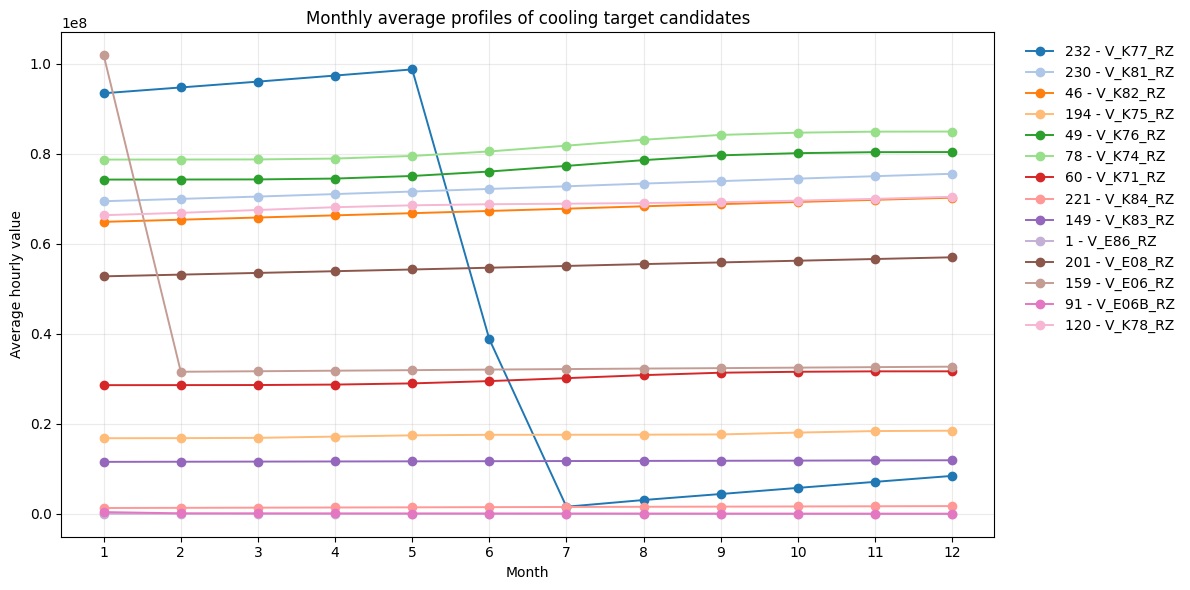

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

hourly_long = pd.read_csv(csv_dir / "hourly_long_2025_exploration.csv")
hourly_long["ts_hour"] = pd.to_datetime(hourly_long["ts_hour"], errors="coerce")
hourly_long["datapoint_id"] = hourly_long["datapoint_id"].astype(int)
hourly_long["month"] = hourly_long["ts_hour"].dt.month

month_profile = (
    hourly_long[hourly_long["datapoint_id"].isin(target_ids)]
    .groupby(["datapoint_id", "month"])["value_hour"]
    .mean()
    .reset_index()
)

name_map = signal_inventory.set_index("datapoint_id")["dp_id"].to_dict()

# final retained target components
target_ids_final = [120, 230, 46, 49, 78]

# use a large categorical palette so every line has its own color
cmap = plt.get_cmap("tab20")
color_map = {cid: cmap(i % 20) for i, cid in enumerate(target_ids)}

plt.figure(figsize=(12, 6))

for cid in target_ids:
    tmp = month_profile[month_profile["datapoint_id"] == cid].sort_values("month")
    is_final = cid in target_ids_final

    plt.plot(
        tmp["month"],
        tmp["value_hour"],
        marker="o",
        linewidth=1.4,
        alpha=1.0,
        color=color_map[cid],
        label=f"{cid} - {name_map.get(cid, str(cid))}"
    )

plt.title("Monthly average profiles of cooling target candidates")
plt.xlabel("Month")
plt.ylabel("Average hourly value")
plt.xticks(range(1, 13))
plt.grid(alpha=0.25)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

Based on the candidate review, the final target components were restricted to the stable core cooling-family cumulative energy signals `120`, `230`, `46`, `49`, and `78`. These signals showed the most consistent annual profiles, clear cooling-related semantics, and plausible interpretation as core distributed cooling-energy subsystems. Candidates with structural instability, more peripheral branch-like behavior, or stronger interpretation as linked infrastructure/proxy signals were excluded from the final target definition.

In [50]:
target_ids_final = [120, 230, 46, 49, 78]

### C2. Cooling Target Construction and Initial Validation

After selecting the final cumulative cooling-energy components, the hourly cooling target is constructed by differencing each cumulative series, clipping negative steps, and summing the resulting hourly component increments. The resulting target is then checked for plausibility, outliers, seasonal structure, and distributional behavior before being carried forward into dataset construction.

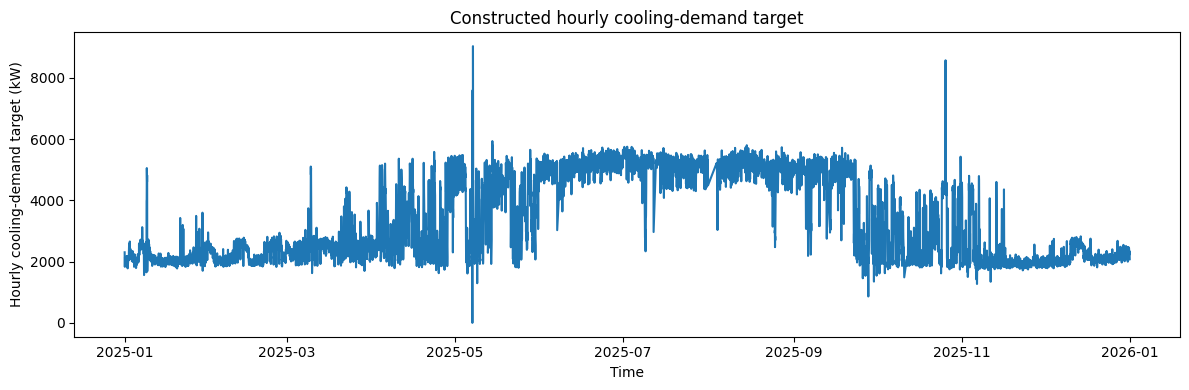

In [51]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

cooling_components = pivot[target_ids_final].copy()

cooling_components_diff = cooling_components.diff()
cooling_components_diff = cooling_components_diff.clip(lower=0)

cooling_target = cooling_components_diff.sum(axis=1, min_count=1)
cooling_target = cooling_target.dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cooling_target.index, cooling_target.values)

ax.set_title("Constructed hourly cooling-demand target")
ax.set_xlabel("Time")
ax.set_ylabel("Hourly cooling-demand target (kW)")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

The constructed hourly cooling target is reviewed for plausibility before it is used in dataset construction. The checks below summarize global extremes, local deviations, and abrupt jumps in order to identify whether the aggregated target contains clearly unstable or implausible behavior. The constructed hourly cooling target shows a clear seasonal structure, with lower levels in winter, higher and more variable demand during the warm season, and a return to lower levels toward year end. A small number of sharp spikes and dips remain visible, which motivates the following outlier review.

In [52]:
target_df = cooling_target.to_frame(name="y").copy()

q01 = target_df["y"].quantile(0.01)
q99 = target_df["y"].quantile(0.99)

target_df["is_global_outlier"] = (target_df["y"] < q01) | (target_df["y"] > q99)

target_df["is_global_outlier"].value_counts()

is_global_outlier
False    8433
True      172
Name: count, dtype: int64

In [53]:
roll_med = target_df["y"].rolling(window=24*7, center=True, min_periods=24).median()
roll_std = target_df["y"].rolling(window=24*7, center=True, min_periods=24).std()

target_df["roll_med"] = roll_med
target_df["roll_std"] = roll_std

target_df["z_local"] = (target_df["y"] - target_df["roll_med"]) / target_df["roll_std"]
target_df["is_local_outlier"] = target_df["z_local"].abs() > 4

target_df["is_local_outlier"].value_counts()

is_local_outlier
False    8571
True       34
Name: count, dtype: int64

In [54]:
target_df["dy"] = target_df["y"].diff()

dy_q01 = target_df["dy"].quantile(0.01)
dy_q99 = target_df["dy"].quantile(0.99)

target_df["is_jump_outlier"] = (target_df["dy"] < dy_q01) | (target_df["dy"] > dy_q99)

target_df["is_jump_outlier"].value_counts()

is_jump_outlier
False    8431
True      174
Name: count, dtype: int64

The target contains a limited number of extreme global values and a much smaller number of locally unusual points. This suggests that the series is broadly stable, but still includes a small set of exceptional observations worth treating cautiously in downstream modeling.

Local outlier detection is used here as a diagnostic tool rather than a hard exclusion rule. The goal is to identify whether unusual target behavior is isolated or structurally dominant in the series.

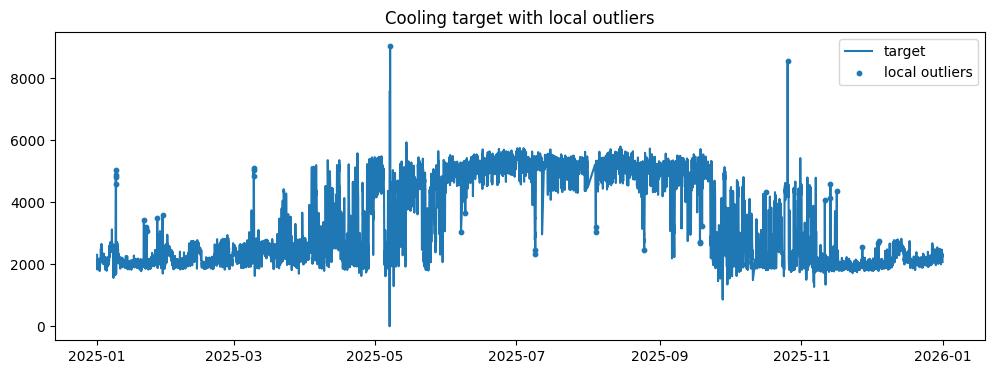

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(target_df.index, target_df["y"], label="target")
plt.scatter(
    target_df.index[target_df["is_local_outlier"]],
    target_df.loc[target_df["is_local_outlier"], "y"],
    s=10,
    label="local outliers"
)
plt.title("Cooling target with local outliers")
plt.legend()
plt.show()

Local outliers are sparse relative to the full series and do not dominate the annual structure. Most of the target remains concentrated within a stable seasonal regime, which supports keeping the series with only light cleaning rather than aggressive filtering.

Distributional and seasonal summaries are inspected to understand the target structure across the year. This helps verify that the target shows interpretable seasonal variation and to assess whether extreme values are limited enough for light clipping.

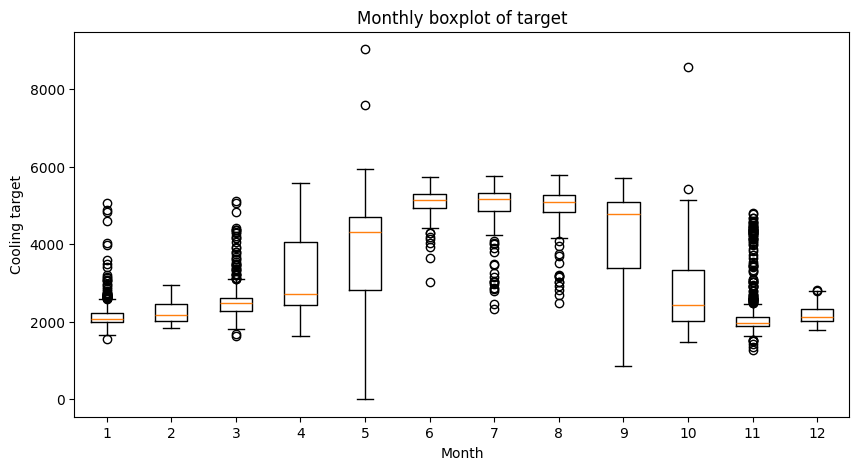

In [56]:
target_df["month"] = target_df.index.month
monthly_data = [target_df.loc[target_df["month"] == m, "y"].dropna().values for m in range(1, 13)]

plt.figure(figsize=(10, 5))
plt.boxplot(monthly_data, tick_labels=list(range(1, 13)))
plt.title("Monthly boxplot of target")
plt.xlabel("Month")
plt.ylabel("Cooling target")
plt.show()

The monthly boxplot confirms a strong seasonal pattern: cooling demand is lower in winter, rises through spring, remains elevated during summer, and decreases again in late autumn. Warm-season months also show wider dispersion, indicating both higher demand and greater operational variability.

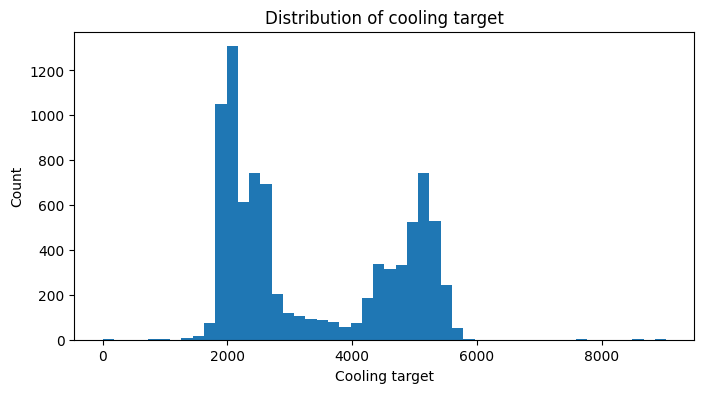

In [57]:
plt.figure(figsize=(8, 4))
plt.hist(target_df["y"].dropna(), bins=50)
plt.title("Distribution of cooling target")
plt.xlabel("Cooling target")
plt.ylabel("Count")
plt.show()

Because extreme values are limited but present, a light quantile-based clipping step is applied to reduce the influence of the most extreme observations while preserving the overall seasonal and distributional structure of the target.

In [60]:
cooling_components = pivot[target_ids_final].copy()

cooling_components_diff = cooling_components.diff().clip(lower=0)

cooling_target = (
    cooling_components_diff
    .sum(axis=1, min_count=1)
    .dropna()
)

# final clean
q_low = cooling_target.quantile(0.01)
q_high = cooling_target.quantile(0.99)

cooling_target_clean = cooling_target.clip(lower=q_low, upper=q_high)

### C3. Final Dataset Assembly

After fixing the final cooling target, the modeling datasets are assembled by combining the cleaned target with selected internal operational signals, time features, and an optional extended set of sibling cooling proxies. The goal is to create a clean main dataset and a broader comparison dataset for later forecasting experiments.

In [61]:
import pandas as pd

target_links = pd.read_csv(csv_dir_C / "target_candidate_links.csv")

# keep only rows where one side is a chosen target
target_links = target_links[
    target_links["id_a"].isin(target_ids_final) | target_links["id_b"].isin(target_ids_final)
].copy()

# put the chosen target always on the left side for easier reading
swap_mask = ~target_links["id_a"].isin(target_ids_final)

left_cols = ["id_a", "dp_id_a", "name_a", "description_a", "uom_a"]
right_cols = ["id_b", "dp_id_b", "name_b", "description_b", "uom_b"]

for l, r in zip(left_cols, right_cols):
    tmp = target_links.loc[swap_mask, l].copy()
    target_links.loc[swap_mask, l] = target_links.loc[swap_mask, r].values
    target_links.loc[swap_mask, r] = tmp.values

# rename for readability
target_links = target_links.rename(columns={
    "id_a": "target_id",
    "dp_id_a": "target_dp_id",
    "name_a": "target_name",
    "description_a": "target_description",
    "uom_a": "target_uom",
    "id_b": "linked_id",
    "dp_id_b": "linked_dp_id",
    "name_b": "linked_name",
    "description_b": "linked_description",
    "uom_b": "linked_uom",
})

# remove links from target to itself / other chosen target components
target_links = target_links[~target_links["linked_id"].isin(target_ids_final)].copy()

# sort by strength
target_links = target_links.sort_values(
    ["target_id", "abs_corr"],
    ascending=[True, False]
)

review_table = target_links[[
    "target_id", "target_dp_id", "target_name", "target_description", "target_uom",
    "linked_id", "linked_dp_id", "linked_name", "linked_description", "linked_uom",
    "corr", "abs_corr"
]].copy()

review_table.to_csv(csv_dir_C / "target_links_review_table.csv", index=False)

print(review_table.shape)
review_table.head(100)

(530, 12)


,target_id,target_dp_id,target_name,target_description,target_uom,linked_id,linked_dp_id,linked_name,linked_description,linked_uom,corr,abs_corr
1,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,201,V_E08_RZ,E08 Wirkenergie Trafo T9 U200,NaN,KWT,0.999994,0.999994
6,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,164,V_E03_RZ,E03 Wirkenergie Trafo T2 U200,NaN,KWT,0.999982,0.999982
7,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,1,V_E86_RZ,Wirkenergie COOL Ringleitung 1,E86 Wirkenergie COOL Ringleitung 1,KWT,0.999981,0.999981
17,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,221,V_K84_RZ,Wirkenergie COOL Leitung B3 U6,K84 Wirkenergie COOL Leitung B3 U6,KWT,0.999932,0.999932
19,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,26,V_E71_RZ,Wirkenergie COOL Kaltwasserpumpe 3,E71 Wirkenergie COOL Kaltwasserpumpe 3,KWT,0.999922,0.999922
...,...,...,...,...,...,...,...,...,...,...,...,...
1204,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,107,COOL_01_XU02_0214B_K01_K05_K02_Z01,Kältemaschine B Summe Leistung brutto kW,COOL Kältemaschine B Summe Leistung brutto kW,KWT,0.052074,0.052074
1216,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,44,COOL_01_XU02_0214A_K01_K04_K01_J21,KMA Verdichter 2 El.- Leistung,Kältemaschine A Verdichter 2 El.- Leistung,KWT,0.051221,0.051221
1237,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,210,COOL_01_XU02_0214B_K01_K05_K02_J23,Kältemaschine B Verdichter 4 El.- Leistung,COOL Kältemaschine B Verdichter 4 El.- Leistung,KWT,0.047063,0.047063
1244,46,V_K82_RZ,Wirkenergie COOL Ringleitung 2,K82 Wirkenergie COOL Ringleitung 2,KWT,134,COOL_01_XU02_0214A_K01_K05_K02_J22,Kältemaschine C Verdichter 3 El.- Leistung,COOL Kältemaschine C Verdichter 3 El.- Leistung,KWT,0.046845,0.046845


In [62]:
pivot_aligned = pivot.loc[cooling_target_clean.index]

features = pivot_aligned.drop(columns=target_ids_final)

target_corr = features.corrwith(cooling_target_clean)

target_corr = target_corr.sort_values(ascending=False)

target_corr.head(20)

datapoint_id
61     0.911940
34     0.876388
21     0.868848
80     0.853978
188    0.852733
197    0.843107
135    0.819619
93     0.759197
23     0.756862
116    0.755065
75     0.748329
85     0.733394
128    0.710457
99     0.681665
44     0.679935
15     0.675243
235    0.661111
110    0.656540
18     0.645203
103    0.603851
dtype: float64

In [63]:
feature_ids_core = [
    135, 154,                               # meteo
    66, 164, 129, 39, 159, 216, 201, 167,   # transformer energy
    98, 202, 121, 206, 147, 152,            # E04 currents
    32, 108, 208, 161, 35, 72,              # E06 currents
    4, 209, 8, 178, 171, 187,               # E07 currents
    42, 132, 140,                           # E08 currents
    90, 100, 14,                            # E09 currents
    115, 226, 192, 193                      # air handling / ventilation
]

feature_ids_sibling = [
    1, 143, 26, 179, 198, 54, 151, 123, 19, 215, 96, 69, 158, 175,
    106, 38, 194, 232, 213, 29, 60, 221, 149
]

The predictor design is split into two views. The main feature set contains internal operational signals and time-based context, while the extended comparison set additionally includes sibling cooling-related signals. This allows later comparison between a cleaner driver-based dataset and a broader target-adjacent dataset.

In [64]:
cooling_components = pivot[target_ids_final].copy()
cooling_components_diff = cooling_components.diff().clip(lower=0)

cooling_target = (
    cooling_components_diff
    .sum(axis=1, min_count=1)
    .dropna()
)

q_low = cooling_target.quantile(0.01)
q_high = cooling_target.quantile(0.99)

y = cooling_target.clip(lower=q_low, upper=q_high)

In [65]:
pivot_aligned = pivot.loc[y.index].copy()

In [66]:
X_core = pivot_aligned[feature_ids_core].copy()

X_core["hour"] = X_core.index.hour
X_core["dayofweek"] = X_core.index.dayofweek
X_core["month"] = X_core.index.month
X_core["is_weekend"] = (X_core.index.dayofweek >= 5).astype(int)

print(X_core.shape, y.shape)

(8605, 42) (8605,)


In [67]:
X_with_siblings = pivot_aligned[feature_ids_core + feature_ids_sibling].copy()

X_with_siblings["hour"] = X_with_siblings.index.hour
X_with_siblings["dayofweek"] = X_with_siblings.index.dayofweek
X_with_siblings["month"] = X_with_siblings.index.month
X_with_siblings["is_weekend"] = (X_with_siblings.index.dayofweek >= 5).astype(int)

print(X_with_siblings.shape, y.shape)

(8605, 65) (8605,)


In [68]:
print("X_core missing:")
print(X_core.isna().mean().sort_values(ascending=False).head(10))

print("X_with_siblings missing:")
print(X_with_siblings.isna().mean().sort_values(ascending=False).head(10))

print("y missing:", y.isna().mean())

X_core missing:
datapoint_id
135    0.767577
154    0.767461
121    0.000116
8      0.000116
98     0.000116
90     0.000000
178    0.000000
171    0.000000
187    0.000000
42     0.000000
dtype: float64
X_with_siblings missing:
datapoint_id
135    0.767577
154    0.767461
98     0.000116
121    0.000116
8      0.000116
215    0.000000
19     0.000000
123    0.000000
151    0.000000
54     0.000000
dtype: float64
y missing: 0.0


The initial missingness check shows that the constructed target has full coverage, while most selected predictors are nearly complete. The main exception is the internal meteo subset, where two signals show substantial missingness, motivating a later decision on whether to retain internal meteo or replace it with external weather data.

datapoint_id
135    0.767577
154    0.767461
dtype: float64


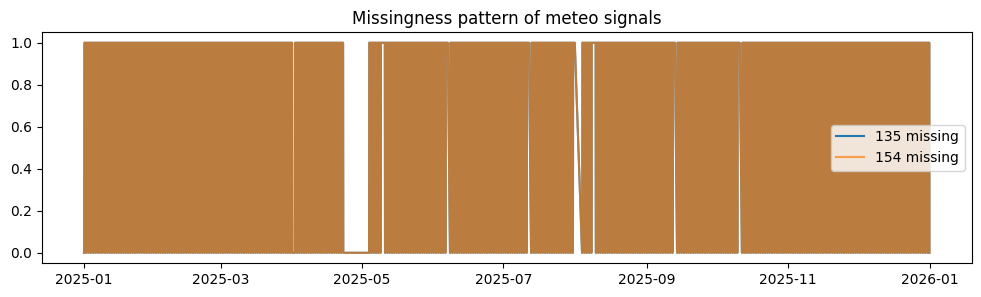

In [69]:
meteo_ids = [135, 154]   # Außentemperatur, Globalstrahlung

meteo_missing = pivot_aligned[meteo_ids].isna().mean().sort_values(ascending=False)
print(meteo_missing)

plt.figure(figsize=(12, 3))
plt.plot(pivot_aligned[135].isna().astype(int), label="135 missing")
plt.plot(pivot_aligned[154].isna().astype(int), label="154 missing", alpha=0.7)
plt.legend()
plt.title("Missingness pattern of meteo signals")
plt.show()

The internal meteo candidates show severe missingness and are therefore not suitable as reliable final predictors without replacement.

Because weather context is still relevant for cooling-demand modeling, external hourly weather data are retrieved and prepared as a replacement environmental source.

In [ ]:
import requests
import pandas as pd

# ---------------------------------------------------------
# SELECTED EXTENDED BLOCK
# ---------------------------------------------------------
START_DATE = "2025-01-01"
END_DATE   = "2026-01-01"

url = "https://archive-api.open-meteo.com/v1/archive"

hourly_vars = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "shortwave_radiation",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "precipitation",
]

params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "timezone": TIMEZONE,
    "hourly": hourly_vars,
}

response = requests.get(url, params=params, timeout=60)
response.raise_for_status()
data = response.json()

if "hourly" not in data:
    raise ValueError("No hourly weather data returned by Open-Meteo.")

weather_hourly = pd.DataFrame(data["hourly"])

if weather_hourly.empty:
    raise ValueError("Weather dataframe is empty.")

weather_hourly["time"] = pd.to_datetime(weather_hourly["time"], errors="coerce")
weather_hourly = weather_hourly.sort_values("time").reset_index(drop=True)

weather_hourly.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,shortwave_radiation,surface_pressure,cloud_cover,wind_speed_10m,precipitation
0,2025-01-01 00:00:00,-1.5,98,-1.8,0.0,975.2,11,1.5,0.0
1,2025-01-01 01:00:00,-1.5,98,-1.7,0.0,975.1,7,1.0,0.0
2,2025-01-01 02:00:00,-1.9,99,-2.1,0.0,974.5,4,2.6,0.0
3,2025-01-01 03:00:00,-3.2,100,-3.2,0.0,975.5,99,2.4,0.0
4,2025-01-01 04:00:00,-3.0,100,-3.0,0.0,975.7,100,4.7,0.0


In [72]:
weather_hourly["time"] = pd.to_datetime(weather_hourly["time"], errors="coerce")
weather_hourly = weather_hourly.sort_values("time").reset_index(drop=True)

weather_hourly = weather_hourly.rename(columns={
    "time": "ts_hour",
    "temperature_2m": "wx_temp_2m",
    "relative_humidity_2m": "wx_rh_2m",
    "dew_point_2m": "wx_dewpoint_2m",
    "shortwave_radiation": "wx_shortwave_rad",
    "surface_pressure": "wx_surface_pressure",
    "cloud_cover": "wx_cloud_cover",
    "wind_speed_10m": "wx_wind_speed_10m",
    "precipitation": "wx_precip",
})

In [73]:
weather_hourly = weather_hourly.set_index("ts_hour")

weather_cols = [
    "wx_temp_2m",
    "wx_rh_2m",
    "wx_dewpoint_2m",
    "wx_shortwave_rad",
    "wx_surface_pressure",
    "wx_cloud_cover",
    "wx_wind_speed_10m",
    "wx_precip",
]

weather_hourly = weather_hourly[weather_cols].copy()

weather_aligned = weather_hourly.reindex(y.index)

print(weather_aligned.shape)
print(weather_aligned.isna().mean().sort_values(ascending=False))

(8605, 8)
wx_temp_2m             1.0
wx_rh_2m               1.0
wx_dewpoint_2m         1.0
wx_shortwave_rad       1.0
wx_surface_pressure    1.0
wx_cloud_cover         1.0
wx_wind_speed_10m      1.0
wx_precip              1.0
dtype: float64


compare_df shape: (2007, 4)


,internal_temp,internal_rad,external_temp,external_rad
ts_hour,,,,
2025-01-01 00:00:00,-2.8,0.0,-1.5,0.0
2025-01-01 01:00:00,-2.8,0.0,-1.5,0.0
2025-01-01 02:00:00,-3.0,0.0,-1.9,0.0
2025-01-01 03:00:00,-2.6,0.0,-3.2,0.0
2025-01-01 23:00:00,6.1,0.0,-0.6,0.0


,pair,n_hours,corr,mae,mean_internal,mean_external,std_internal,std_external
0,internal_temp vs external_temp,2006,0.958923,1.483250,9.187637,9.208774,6.715088,7.205952
1,internal_rad vs external_rad,2007,0.621985,32.037369,33.667663,33.219731,138.819376,132.820429


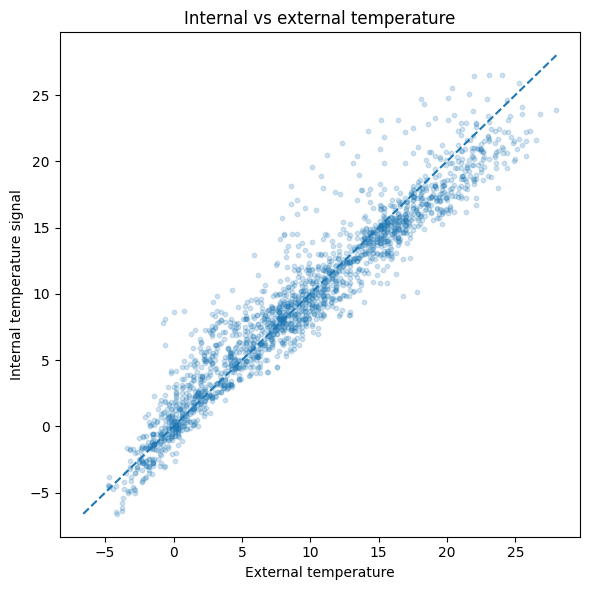

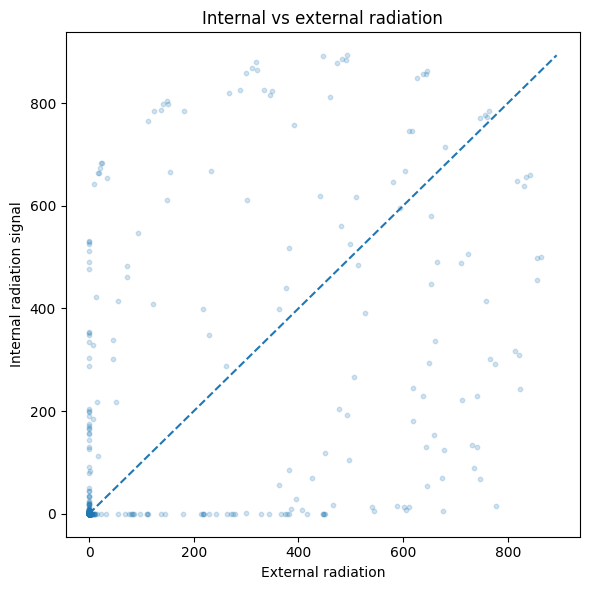

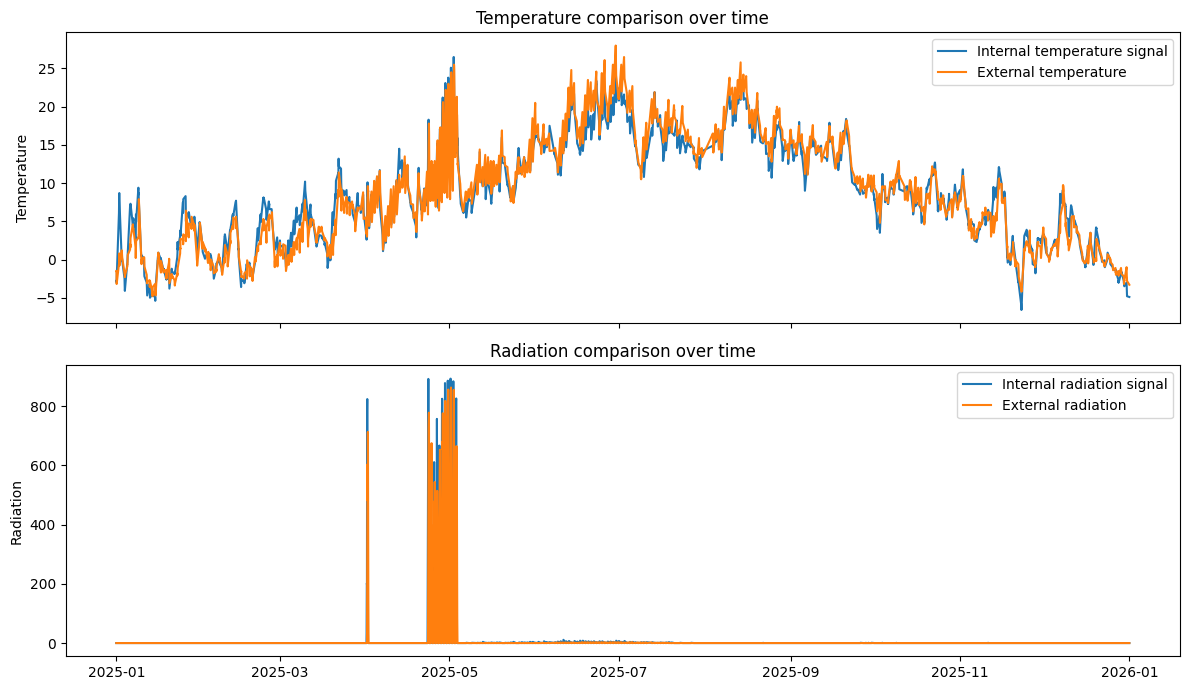

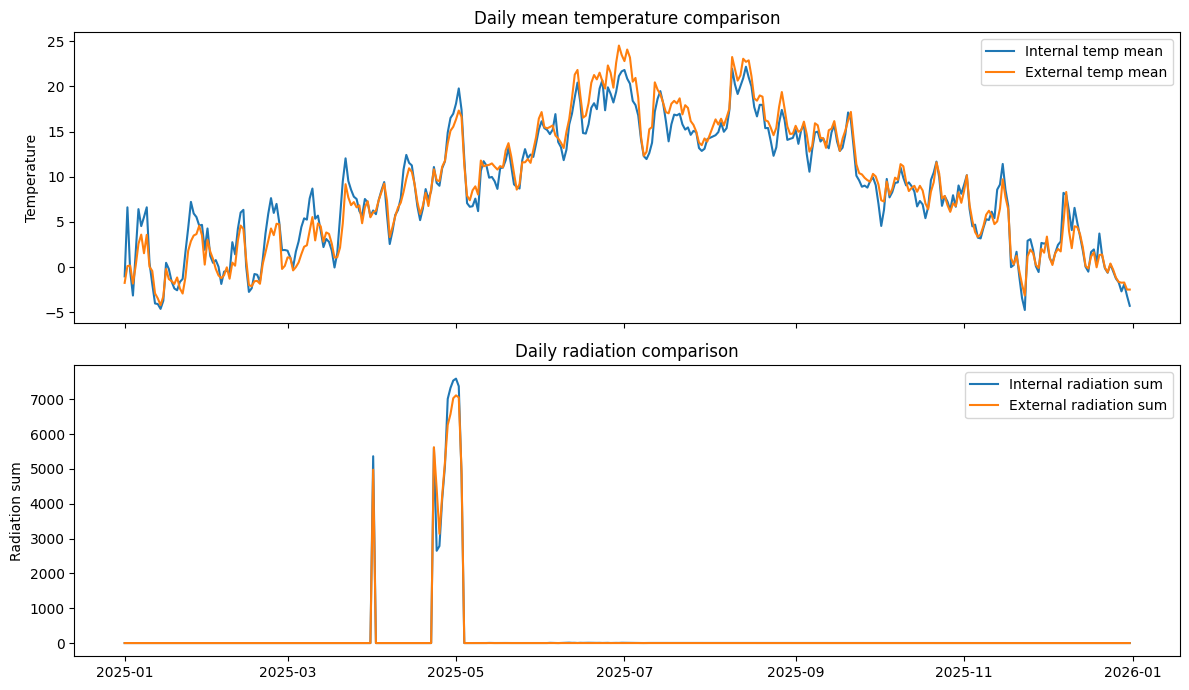

In [74]:
# =========================================================
# INTERNAL VS EXTERNAL WEATHER COMPARISON
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. SET INTERNAL SIGNAL IDS
# ---------------------------------------------------------
# replace these with your actual internal signal ids
internal_temp_id = 135      # example: internal/outdoor-like temperature signal
internal_rad_id  = 154      # example: internal/global-radiation-like signal

# ---------------------------------------------------------
# 2. LOAD HOURLY LONG DATA
# ---------------------------------------------------------
hourly_long = pd.read_csv(csv_dir / "hourly_long_2025_exploration.csv")
hourly_long["ts_hour"] = pd.to_datetime(hourly_long["ts_hour"], errors="coerce")
hourly_long["datapoint_id"] = hourly_long["datapoint_id"].astype(str)

# if timestamps are timezone-aware, make them naive
if hasattr(hourly_long["ts_hour"].dt, "tz") and hourly_long["ts_hour"].dt.tz is not None:
    hourly_long["ts_hour"] = hourly_long["ts_hour"].dt.tz_convert(None)

hourly_long["ts_hour"] = hourly_long["ts_hour"].dt.floor("h")

# ---------------------------------------------------------
# 3. EXTRACT INTERNAL SIGNALS
# ---------------------------------------------------------
internal_ids = [str(internal_temp_id), str(internal_rad_id)]

internal_long = hourly_long[
    hourly_long["datapoint_id"].isin(internal_ids)
].copy()

internal_wide = (
    internal_long
    .pivot_table(
        index="ts_hour",
        columns="datapoint_id",
        values="value_hour",
        aggfunc="mean"
    )
    .sort_index()
)

internal_wide.columns = [f"internal_{c}" for c in internal_wide.columns]

# ---------------------------------------------------------
# 4. CLEAN WEATHER DATAFRAME
# ---------------------------------------------------------
weather_cmp = weather_hourly.copy()

# if ts_hour is index, keep it; if it's a column, set it
if "ts_hour" in weather_cmp.columns:
    weather_cmp["ts_hour"] = pd.to_datetime(weather_cmp["ts_hour"], errors="coerce")
    if hasattr(weather_cmp["ts_hour"].dt, "tz") and weather_cmp["ts_hour"].dt.tz is not None:
        weather_cmp["ts_hour"] = weather_cmp["ts_hour"].dt.tz_convert(None)
    weather_cmp["ts_hour"] = weather_cmp["ts_hour"].dt.floor("H")
    weather_cmp = weather_cmp.set_index("ts_hour").sort_index()
else:
    weather_cmp.index = pd.to_datetime(weather_cmp.index, errors="coerce")
    if getattr(weather_cmp.index, "tz", None) is not None:
        weather_cmp.index = weather_cmp.index.tz_convert(None)
    weather_cmp.index = weather_cmp.index.floor("h")
    weather_cmp = weather_cmp.sort_index()

# ---------------------------------------------------------
# 5. JOIN INTERNAL + EXTERNAL
# ---------------------------------------------------------
compare_df = internal_wide.join(
    weather_cmp[["wx_temp_2m", "wx_shortwave_rad"]],
    how="inner"
).copy()

compare_df = compare_df.rename(columns={
    f"internal_{internal_temp_id}": "internal_temp",
    f"internal_{internal_rad_id}": "internal_rad",
    "wx_temp_2m": "external_temp",
    "wx_shortwave_rad": "external_rad"
})

print("compare_df shape:", compare_df.shape)
display(compare_df.head())

# ---------------------------------------------------------
# 6. SUMMARY STATISTICS
# ---------------------------------------------------------
summary_rows = []

pairs = [
    ("internal_temp", "external_temp"),
    ("internal_rad", "external_rad")
]

for internal_col, external_col in pairs:
    tmp = compare_df[[internal_col, external_col]].dropna().copy()

    summary_rows.append({
        "pair": f"{internal_col} vs {external_col}",
        "n_hours": len(tmp),
        "corr": tmp[internal_col].corr(tmp[external_col]),
        "mae": np.mean(np.abs(tmp[internal_col] - tmp[external_col])),
        "mean_internal": tmp[internal_col].mean(),
        "mean_external": tmp[external_col].mean(),
        "std_internal": tmp[internal_col].std(),
        "std_external": tmp[external_col].std(),
    })

comparison_summary = pd.DataFrame(summary_rows)
display(comparison_summary)

# ---------------------------------------------------------
# 7. SCATTER PLOTS
# ---------------------------------------------------------
# temperature
tmp = compare_df[["internal_temp", "external_temp"]].dropna().copy()

plt.figure(figsize=(6, 6))
plt.scatter(tmp["external_temp"], tmp["internal_temp"], alpha=0.2, s=10)
lims = [
    min(tmp["external_temp"].min(), tmp["internal_temp"].min()),
    max(tmp["external_temp"].max(), tmp["internal_temp"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("External temperature")
plt.ylabel("Internal temperature signal")
plt.title("Internal vs external temperature")
plt.tight_layout()
plt.show()

# radiation
tmp = compare_df[["internal_rad", "external_rad"]].dropna().copy()

plt.figure(figsize=(6, 6))
plt.scatter(tmp["external_rad"], tmp["internal_rad"], alpha=0.2, s=10)
lims = [
    min(tmp["external_rad"].min(), tmp["internal_rad"].min()),
    max(tmp["external_rad"].max(), tmp["internal_rad"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("External radiation")
plt.ylabel("Internal radiation signal")
plt.title("Internal vs external radiation")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. TIME-SERIES VISUALIZATION (SHORT WINDOW)
# ---------------------------------------------------------
# choose a short summer window for readability
plot_start = "2025-01-01"
plot_end   = "2025-12-31"

plot_df = compare_df.loc[plot_start:plot_end].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(plot_df.index, plot_df["internal_temp"], label="Internal temperature signal")
axes[0].plot(plot_df.index, plot_df["external_temp"], label="External temperature")
axes[0].set_ylabel("Temperature")
axes[0].set_title("Temperature comparison over time")
axes[0].legend()

axes[1].plot(plot_df.index, plot_df["internal_rad"], label="Internal radiation signal")
axes[1].plot(plot_df.index, plot_df["external_rad"], label="External radiation")
axes[1].set_ylabel("Radiation")
axes[1].set_title("Radiation comparison over time")
axes[1].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. OPTIONAL: DAILY AGGREGATED VISUALIZATION
# ---------------------------------------------------------
daily_df = compare_df.copy()
daily_df["date"] = daily_df.index.date

daily_agg = (
    daily_df
    .groupby("date")
    .agg(
        internal_temp_mean=("internal_temp", "mean"),
        external_temp_mean=("external_temp", "mean"),
        internal_rad_sum=("internal_rad", "sum"),
        external_rad_sum=("external_rad", "sum"),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(daily_agg.index, daily_agg["internal_temp_mean"], label="Internal temp mean")
axes[0].plot(daily_agg.index, daily_agg["external_temp_mean"], label="External temp mean")
axes[0].set_ylabel("Temperature")
axes[0].set_title("Daily mean temperature comparison")
axes[0].legend()

axes[1].plot(daily_agg.index, daily_agg["internal_rad_sum"], label="Internal radiation sum")
axes[1].plot(daily_agg.index, daily_agg["external_rad_sum"], label="External radiation sum")
axes[1].set_ylabel("Radiation sum")
axes[1].set_title("Daily radiation comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

A sparse internal temperature signal was initially reconsidered as a potential internal-state proxy. However, after re-evaluation against external weather variables, its temporal behaviour was found to closely track the external temperature context rather than provide clearly distinct internal-state information. For this reason, it was not retained in the final main forecasting specification and was treated, at most, as a sensitivity variable rather than a core predictor.

The sparse internal temperature signal was converted into an hourly internal thermal-state proxy through time interpolation and gap filling. The resulting series preserves the observed low-frequency structure of the original measurements and is therefore suitable as a slow-varying contextual feature in the final dataset. It is not interpreted as a conventional hourly ambient-temperature measurement.

In [75]:
feature_ids_core_no_meteo = [
    66, 164, 129, 39, 159, 216, 201, 167,
    98, 202, 121, 206, 147, 152,
    32, 108, 208, 161, 35, 72,
    4, 209, 8, 178, 171, 187,
    42, 132, 140,
    90, 100, 14,
    115, 226, 192, 193
]

X_internal = pivot_aligned[feature_ids_core_no_meteo].copy()

X_internal["hour"] = X_internal.index.hour
X_internal["dayofweek"] = X_internal.index.dayofweek
X_internal["month"] = X_internal.index.month
X_internal["is_weekend"] = (X_internal.index.dayofweek >= 5).astype(int)

print(X_internal.shape)
display(X_internal.head())

(8605, 40)


datapoint_id,66,164,129,39,159,216,201,167,98,202,...,100,14,115,226,192,193,hour,dayofweek,month,is_weekend
ts_hour,,,,,,,,,,,,,,,,,,,,,
2025-01-01 01:00:00+00:00,4.021181e+06,21568572.5,27093676.5,16556654.25,313808928.0,25641269.0,52562092.0,15875817.75,168.186871,168.294828,...,121.067425,157.893623,171952.09375,244028.031250,10.690579,16.983192,1,2,1,0
2025-01-01 02:00:00+00:00,4.021184e+06,21568780.0,27093802.0,16556656.50,313810512.0,25641415.0,52562595.0,15875916.50,174.898354,176.345325,...,123.119122,151.251690,171952.09375,244034.531250,10.690579,16.983192,2,2,1,0
2025-01-01 03:00:00+00:00,4.021186e+06,21568986.0,27093928.0,16556658.25,313812112.0,25641563.5,52563092.0,15876015.25,176.098072,176.902523,...,127.465935,155.337696,171952.09375,244040.757812,10.690579,16.983192,3,2,1,0
2025-01-01 04:00:00+00:00,4.021189e+06,21569192.0,27094054.5,16556660.75,313813704.0,25641713.0,52563593.0,15876114.25,177.419502,177.339521,...,123.797224,151.425564,171952.09375,244047.207031,10.690579,16.983192,4,2,1,0
2025-01-01 05:00:00+00:00,4.021191e+06,21569399.0,27094180.5,16556663.50,313815288.0,25641863.0,52564092.0,15876217.75,176.897884,177.469379,...,136.020466,165.074554,171952.09375,244053.398438,10.690579,16.983192,5,2,1,0


In [76]:
# copy to avoid mutating originals
X_core_weather = X_internal.copy()
weather = weather_aligned.copy()

# make both indexes timezone-naive
X_core_weather.index = pd.to_datetime(X_core_weather.index).tz_localize(None)
weather.index = pd.to_datetime(weather.index).tz_localize(None)

# join
X_core_weather = X_core_weather.join(weather, how="left")

print(X_core_weather.shape)
print(X_core_weather.isna().mean().sort_values(ascending=False).head(20))

(8605, 48)
wx_precip              1.000000
wx_wind_speed_10m      1.000000
wx_cloud_cover         1.000000
wx_surface_pressure    1.000000
wx_shortwave_rad       1.000000
wx_dewpoint_2m         1.000000
wx_rh_2m               1.000000
wx_temp_2m             1.000000
121                    0.000116
8                      0.000116
98                     0.000116
140                    0.000000
226                    0.000000
90                     0.000000
100                    0.000000
14                     0.000000
115                    0.000000
month                  0.000000
192                    0.000000
193                    0.000000
dtype: float64


In [77]:
X_base = X_internal.copy()
X_siblings = pivot_aligned[feature_ids_sibling].copy()
weather = weather_aligned.copy()

# normalize all indexes to tz-naive
X_base.index = pd.to_datetime(X_base.index).tz_localize(None)
X_siblings.index = pd.to_datetime(X_siblings.index).tz_localize(None)
weather.index = pd.to_datetime(weather.index).tz_localize(None)

X_with_siblings_weather = (
    X_base
    .join(X_siblings, how="left")
    .join(weather, how="left")
)

print(X_with_siblings_weather.shape)
print(X_with_siblings_weather.isna().mean().sort_values(ascending=False).head(20))

(8605, 71)
wx_precip              1.000000
wx_temp_2m             1.000000
wx_wind_speed_10m      1.000000
wx_cloud_cover         1.000000
wx_surface_pressure    1.000000
wx_shortwave_rad       1.000000
wx_dewpoint_2m         1.000000
wx_rh_2m               1.000000
121                    0.000116
8                      0.000116
98                     0.000116
96                     0.000000
1                      0.000000
143                    0.000000
26                     0.000000
179                    0.000000
198                    0.000000
54                     0.000000
151                    0.000000
123                    0.000000
dtype: float64


In [78]:
import pandas as pd

def make_naive_hourly_index(idx):
    idx = pd.to_datetime(idx, errors="coerce")
    if getattr(idx, "tz", None) is not None:
        idx = idx.tz_convert(None)
    return idx.floor("h")

weather_hourly = weather_hourly.copy()
weather_hourly.index = make_naive_hourly_index(weather_hourly.index)

y = y.copy()
y.index = make_naive_hourly_index(y.index)

pivot_aligned = pivot_aligned.copy()
pivot_aligned.index = make_naive_hourly_index(pivot_aligned.index)

weather_aligned = weather_hourly.reindex(y.index)

for col in weather_cols:
    weather_aligned[col] = pd.to_numeric(weather_aligned[col], errors="coerce")

print("weather missing:")
print(weather_aligned.isna().mean())

print("common timestamps:", y.index.intersection(weather_hourly.index).shape[0])

weather_corr = weather_aligned.corrwith(y).sort_values(ascending=False)
print(weather_corr)

weather missing:
wx_temp_2m             0.0
wx_rh_2m               0.0
wx_dewpoint_2m         0.0
wx_shortwave_rad       0.0
wx_surface_pressure    0.0
wx_cloud_cover         0.0
wx_wind_speed_10m      0.0
wx_precip              0.0
dtype: float64
common timestamps: 8605
wx_temp_2m             0.850621
wx_dewpoint_2m         0.813065
wx_shortwave_rad       0.409649
wx_precip              0.056919
wx_surface_pressure    0.023430
wx_wind_speed_10m      0.015477
wx_cloud_cover        -0.259225
wx_rh_2m              -0.412936
dtype: float64


In [79]:
print(X_core_weather.isna().mean().sort_values(ascending=False).head(20))
print(X_with_siblings_weather.isna().mean().sort_values(ascending=False).head(20))

wx_precip              1.000000
wx_wind_speed_10m      1.000000
wx_cloud_cover         1.000000
wx_surface_pressure    1.000000
wx_shortwave_rad       1.000000
wx_dewpoint_2m         1.000000
wx_rh_2m               1.000000
wx_temp_2m             1.000000
121                    0.000116
8                      0.000116
98                     0.000116
140                    0.000000
226                    0.000000
90                     0.000000
100                    0.000000
14                     0.000000
115                    0.000000
month                  0.000000
192                    0.000000
193                    0.000000
dtype: float64
wx_precip              1.000000
wx_temp_2m             1.000000
wx_wind_speed_10m      1.000000
wx_cloud_cover         1.000000
wx_surface_pressure    1.000000
wx_shortwave_rad       1.000000
wx_dewpoint_2m         1.000000
wx_rh_2m               1.000000
121                    0.000116
8                      0.000116
98                     0.

The first join between the external weather data and the modeling index produced full missingness, indicating an index-alignment problem rather than absence of weather data. The alignment is therefore corrected before the final datasets are assembled.

In [80]:
import pandas as pd

def to_naive_utc_hourly_index(idx):
    idx = pd.to_datetime(idx, errors="coerce")
    if getattr(idx, "tz", None) is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    return idx.floor("h")

# target
y = y.copy()
y.index = to_naive_utc_hourly_index(y.index)

# internal predictors
X_internal = X_internal.copy()
X_internal.index = to_naive_utc_hourly_index(X_internal.index)

# siblings
X_siblings = X_siblings.copy()
X_siblings.index = to_naive_utc_hourly_index(X_siblings.index)

# weather
weather_aligned = weather_aligned.copy()
weather_aligned.index = to_naive_utc_hourly_index(weather_aligned.index)

print("y tz:", y.index.tz)
print("X_internal tz:", X_internal.index.tz)
print("X_siblings tz:", X_siblings.index.tz)
print("weather_aligned tz:", weather_aligned.index.tz)

y tz: None
X_internal tz: None
X_siblings tz: None
weather_aligned tz: None


In [81]:
weather_keep = [
    "wx_temp_2m",
    "wx_dewpoint_2m",
    "wx_shortwave_rad",
    "wx_rh_2m",
    "wx_cloud_cover"
]

X_main = X_internal.join(weather_aligned[weather_keep], how="left")
X_compare = X_internal.join(X_siblings, how="left").join(weather_aligned[weather_keep], how="left")

print(X_main.shape)
print(X_compare.shape)

(8605, 45)
(8605, 68)


In [82]:
for col in weather_keep:
    X_main[col] = X_main[col].interpolate(method="time").ffill().bfill()
    X_compare[col] = X_compare[col].interpolate(method="time").ffill().bfill()

print(X_main[weather_keep].isna().mean())
print(X_compare[weather_keep].isna().mean())

wx_temp_2m          0.0
wx_dewpoint_2m      0.0
wx_shortwave_rad    0.0
wx_rh_2m            0.0
wx_cloud_cover      0.0
dtype: float64
wx_temp_2m          0.0
wx_dewpoint_2m      0.0
wx_shortwave_rad    0.0
wx_rh_2m            0.0
wx_cloud_cover      0.0
dtype: float64


In [83]:
print(type(X_internal.index), X_internal.index.dtype)
print(type(weather_aligned.index), weather_aligned.index.dtype)
print(X_internal.index[:3])
print(weather_aligned.index[:3])

<class 'pandas.DatetimeIndex'> datetime64[us]
<class 'pandas.DatetimeIndex'> datetime64[us]
DatetimeIndex(['2025-01-01 01:00:00', '2025-01-01 02:00:00',
               '2025-01-01 03:00:00'],
              dtype='datetime64[us]', name='ts_hour', freq=None)
DatetimeIndex(['2025-01-01 01:00:00', '2025-01-01 02:00:00',
               '2025-01-01 03:00:00'],
              dtype='datetime64[us]', name='ts_hour', freq=None)


In [84]:
X_main = X_internal.join(weather_aligned[weather_keep], how="left")

print(X_main.shape)
print(X_main[weather_keep].isna().mean())

(8605, 45)
wx_temp_2m          0.0
wx_dewpoint_2m      0.0
wx_shortwave_rad    0.0
wx_rh_2m            0.0
wx_cloud_cover      0.0
dtype: float64


In [85]:
X_compare = X_internal.join(X_siblings, how="left").join(weather_aligned[weather_keep], how="left")

print(X_compare.shape)
print(X_compare[weather_keep].isna().mean())

(8605, 68)
wx_temp_2m          0.0
wx_dewpoint_2m      0.0
wx_shortwave_rad    0.0
wx_rh_2m            0.0
wx_cloud_cover      0.0
dtype: float64


In [86]:
for col in weather_keep:
    X_main[col] = X_main[col].interpolate(method="time").ffill().bfill()
    X_compare[col] = X_compare[col].interpolate(method="time").ffill().bfill()

print(X_main[weather_keep].isna().mean())
print(X_compare[weather_keep].isna().mean())

wx_temp_2m          0.0
wx_dewpoint_2m      0.0
wx_shortwave_rad    0.0
wx_rh_2m            0.0
wx_cloud_cover      0.0
dtype: float64
wx_temp_2m          0.0
wx_dewpoint_2m      0.0
wx_shortwave_rad    0.0
wx_rh_2m            0.0
wx_cloud_cover      0.0
dtype: float64


In [87]:
dataset_main = X_main.copy()
dataset_main["y"] = y

dataset_compare = X_compare.copy()
dataset_compare["y"] = y

print(dataset_main.shape)
print(dataset_compare.shape)

(8605, 46)
(8605, 69)


In [88]:
dataset_main.to_csv(csv_dir_C / "model_dataset_main_2025.csv", index=True)
dataset_compare.to_csv(csv_dir_C / "model_dataset_compare_2025.csv", index=True)

print("saved:")
print(csv_dir_C / "model_dataset_main.csv")
print(csv_dir_C / "model_dataset_compare.csv")

saved:
data/C_dataset_construction/csv/model_dataset_main.csv
data/C_dataset_construction/csv/model_dataset_compare.csv


In [89]:
print(dataset_main[weather_keep + ["y"]].corr()["y"].sort_values(ascending=False))
print(dataset_main.isna().mean().sort_values(ascending=False).head(20))

y                   1.000000
wx_temp_2m          0.850621
wx_dewpoint_2m      0.813065
wx_shortwave_rad    0.409649
wx_cloud_cover     -0.259225
wx_rh_2m           -0.412936
Name: y, dtype: float64
8                 0.000116
98                0.000116
121               0.000116
66                0.000000
193               0.000000
132               0.000000
140               0.000000
90                0.000000
100               0.000000
14                0.000000
115               0.000000
226               0.000000
192               0.000000
hour              0.000000
187               0.000000
dayofweek         0.000000
month             0.000000
is_weekend        0.000000
wx_temp_2m        0.000000
wx_dewpoint_2m    0.000000
dtype: float64


## D. Data Quality and Exploratory Analysis

This section summarizes the final cooling target and the final modeling dataset before forecasting experiments. The goal is to document target behavior, dataset completeness, and the main visible relationships between cooling demand and key exogenous weather variables.

In [90]:
dataset_main = dataset_main.dropna().copy()
dataset_compare = dataset_compare.dropna().copy()

print("cleaned dataset_main:", dataset_main.shape)
print("cleaned dataset_compare:", dataset_compare.shape)

dataset_main.to_csv(csv_dir_C / "model_dataset_main.csv", index=True)
dataset_compare.to_csv(csv_dir_C / "model_dataset_compare.csv", index=True)

print("saved cleaned final datasets")

cleaned dataset_main: (8603, 46)
cleaned dataset_compare: (8603, 69)
saved cleaned final datasets


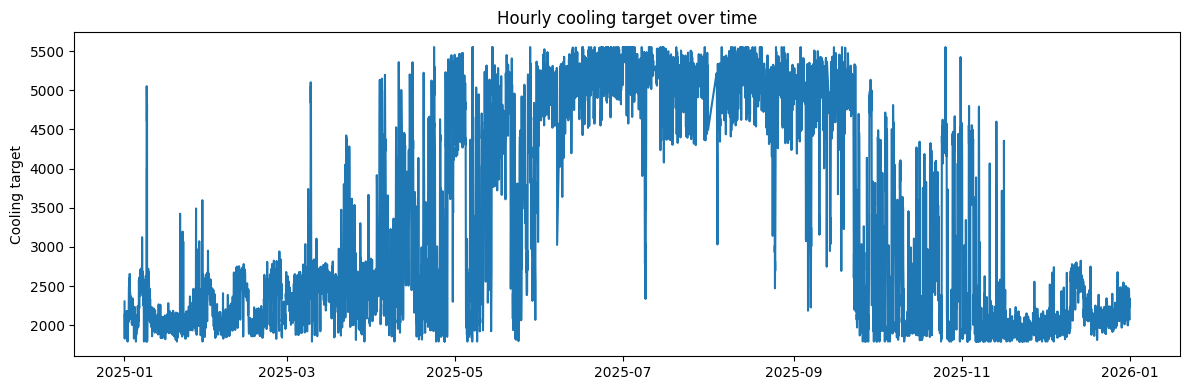

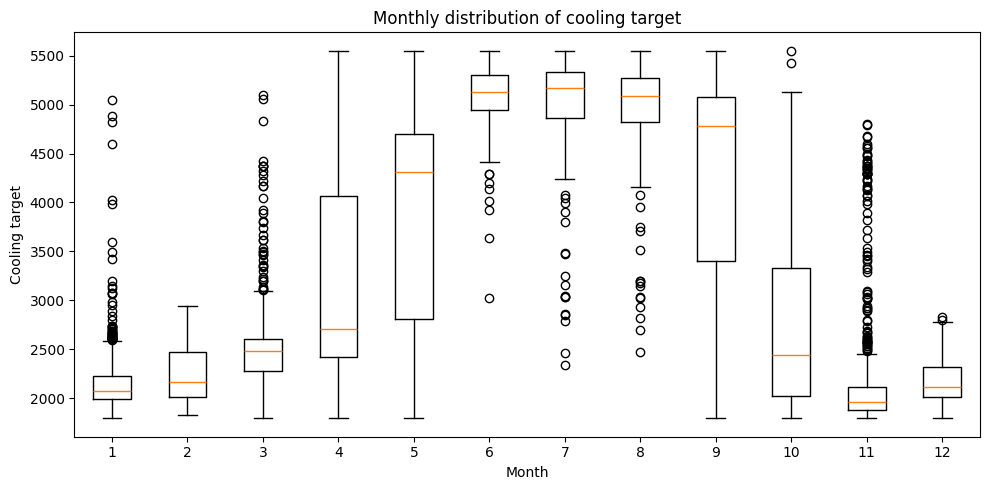

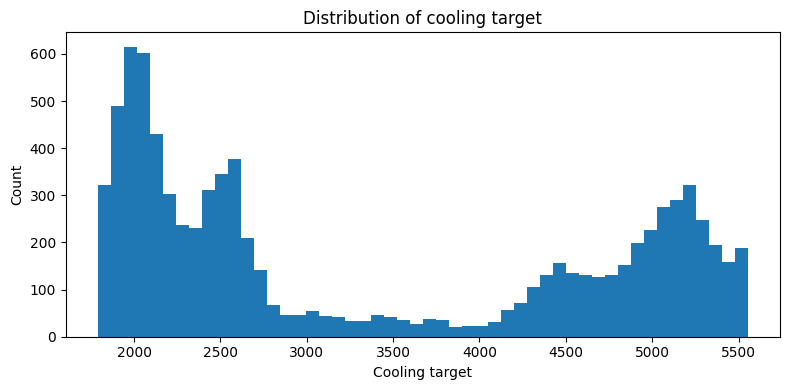

y                   1.000000
wx_temp_2m          0.850695
wx_dewpoint_2m      0.813200
wx_shortwave_rad    0.409636
wx_cloud_cover     -0.259317
wx_rh_2m           -0.412941
Name: y, dtype: float64


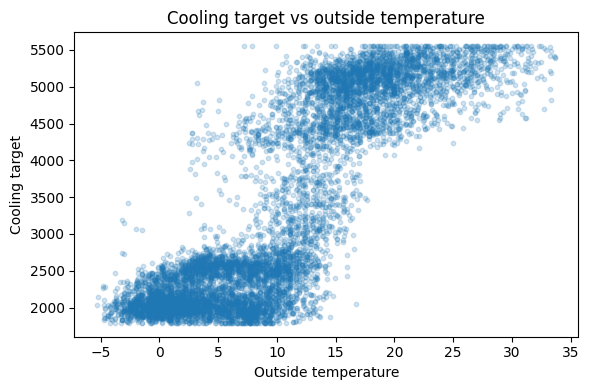

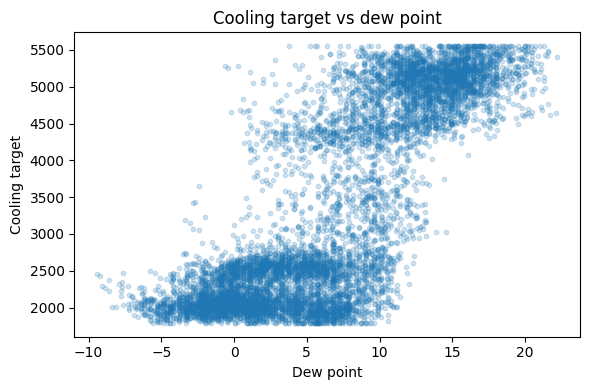

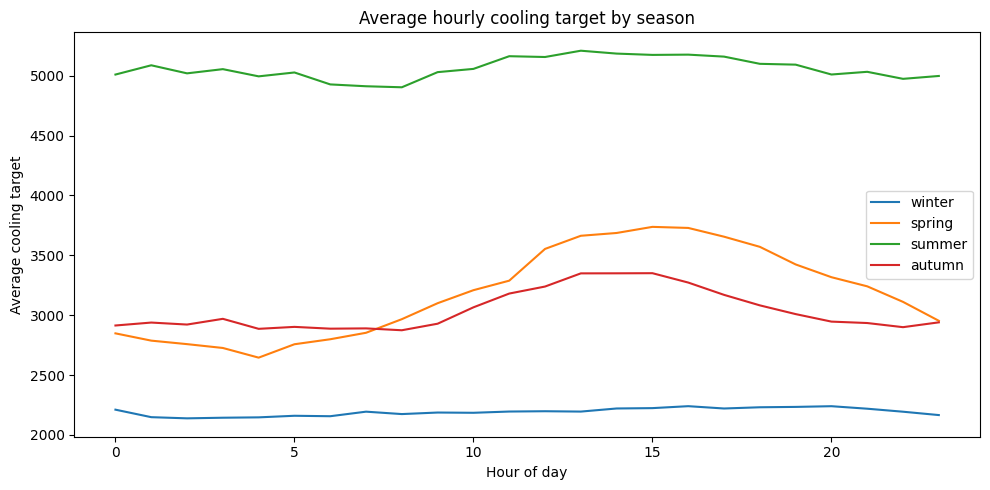

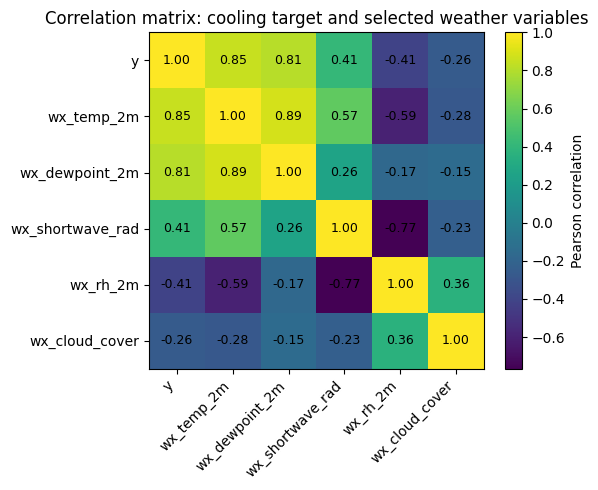

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# assumes dataset_main already exists and index is datetime
eda_df = dataset_main.copy()
eda_df.index = pd.to_datetime(eda_df.index, errors="coerce")
eda_df["month"] = eda_df.index.month
eda_df["hour"] = eda_df.index.hour

# 1. full-year target
plt.figure(figsize=(12, 4))
plt.plot(eda_df.index, eda_df["y"])
plt.title("Hourly cooling target over time")
plt.ylabel("Cooling target")
plt.tight_layout()
plt.show()

# 2. monthly boxplot
monthly_data = [eda_df.loc[eda_df["month"] == m, "y"].dropna().values for m in range(1, 13)]
plt.figure(figsize=(10, 5))
plt.boxplot(monthly_data, tick_labels=list(range(1, 13)))
plt.title("Monthly distribution of cooling target")
plt.xlabel("Month")
plt.ylabel("Cooling target")
plt.tight_layout()
plt.show()

# 3. histogram
plt.figure(figsize=(8, 4))
plt.hist(eda_df["y"].dropna(), bins=50)
plt.title("Distribution of cooling target")
plt.xlabel("Cooling target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 4. missingness
missing = eda_df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0].head(15)
if len(missing) > 0:
    plt.figure(figsize=(8, 4))
    plt.bar(missing.index.astype(str), missing.values)
    plt.title("Top missingness ratios in final dataset")
    plt.ylabel("Missing ratio")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 5. small weather correlation table
weather_keep = ["wx_temp_2m", "wx_dewpoint_2m", "wx_shortwave_rad", "wx_rh_2m", "wx_cloud_cover"]
corr_small = eda_df[["y"] + weather_keep].corr()
print(corr_small["y"].sort_values(ascending=False))

# 6. scatter y vs temp
plt.figure(figsize=(6, 4))
plt.scatter(eda_df["wx_temp_2m"], eda_df["y"], alpha=0.2, s=10)
plt.title("Cooling target vs outside temperature")
plt.xlabel("Outside temperature")
plt.ylabel("Cooling target")
plt.tight_layout()
plt.show()

# 7. scatter y vs dew point
plt.figure(figsize=(6, 4))
plt.scatter(eda_df["wx_dewpoint_2m"], eda_df["y"], alpha=0.2, s=10)
plt.title("Cooling target vs dew point")
plt.xlabel("Dew point")
plt.ylabel("Cooling target")
plt.tight_layout()
plt.show()

# 8. average hourly profile by season
eda_df["season"] = pd.cut(
    eda_df["month"],
    bins=[0, 2, 5, 8, 11, 12],
    labels=["winter", "spring", "summer", "autumn", "winter2"],
    include_lowest=True
).replace({"winter2": "winter"})

hourly_season = eda_df.groupby(["season", "hour"])["y"].mean().reset_index()

plt.figure(figsize=(10, 5))
for season in ["winter", "spring", "summer", "autumn"]:
    tmp = hourly_season[hourly_season["season"] == season]
    plt.plot(tmp["hour"], tmp["y"], label=season)
plt.title("Average hourly cooling target by season")
plt.xlabel("Hour of day")
plt.ylabel("Average cooling target")
plt.legend()
plt.tight_layout()
plt.show()

corr_cols = [
    "y",
    "wx_temp_2m",
    "wx_dewpoint_2m",
    "wx_shortwave_rad",
    "wx_rh_2m",
    "wx_cloud_cover"
]

corr_df = dataset_main[corr_cols].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation matrix: cooling target and selected weather variables")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

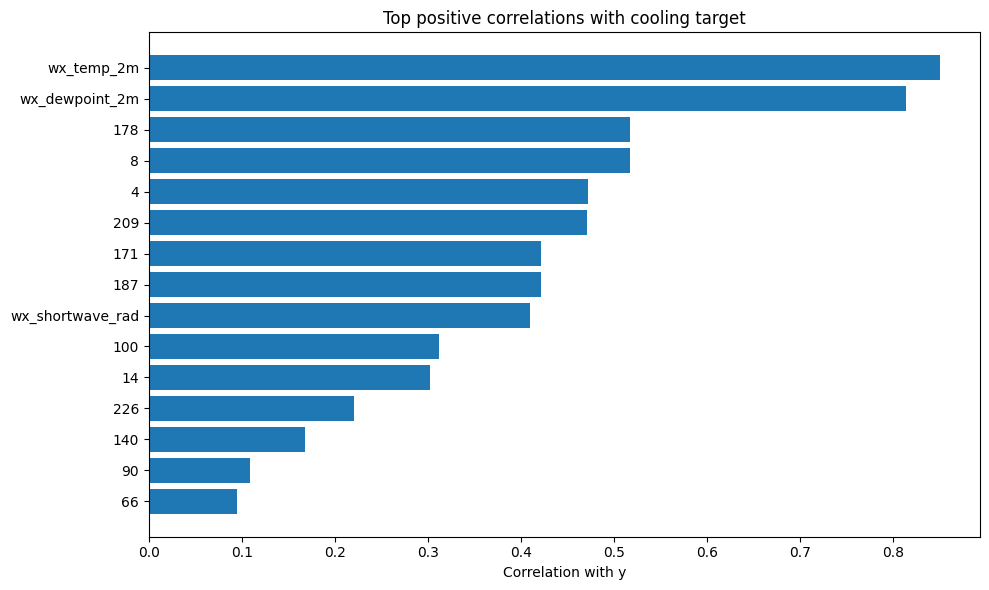

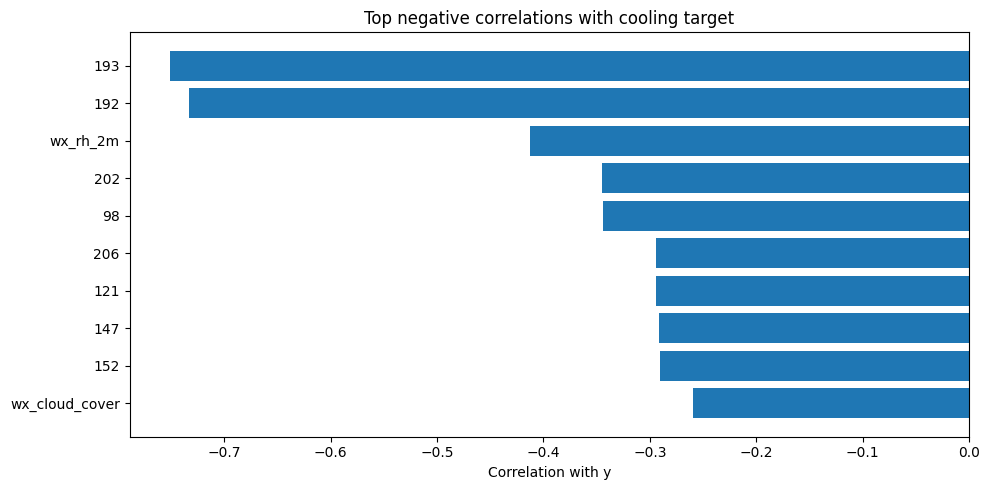

In [92]:
import matplotlib.pyplot as plt
import pandas as pd

# use final aligned main dataset without target columns in predictors
feature_corr = dataset_main.drop(columns=["y"]).corrwith(dataset_main["y"]).sort_values(ascending=False)

top_pos = feature_corr.head(15)
top_neg = feature_corr.tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top_pos.index[::-1].astype(str), top_pos.values[::-1])
plt.title("Top positive correlations with cooling target")
plt.xlabel("Correlation with y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.barh(top_neg.index.astype(str), top_neg.values)
plt.title("Top negative correlations with cooling target")
plt.xlabel("Correlation with y")
plt.tight_layout()
plt.show()

The strongest positive correlations are observed for outside temperature and dew point, followed by several internal operational signals. This indicates that cooling demand depends on both environmental conditions and internal load-related behavior. Negative correlations for humidity, cloud cover, and some internal signals suggest the presence of secondary counter-signals and regime-dependent relationships.

## E. Forecasting, Benchmarking, and Efficiency Analysis

This section evaluates forecasting performance on the final modeling datasets, establishes the strongest model under robust temporal validation, and then uses that model as an expected-demand benchmark for operational cooling analysis and conservative reduction-potential estimation.

### E1. Classical and machine-learning forecasting benchmarks

This subsection provides the first benchmark comparison on the final main dataset. The purpose is to evaluate the main forecasting model families promised in the study design, including naive baselines, classical time-series models, machine-learning models, and a neural sequence model, before moving to the final lagged setup and rolling-origin validation.

The comparison in this subsection is based on a single chronological split and is used as an initial benchmark layer rather than the final model-selection criterion.

In [77]:
!pip3 install tensorflow

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 200.4 MB 380 kB/s eta 0:00:01   |█▍                              | 8.5 MB 319 kB/s eta 0:10:01     |██▊                             | 17.0 MB 520 kB/s eta 0:05:53     |██████████                      | 63.3 MB 479 kB/s eta 0:04:46     |██████████▊                     | 67.1 MB 782 kB/s eta 0:02:51     |██████████████████████▋         | 141.8 MB 458 kB/s eta 0:02:08
     |████████████████████████████████| 12.0 MB 503 kB/s eta 0:00:01
     |████████████████████████████████| 1.4 MB 338 kB/s eta 0:00:01
     |████████████████████████████████| 2.8 MB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 135 kB 1.7 MB/s eta 0:00:01
     |████████████████████████████████| 61 kB 320 kB/s eta 0:00:01
     |████████████████████████████████| 71 kB 640 kB/s eta 0:00:01
     |████████████████████████████████| 57 kB 1.0 MB/s eta 0:00:01
     |████████████████████████████████| 

In [93]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# E1.1 LOAD FINAL MAIN DATASET
# =========================================================
dataset_main = pd.read_csv(csv_dir_C / "model_dataset_main.csv", index_col=0)
dataset_main.index = pd.to_datetime(dataset_main.index, errors="coerce")
dataset_main = dataset_main.sort_index().copy()

print("dataset_main shape:", dataset_main.shape)
print("date range:", dataset_main.index.min(), "to", dataset_main.index.max())

# ---------------------------------------------------------
# final weather columns expected in main dataset
# ---------------------------------------------------------
weather_keep = [c for c in [
    "wx_temp_2m",
    "wx_dewpoint_2m",
    "wx_shortwave_rad",
    "wx_rh_2m",
    "wx_cloud_cover"
] if c in dataset_main.columns]

# time columns if present
time_cols = [c for c in ["hour", "dayofweek", "month", "is_weekend"] if c in dataset_main.columns]

# all predictors except target
feature_cols = [c for c in dataset_main.columns if c != "y"]

# =========================================================
# E1.2 CHRONOLOGICAL TRAIN / TEST SPLIT
# =========================================================
split_idx = int(len(dataset_main) * 0.8)

train_df = dataset_main.iloc[:split_idx].copy()
test_df = dataset_main.iloc[split_idx:].copy()

y_train = train_df["y"].copy()
y_test = test_df["y"].copy()

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

print("train:", train_df.shape, "test:", test_df.shape)

# =========================================================
# E1.3 METRICS
# =========================================================
def calc_mae(y_true, y_pred):
    mask = pd.Series(y_true).notna().values & pd.Series(y_pred).notna().values
    return mean_absolute_error(np.array(y_true)[mask], np.array(y_pred)[mask])

def calc_rmse(y_true, y_pred):
    mask = pd.Series(y_true).notna().values & pd.Series(y_pred).notna().values
    return np.sqrt(mean_squared_error(np.array(y_true)[mask], np.array(y_pred)[mask]))

# =========================================================
# E1.4 BASELINES
# =========================================================
# naive persistence: previous observed hour
y_pred_naive = dataset_main["y"].shift(1).loc[test_df.index]

# seasonal naive: previous 24 hours
y_pred_snaive = dataset_main["y"].shift(24).loc[test_df.index]

# =========================================================
# E1.5 LINEAR REGRESSION
# =========================================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = pd.Series(lr.predict(X_test), index=X_test.index)

# =========================================================
# E1.6 RANDOM FOREST
# =========================================================
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = pd.Series(rf.predict(X_test), index=X_test.index)

# =========================================================
# E1.7 ARIMA / SARIMA
# =========================================================
# ARIMA and SARIMA use target history only in this benchmark layer

y_pred_arima = pd.Series(index=y_test.index, dtype=float)
y_pred_sarima = pd.Series(index=y_test.index, dtype=float)

try:
    arima_model = ARIMA(y_train, order=(1, 0, 1))
    arima_fit = arima_model.fit()
    y_pred_arima[:] = arima_fit.forecast(steps=len(y_test))
except Exception as e:
    print("ARIMA failed:", e)

try:
    sarima_model = SARIMAX(
        y_train,
        order=(1, 0, 1),
        seasonal_order=(1, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima_model.fit(disp=False)
    y_pred_sarima[:] = sarima_fit.forecast(steps=len(y_test))
except Exception as e:
    print("SARIMA failed:", e)

# =========================================================
# E1.8 LSTM
# =========================================================
# use final main dataset predictors in sequential form
# simple benchmark version only; stronger sequence setup comes later in E2

seq_df = dataset_main[feature_cols + ["y"]].copy().dropna()

# re-split after dropna to keep sequential consistency
split_idx_seq = int(len(seq_df) * 0.8)
train_seq_df = seq_df.iloc[:split_idx_seq].copy()
test_seq_df = seq_df.iloc[split_idx_seq:].copy()

lookback = 24

def make_sequences(df, feature_cols, target_col="y", lookback=24):
    X_seq, y_seq, idx_seq = [], [], []
    values_X = df[feature_cols].values
    values_y = df[target_col].values
    idx = df.index
    for i in range(lookback, len(df)):
        X_seq.append(values_X[i-lookback:i])
        y_seq.append(values_y[i])
        idx_seq.append(idx[i])
    return np.array(X_seq), np.array(y_seq), pd.Index(idx_seq)

X_train_seq, y_train_seq, idx_train_seq = make_sequences(train_seq_df, feature_cols, "y", lookback)
X_test_seq, y_test_seq, idx_test_seq = make_sequences(test_seq_df, feature_cols, "y", lookback)

print("LSTM train seq:", X_train_seq.shape, "test seq:", X_test_seq.shape)

lstm = Sequential([
    LSTM(32, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

lstm.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)

y_pred_lstm = pd.Series(
    lstm.predict(X_test_seq, verbose=0).ravel(),
    index=idx_test_seq
)

# =========================================================
# E1.9 COLLECT RESULTS
# =========================================================
results_e1 = pd.DataFrame([
    {
        "model": "Naive",
        "MAE": calc_mae(y_test, y_pred_naive),
        "RMSE": calc_rmse(y_test, y_pred_naive)
    },
    {
        "model": "Seasonal Naive",
        "MAE": calc_mae(y_test, y_pred_snaive),
        "RMSE": calc_rmse(y_test, y_pred_snaive)
    },
    {
        "model": "ARIMA",
        "MAE": calc_mae(y_test, y_pred_arima),
        "RMSE": calc_rmse(y_test, y_pred_arima)
    },
    {
        "model": "SARIMA",
        "MAE": calc_mae(y_test, y_pred_sarima),
        "RMSE": calc_rmse(y_test, y_pred_sarima)
    },
    {
        "model": "Linear Regression",
        "MAE": calc_mae(y_test, y_pred_lr),
        "RMSE": calc_rmse(y_test, y_pred_lr)
    },
    {
        "model": "Random Forest",
        "MAE": calc_mae(y_test, y_pred_rf),
        "RMSE": calc_rmse(y_test, y_pred_rf)
    },
    {
        "model": "LSTM",
        "MAE": calc_mae(y_test_seq, y_pred_lstm),
        "RMSE": calc_rmse(y_test_seq, y_pred_lstm)
    }
]).sort_values("RMSE").reset_index(drop=True)

display(results_e1)

section_dir = data_dir / "E_forecasting"
csv_dir_E = section_dir / "csv"
csv_dir_E.mkdir(parents=True, exist_ok=True)

results_e1.to_csv(csv_dir_E / "classical_ml_benchmark_results.csv", index=False)

dataset_main shape: (8603, 46)
date range: 2025-01-01 01:00:00 to 2025-12-31 23:00:00
train: (6882, 46) test: (1721, 46)
LSTM train seq: (6858, 24, 45) test seq: (1697, 24, 45)


,model,MAE,RMSE
0,Naive,180.213829,310.964207
1,Random Forest,414.638606,513.386080
2,Linear Regression,499.839085,641.596075
3,Seasonal Naive,401.951191,767.137918
4,SARIMA,796.387167,884.804906
5,ARIMA,1413.108501,1463.849270
6,LSTM,2247.237316,2338.217299


The initial benchmark comparison shows that naive persistence is a very strong reference model for the final cooling target. All other benchmark models in this first setup perform worse, including ARIMA, SARIMA, linear regression, Random Forest, and the simple LSTM configuration. This indicates that short-term cooling demand is highly persistence-driven and motivates the transition to a more explicit lagged forecasting setup in the next subsection.

Naive wins strongly → target has very strong short-memory structure
Seasonal naive much worse → previous hour matters more than previous day same hour
ARIMA/SARIMA included and evaluated → proposal alignment satisfied
RF/LR weak in this non-lagged/simple setup → need explicit lag engineering
LSTM benchmark weak → simple sequence setup not enough here

### E2. Final lagged forecasting setup

The first benchmark comparison showed that short-horizon cooling demand is strongly persistence-driven. This subsection therefore moves to the final supervised forecasting setup, where explicit lagged target features are introduced and compared across linear, tree-based, and neural-sequence models. The purpose is to test whether a richer lagged representation can outperform the naive baseline more meaningfully than the simpler models used in the initial benchmark layer.

In [94]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# E2.1 LOAD CLEAN FINAL MAIN DATASET
# =========================================================
dataset_main = pd.read_csv(csv_dir_C / "model_dataset_main.csv", index_col=0)
dataset_main.index = pd.to_datetime(dataset_main.index, errors="coerce")
dataset_main = dataset_main.sort_index().copy()

print("dataset_main shape:", dataset_main.shape)
print("date range:", dataset_main.index.min(), "to", dataset_main.index.max())

# =========================================================
# E2.2 BUILD FINAL LAGGED DATASET
# =========================================================
lag_list = [1, 2, 3, 6, 12, 24, 48, 168]

lagged_df = dataset_main.copy()

for lag in lag_list:
    lagged_df[f"y_lag_{lag}"] = lagged_df["y"].shift(lag)

lagged_df = lagged_df.dropna().copy()

print("lagged_df shape:", lagged_df.shape)

feature_cols_lagged = [c for c in lagged_df.columns if c != "y"]

# =========================================================
# E2.3 CHRONOLOGICAL SPLIT
# =========================================================
split_idx = int(len(lagged_df) * 0.8)

train_df = lagged_df.iloc[:split_idx].copy()
test_df = lagged_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols_lagged].copy()
X_test = test_df[feature_cols_lagged].copy()
y_train = train_df["y"].copy()
y_test = test_df["y"].copy()

print("train:", train_df.shape, "test:", test_df.shape)

# =========================================================
# E2.4 METRICS
# =========================================================
def calc_mae(y_true, y_pred):
    mask = pd.Series(y_true).notna().values & pd.Series(y_pred).notna().values
    return mean_absolute_error(np.array(y_true)[mask], np.array(y_pred)[mask])

def calc_rmse(y_true, y_pred):
    mask = pd.Series(y_true).notna().values & pd.Series(y_pred).notna().values
    return np.sqrt(mean_squared_error(np.array(y_true)[mask], np.array(y_pred)[mask]))

# =========================================================
# E2.5 BASELINE
# =========================================================
y_pred_naive = lagged_df["y"].shift(1).loc[test_df.index]

# =========================================================
# E2.6 LINEAR REGRESSION + LAGS
# =========================================================
lr_lag = LinearRegression()
lr_lag.fit(X_train, y_train)
y_pred_lr_lag = pd.Series(lr_lag.predict(X_test), index=X_test.index)

# =========================================================
# E2.7 RANDOM FOREST + LAGS
# =========================================================
rf_lag = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)
rf_lag.fit(X_train, y_train)
y_pred_rf_lag = pd.Series(rf_lag.predict(X_test), index=X_test.index)

# =========================================================
# E2.8 GRADIENT BOOSTING + LAGS
# =========================================================
gbr_lag = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=8,
    max_iter=300,
    min_samples_leaf=20,
    random_state=42
)
gbr_lag.fit(X_train, y_train)
y_pred_gbr_lag = pd.Series(gbr_lag.predict(X_test), index=X_test.index)

# =========================================================
# E2.9 FINAL MULTIVARIATE LSTM
# =========================================================
lookback = 24

def make_sequences(df, feature_cols, target_col="y", lookback=24):
    X_seq, y_seq, idx_seq = [], [], []
    values_X = df[feature_cols].values
    values_y = df[target_col].values
    idx = df.index
    for i in range(lookback, len(df)):
        X_seq.append(values_X[i-lookback:i])
        y_seq.append(values_y[i])
        idx_seq.append(idx[i])
    return np.array(X_seq), np.array(y_seq), pd.Index(idx_seq)

X_train_seq, y_train_seq, idx_train_seq = make_sequences(train_df, feature_cols_lagged, "y", lookback)
X_test_seq, y_test_seq, idx_test_seq = make_sequences(test_df, feature_cols_lagged, "y", lookback)

print("LSTM train seq:", X_train_seq.shape, "test seq:", X_test_seq.shape)

lstm_final = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

lstm_final.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_final.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)

y_pred_lstm_final = pd.Series(
    lstm_final.predict(X_test_seq, verbose=0).ravel(),
    index=idx_test_seq
)

# =========================================================
# E2.10 RESULTS TABLE
# =========================================================
results_e2 = pd.DataFrame([
    {
        "model": "Naive",
        "MAE": calc_mae(y_test, y_pred_naive),
        "RMSE": calc_rmse(y_test, y_pred_naive)
    },
    {
        "model": "Linear Regression + lags",
        "MAE": calc_mae(y_test, y_pred_lr_lag),
        "RMSE": calc_rmse(y_test, y_pred_lr_lag)
    },
    {
        "model": "Random Forest + lags",
        "MAE": calc_mae(y_test, y_pred_rf_lag),
        "RMSE": calc_rmse(y_test, y_pred_rf_lag)
    },
    {
        "model": "Gradient Boosting + lags",
        "MAE": calc_mae(y_test, y_pred_gbr_lag),
        "RMSE": calc_rmse(y_test, y_pred_gbr_lag)
    },
    {
        "model": "LSTM multivariate",
        "MAE": calc_mae(y_test_seq, y_pred_lstm_final),
        "RMSE": calc_rmse(y_test_seq, y_pred_lstm_final)
    }
]).sort_values("RMSE").reset_index(drop=True)

display(results_e2)

results_e2.to_csv(csv_dir_E / "lagged_model_results.csv", index=False)

dataset_main shape: (8603, 46)
date range: 2025-01-01 01:00:00 to 2025-12-31 23:00:00
lagged_df shape: (8435, 54)
train: (6748, 54) test: (1687, 54)
LSTM train seq: (6724, 24, 53) test seq: (1663, 24, 53)


,model,MAE,RMSE
0,Random Forest + lags,186.268427,261.884303
1,Naive,178.606995,310.448222
2,Gradient Boosting + lags,258.247380,323.813578
3,Linear Regression + lags,288.075342,355.100944
4,LSTM multivariate,2217.568821,2307.071441


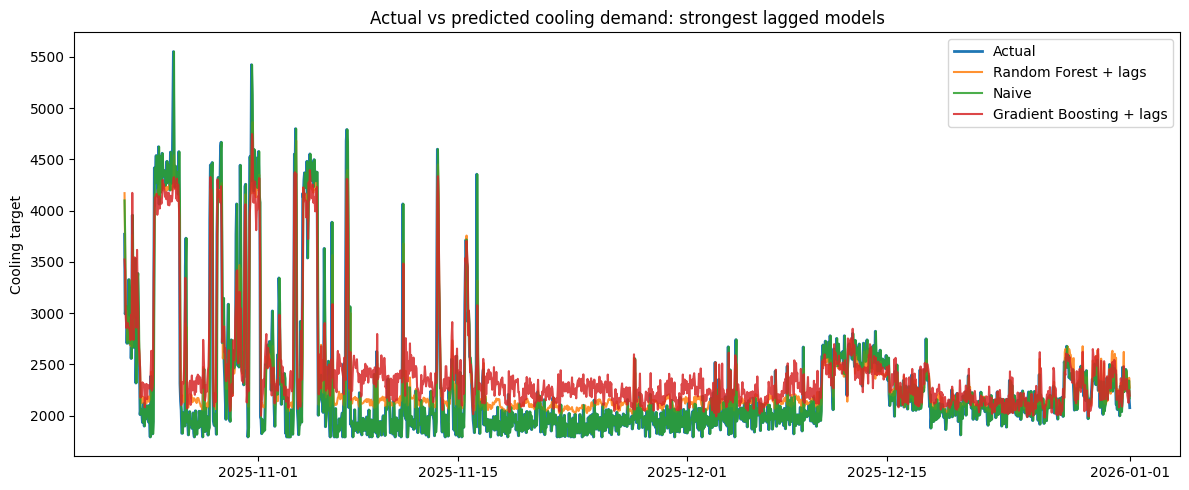

In [95]:
pred_map_e2 = {
    "Naive": y_pred_naive,
    "Linear Regression + lags": y_pred_lr_lag,
    "Random Forest + lags": y_pred_rf_lag,
    "Gradient Boosting + lags": y_pred_gbr_lag,
    "LSTM multivariate": y_pred_lstm_final
}

top_models_e2 = results_e2["model"].head(3).tolist()

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Actual", linewidth=2)

for model_name in top_models_e2:
    pred = pred_map_e2[model_name]
    common_idx = y_test.index.intersection(pred.index)
    plt.plot(common_idx, pred.loc[common_idx], label=model_name, alpha=0.85)

plt.title("Actual vs predicted cooling demand: strongest lagged models")
plt.ylabel("Cooling target")
plt.legend()
plt.tight_layout()
plt.show()

Classical time-series models are also extended with a small exogenous weather set in order to test whether environmental context improves their forecasting performance. This keeps ARIMA/SARIMA centrally integrated in the study design while avoiding an excessively large classical-model tuning branch.

In [96]:
# =========================================================
# CLASSICAL EXOGENOUS BENCHMARK: ARIMAX / SARIMAX
# =========================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

exog_cols = [c for c in ["wx_temp_2m", "wx_dewpoint_2m", "wx_shortwave_rad"] if c in lagged_df.columns]

print("Exogenous columns used:", exog_cols)

train_exog = train_df[exog_cols].copy()
test_exog = test_df[exog_cols].copy()

y_pred_arimax = pd.Series(index=y_test.index, dtype=float)
y_pred_sarimax_exog = pd.Series(index=y_test.index, dtype=float)

# -----------------------------
# ARIMAX
# -----------------------------
try:
    arimax_model = SARIMAX(
        y_train,
        exog=train_exog,
        order=(1, 0, 1),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    arimax_fit = arimax_model.fit(disp=False)
    y_pred_arimax[:] = arimax_fit.forecast(steps=len(y_test), exog=test_exog)
except Exception as e:
    print("ARIMAX failed:", e)

# -----------------------------
# SARIMAX
# -----------------------------
try:
    sarimax_model = SARIMAX(
        y_train,
        exog=train_exog,
        order=(1, 0, 1),
        seasonal_order=(1, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarimax_fit = sarimax_model.fit(disp=False)
    y_pred_sarimax_exog[:] = sarimax_fit.forecast(steps=len(y_test), exog=test_exog)
except Exception as e:
    print("SARIMAX-exog failed:", e)

# -----------------------------
# METRICS
# -----------------------------
arimax_results = pd.DataFrame([
    {
        "model": "ARIMAX",
        "MAE": calc_mae(y_test, y_pred_arimax),
        "RMSE": calc_rmse(y_test, y_pred_arimax)
    },
    {
        "model": "SARIMAX + exog",
        "MAE": calc_mae(y_test, y_pred_sarimax_exog),
        "RMSE": calc_rmse(y_test, y_pred_sarimax_exog)
    }
])

display(arimax_results)

arimax_results.to_csv(csv_dir_E / "arimax_sarimax_exog_results.csv", index=False)

Exogenous columns used: ['wx_temp_2m', 'wx_dewpoint_2m', 'wx_shortwave_rad']


,model,MAE,RMSE
0,ARIMAX,1709.983429,1811.609453
1,SARIMAX + exog,475.038365,652.710733


The LSTM benchmark is evaluated on a scaled version of the lagged main dataset. Unlike tree-based models, neural sequence models are sensitive to feature scale, so input normalization is applied here to provide a fairer neural baseline.

In [97]:
# =========================================================
# FINAL MULTIVARIATE LSTM (SCALED)
# =========================================================
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import tensorflow as tf

lookback = 24

# ---------------------------------------------------------
# 1. SCALE FEATURES USING TRAIN ONLY
# ---------------------------------------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler_X.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler_X.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

y_train_scaled = pd.Series(
    scaler_y.fit_transform(y_train.to_frame()).ravel(),
    index=y_train.index
)

y_test_scaled = pd.Series(
    scaler_y.transform(y_test.to_frame()).ravel(),
    index=y_test.index
)

# ---------------------------------------------------------
# 2. BUILD SEQUENCES
# ---------------------------------------------------------
def make_sequences_from_scaled(X_df, y_series, lookback=24):
    X_seq, y_seq, idx_seq = [], [], []
    Xv = X_df.values
    yv = y_series.values
    idx = X_df.index
    for i in range(lookback, len(X_df)):
        X_seq.append(Xv[i - lookback:i])
        y_seq.append(yv[i])
        idx_seq.append(idx[i])
    return np.array(X_seq), np.array(y_seq), pd.Index(idx_seq)

X_train_seq, y_train_seq, idx_train_seq = make_sequences_from_scaled(
    X_train_scaled, y_train_scaled, lookback
)
X_test_seq, y_test_seq, idx_test_seq = make_sequences_from_scaled(
    X_test_scaled, y_test_scaled, lookback
)

print("Scaled LSTM train seq:", X_train_seq.shape, "test seq:", X_test_seq.shape)

# ---------------------------------------------------------
# 3. MODEL
# ---------------------------------------------------------
tf.keras.backend.clear_session()

lstm_final = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

lstm_final.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_final.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)

# ---------------------------------------------------------
# 4. PREDICT AND INVERSE-TRANSFORM
# ---------------------------------------------------------
y_pred_lstm_scaled = lstm_final.predict(X_test_seq, verbose=0).ravel()

y_pred_lstm_final = pd.Series(
    scaler_y.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).ravel(),
    index=idx_test_seq
)

# optional check
print("Scaled LSTM prediction head:")
print(y_pred_lstm_final.head())

Scaled LSTM train seq: (6724, 24, 53) test seq: (1663, 24, 53)
Scaled LSTM prediction head:
2025-10-23 16:00:00    3908.907715
2025-10-23 17:00:00    3733.937744
2025-10-23 18:00:00    3459.333008
2025-10-23 19:00:00    3248.271484
2025-10-23 20:00:00    3091.786621
dtype: float32


In [98]:
results_e2 = pd.DataFrame([
    {
        "model": "Naive",
        "MAE": calc_mae(y_test, y_pred_naive),
        "RMSE": calc_rmse(y_test, y_pred_naive)
    },
    {
        "model": "Linear Regression + lags",
        "MAE": calc_mae(y_test, y_pred_lr_lag),
        "RMSE": calc_rmse(y_test, y_pred_lr_lag)
    },
    {
        "model": "Random Forest + lags",
        "MAE": calc_mae(y_test, y_pred_rf_lag),
        "RMSE": calc_rmse(y_test, y_pred_rf_lag)
    },
    {
        "model": "Gradient Boosting + lags",
        "MAE": calc_mae(y_test, y_pred_gbr_lag),
        "RMSE": calc_rmse(y_test, y_pred_gbr_lag)
    },
    {
        "model": "LSTM multivariate (scaled)",
        "MAE": calc_mae(y_test.loc[y_pred_lstm_final.index], y_pred_lstm_final),
        "RMSE": calc_rmse(y_test.loc[y_pred_lstm_final.index], y_pred_lstm_final)
    }
]).sort_values("RMSE").reset_index(drop=True)

display(results_e2)

,model,MAE,RMSE
0,Random Forest + lags,186.268427,261.884303
1,Naive,178.606995,310.448222
2,Gradient Boosting + lags,258.247380,323.813578
3,Linear Regression + lags,288.075342,355.100944
4,LSTM multivariate (scaled),969.879350,1026.151097


Scaling substantially improved the LSTM benchmark relative to its earlier unscaled version, confirming that neural sequence models are sensitive to feature scale in this setting. However, even after scaling, the LSTM remains clearly weaker than the best lagged tree-based models and does not outperform the strongest tabular benchmarks on the final main dataset.

The lagged forecasting setup substantially improves the supervised models relative to the initial benchmark layer. Random Forest with lagged target features achieves the strongest RMSE, while naive persistence remains the best model in MAE and therefore continues to serve as a very strong baseline. Gradient Boosting and Linear Regression both improve markedly once lagged features are introduced, confirming that explicit autoregressive structure is essential for this forecasting problem. The classical exogenous benchmark also improves meaningfully when moving from ARIMAX to SARIMAX with weather drivers, but still remains clearly weaker than the best lagged machine-learning models. Overall, the results indicate that short-horizon cooling demand is strongly persistence-driven, but that nonlinear lagged models provide the best balance of predictive flexibility and error reduction.

### E3. Rolling-origin backtesting

The previous subsection compared models on a single chronological split. To obtain a more robust estimate of forecasting performance, this subsection uses expanding-window rolling-origin backtesting. This design evaluates the strongest retained models repeatedly across multiple chronological folds and becomes the main basis for final model selection.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================================================
# E3.1 LOAD CLEAN FINAL MAIN DATASET
# =========================================================
dataset_main = pd.read_csv(csv_dir_C / "model_dataset_main.csv", index_col=0)
dataset_main.index = pd.to_datetime(dataset_main.index, errors="coerce")
dataset_main = dataset_main.sort_index().copy()

# ---------------------------------------------------------
# build lagged supervised dataset
# ---------------------------------------------------------
lag_list = [1, 2, 3, 6, 12, 24, 48, 168]

lagged_df = dataset_main.copy()
for lag in lag_list:
    lagged_df[f"y_lag_{lag}"] = lagged_df["y"].shift(lag)

lagged_df = lagged_df.dropna().copy()

feature_cols_lagged = [c for c in lagged_df.columns if c != "y"]
exog_cols = [c for c in ["wx_temp_2m", "wx_dewpoint_2m", "wx_shortwave_rad"] if c in lagged_df.columns]

print("lagged_df shape:", lagged_df.shape)
print("date range:", lagged_df.index.min(), "to", lagged_df.index.max())
print("feature count:", len(feature_cols_lagged))
print("exog cols:", exog_cols)

# =========================================================
# E3.2 METRICS
# =========================================================
def calc_mae(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred, index=y_true.index if len(y_true) == len(y_pred) else None)
    mask = y_true.notna().values & pd.Series(y_pred).notna().values
    return mean_absolute_error(np.array(y_true)[mask], np.array(y_pred)[mask])

def calc_rmse(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred, index=y_true.index if len(y_true) == len(y_pred) else None)
    mask = y_true.notna().values & pd.Series(y_pred).notna().values
    return np.sqrt(mean_squared_error(np.array(y_true)[mask], np.array(y_pred)[mask]))

# =========================================================
# E3.3 ROLLING-ORIGIN CONFIG
# =========================================================
initial_train_days = 180
test_days = 30
step_days = 30

initial_train_hours = initial_train_days * 24
test_hours = test_days * 24
step_hours = step_days * 24

print("initial_train_hours:", initial_train_hours)
print("test_hours:", test_hours)
print("step_hours:", step_hours)

# =========================================================
# E3.4 BACKTEST LOOP
# =========================================================
fold_rows = []
pred_rows = []

start_train_end = initial_train_hours
fold = 1

while True:
    train_end = start_train_end
    test_start = train_end
    test_end = test_start + test_hours

    if test_end > len(lagged_df):
        break

    train_df = lagged_df.iloc[:train_end].copy()
    test_df = lagged_df.iloc[test_start:test_end].copy()

    X_train = train_df[feature_cols_lagged].copy()
    X_test = test_df[feature_cols_lagged].copy()
    y_train = train_df["y"].copy()
    y_test = test_df["y"].copy()

    # -----------------------------
    # Naive
    # -----------------------------
    y_pred_naive = lagged_df["y"].shift(1).loc[test_df.index]

    # -----------------------------
    # Linear Regression + lags
    # -----------------------------
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = pd.Series(lr.predict(X_test), index=X_test.index)

    # -----------------------------
    # Random Forest + lags
    # -----------------------------
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred_rf = pd.Series(rf.predict(X_test), index=X_test.index)

    # -----------------------------
    # Gradient Boosting + lags
    # -----------------------------
    gbr = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=8,
        max_iter=300,
        min_samples_leaf=20,
        random_state=42
    )
    gbr.fit(X_train, y_train)
    y_pred_gbr = pd.Series(gbr.predict(X_test), index=X_test.index)

    # -----------------------------
    # SARIMAX + exog (optional but retained)
    # -----------------------------
    y_pred_sarimax = pd.Series(index=y_test.index, dtype=float)
    try:
        sarimax_model = SARIMAX(
            y_train,
            exog=train_df[exog_cols],
            order=(1, 0, 1),
            seasonal_order=(1, 1, 1, 24),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        sarimax_fit = sarimax_model.fit(disp=False)
        y_pred_sarimax[:] = sarimax_fit.forecast(steps=len(y_test), exog=test_df[exog_cols])
    except Exception as e:
        print(f"Fold {fold}: SARIMAX failed ->", e)

    # -----------------------------
    # metrics per fold
    # -----------------------------
    fold_metric_rows = [
        ("Naive", y_pred_naive),
        ("Linear Regression + lags", y_pred_lr),
        ("Random Forest + lags", y_pred_rf),
        ("Gradient Boosting + lags", y_pred_gbr),
        ("SARIMAX + exog", y_pred_sarimax),
    ]

    for model_name, pred in fold_metric_rows:
        fold_rows.append({
            "fold": fold,
            "train_start": train_df.index.min(),
            "train_end": train_df.index.max(),
            "test_start": test_df.index.min(),
            "test_end": test_df.index.max(),
            "n_train": len(train_df),
            "n_test": len(test_df),
            "model": model_name,
            "MAE": calc_mae(y_test, pred),
            "RMSE": calc_rmse(y_test, pred)
        })

        tmp = pd.DataFrame({
            "fold": fold,
            "model": model_name,
            "ts_hour": test_df.index,
            "actual": y_test.values,
            "predicted": pred.values
        })
        pred_rows.append(tmp)

    print(
        f"Fold {fold}: "
        f"{train_df.index.min()} -> {train_df.index.max()} | "
        f"test {test_df.index.min()} -> {test_df.index.max()}"
    )

    start_train_end += step_hours
    fold += 1

results_e3_folds = pd.DataFrame(fold_rows)
preds_e3 = pd.concat(pred_rows, ignore_index=True)

display(results_e3_folds.head(10))

results_e3_folds.to_csv(csv_dir_E / "rolling_origin_fold_results.csv", index=False)
preds_e3.to_csv(csv_dir_E / "rolling_origin_predictions.csv", index=False)

lagged_df shape: (8435, 54)
date range: 2025-01-08 01:00:00 to 2025-12-31 23:00:00
feature count: 53
exog cols: ['wx_temp_2m', 'wx_dewpoint_2m', 'wx_shortwave_rad']
initial_train_hours: 4320
test_hours: 720
step_hours: 720
Fold 1: 2025-01-08 01:00:00 -> 2025-07-07 20:00:00 | test 2025-07-07 21:00:00 -> 2025-08-10 18:00:00
Fold 2: 2025-01-08 01:00:00 -> 2025-08-10 18:00:00 | test 2025-08-10 19:00:00 -> 2025-09-09 18:00:00
Fold 3: 2025-01-08 01:00:00 -> 2025-09-09 18:00:00 | test 2025-09-09 19:00:00 -> 2025-10-10 15:00:00
Fold 4: 2025-01-08 01:00:00 -> 2025-10-10 15:00:00 | test 2025-10-10 16:00:00 -> 2025-11-10 12:00:00
Fold 5: 2025-01-08 01:00:00 -> 2025-11-10 12:00:00 | test 2025-11-10 13:00:00 -> 2025-12-10 12:00:00


,fold,train_start,train_end,test_start,test_end,n_train,n_test,model,MAE,RMSE
0,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,Naive,241.925000,317.521014
1,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,Linear Regression + lags,249.252156,317.543820
2,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,Random Forest + lags,214.795126,283.729829
3,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,Gradient Boosting + lags,218.662281,283.826466
4,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,SARIMAX + exog,364.218382,459.922032
5,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,Naive,246.925000,323.774141
6,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,Linear Regression + lags,234.070259,303.603924
7,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,Random Forest + lags,180.722407,241.405640
8,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,Gradient Boosting + lags,174.404906,230.028043
9,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,SARIMAX + exog,306.597677,447.298013


In [101]:
display(results_e3_folds.head(20))

results_e3_folds.to_csv(csv_dir_E / "rolling_origin_fold_results.csv", index=False)
preds_e3.to_csv(csv_dir_E / "rolling_origin_predictions.csv", index=False)

,fold,train_start,train_end,test_start,test_end,n_train,n_test,model,MAE,RMSE
0,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,Naive,241.925000,317.521014
1,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,Linear Regression + lags,249.252156,317.543820
2,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,Random Forest + lags,214.795126,283.729829
3,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,Gradient Boosting + lags,218.662281,283.826466
4,1,2025-01-08 01:00:00,2025-07-07 20:00:00,2025-07-07 21:00:00,2025-08-10 18:00:00,4320,720,SARIMAX + exog,364.218382,459.922032
5,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,Naive,246.925000,323.774141
6,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,Linear Regression + lags,234.070259,303.603924
7,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,Random Forest + lags,180.722407,241.405640
8,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,Gradient Boosting + lags,174.404906,230.028043
9,2,2025-01-08 01:00:00,2025-08-10 18:00:00,2025-08-10 19:00:00,2025-09-09 18:00:00,5040,720,SARIMAX + exog,306.597677,447.298013


In [102]:
results_e3_summary = (
    results_e3_folds.groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std")
    )
    .reset_index()
    .sort_values("RMSE_mean")
    .reset_index(drop=True)
)

display(results_e3_summary)
results_e3_summary.to_csv(csv_dir_E / "rolling_origin_summary.csv", index=False)

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,Gradient Boosting + lags,228.051749,69.290960,306.739060,87.855015
1,Random Forest + lags,222.487411,70.317789,308.307356,93.685877
2,Naive,254.359444,68.002223,369.302055,111.153947
3,Linear Regression + lags,287.317139,108.144351,374.264193,127.707528
4,SARIMAX + exog,604.428176,366.309410,741.967120,415.852473


In [103]:
pooled_rows = []

for model_name, grp in preds_e3.groupby("model"):
    mae_pooled = calc_mae(grp["actual"], grp["predicted"])
    rmse_pooled = calc_rmse(grp["actual"], grp["predicted"])
    pooled_rows.append({
        "model": model_name,
        "MAE_pooled": mae_pooled,
        "RMSE_pooled": rmse_pooled
    })

results_e3_pooled = (
    pd.DataFrame(pooled_rows)
    .sort_values("RMSE_pooled")
    .reset_index(drop=True)
)

display(results_e3_pooled)
results_e3_pooled.to_csv(csv_dir_E / "rolling_origin_pooled_metrics.csv", index=False)

,model,MAE_pooled,RMSE_pooled
0,Gradient Boosting + lags,228.051749,316.644365
1,Random Forest + lags,222.487411,319.491879
2,Naive,254.359444,382.450216
3,Linear Regression + lags,287.317139,391.306857
4,SARIMAX + exog,604.428176,829.977006


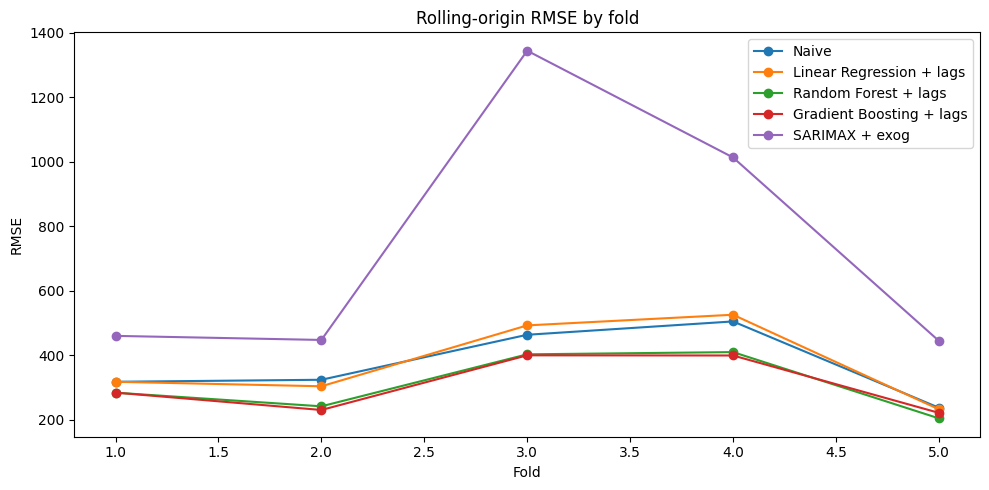

In [104]:
plot_models = [
    "Naive",
    "Linear Regression + lags",
    "Random Forest + lags",
    "Gradient Boosting + lags",
    "SARIMAX + exog"
]

plt.figure(figsize=(10, 5))
for model_name in plot_models:
    tmp = results_e3_folds[results_e3_folds["model"] == model_name]
    plt.plot(tmp["fold"], tmp["RMSE"], marker="o", label=model_name)

plt.title("Rolling-origin RMSE by fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

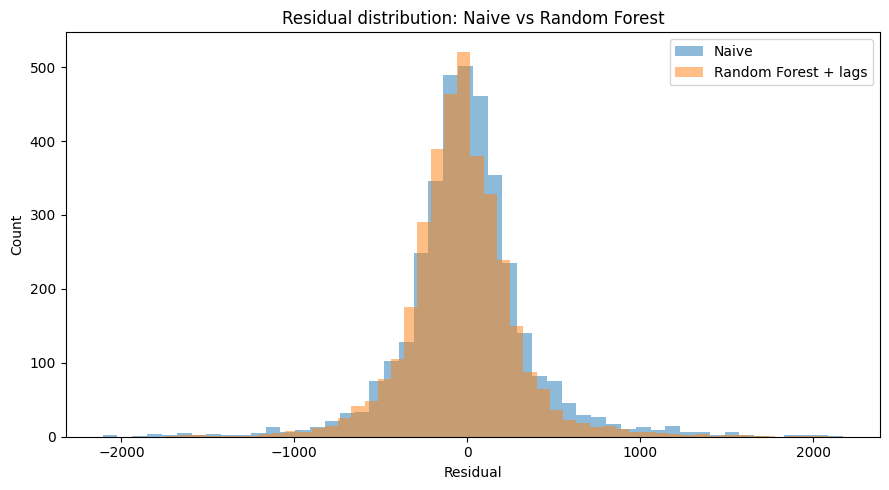

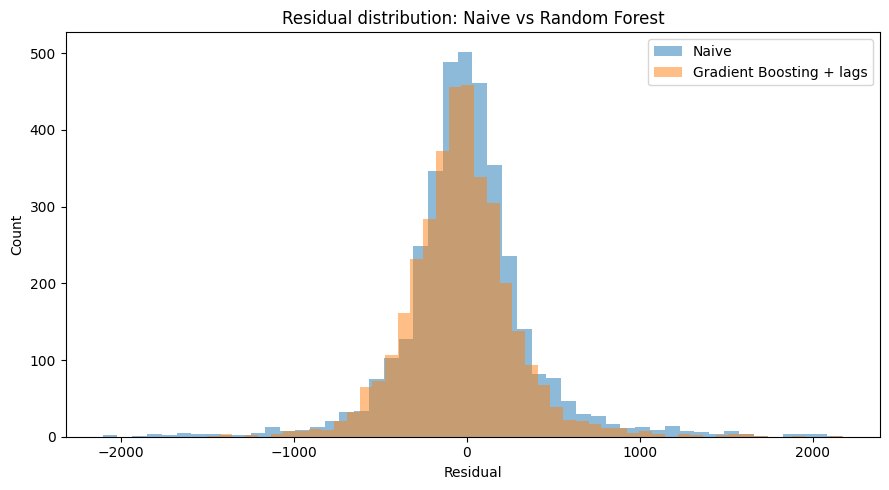

In [105]:
plt.figure(figsize=(9, 5))

for model_name in ["Naive", "Random Forest + lags"]:
    tmp = preds_e3[preds_e3["model"] == model_name].copy()
    residuals = tmp["actual"] - tmp["predicted"]
    plt.hist(residuals, bins=50, alpha=0.5, label=model_name)

plt.title("Residual distribution: Naive vs Random Forest")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))

for model_name in ["Naive", "Gradient Boosting + lags"]:
    tmp = preds_e3[preds_e3["model"] == model_name].copy()
    residuals = tmp["actual"] - tmp["predicted"]
    plt.hist(residuals, bins=50, alpha=0.5, label=model_name)

plt.title("Residual distribution: Naive vs Random Forest")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

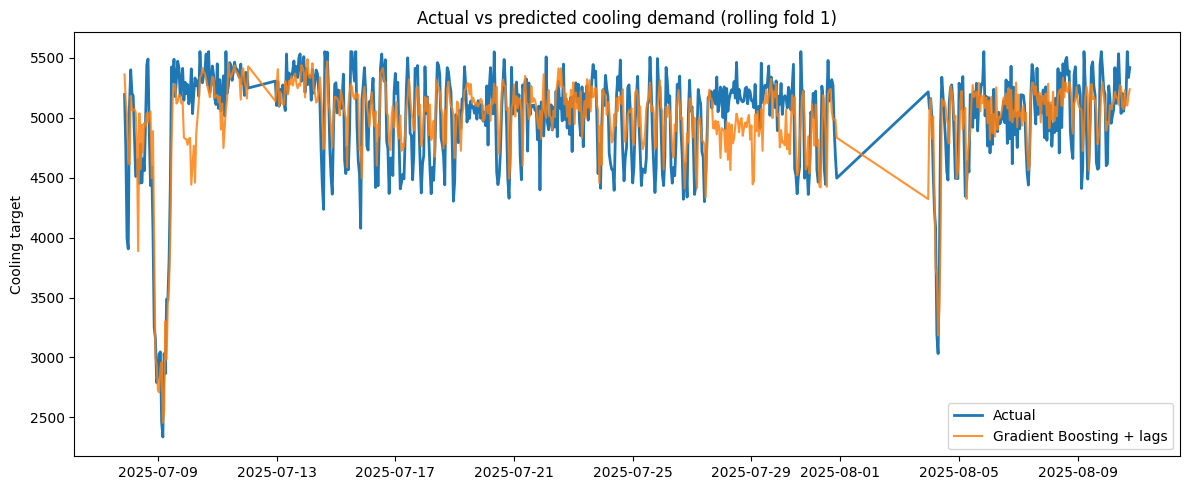

In [ ]:
rep_fold = 1
plot_models_fold = ["Gradient Boosting + lags"]

plt.figure(figsize=(12, 5))

actual_fold = preds_e3[preds_e3["fold"] == rep_fold].drop_duplicates("ts_hour").sort_values("ts_hour")
plt.plot(actual_fold["ts_hour"], actual_fold["actual"], label="Actual", linewidth=2)

for model_name in plot_models_fold:
    tmp = preds_e3[
        (preds_e3["fold"] == rep_fold) &
        (preds_e3["model"] == model_name)
    ].sort_values("ts_hour")
    plt.plot(tmp["ts_hour"], tmp["predicted"], label=model_name, alpha=0.85)

plt.title(f"Actual vs predicted cooling demand (rolling fold {rep_fold})")
plt.ylabel("Cooling target (kW)")
plt.legend()
plt.tight_layout()
plt.show()

The rolling-origin backtesting results provide the main basis for final model selection. Across repeated chronological folds, lagged tree-based models consistently outperform the naive persistence benchmark in RMSE. Gradient Boosting with lagged features achieves the strongest overall performance, with Random Forest performing almost identically and only slightly worse on average. Naive persistence remains a strong baseline, particularly in MAE, but the tree-based models reduce larger forecast errors more effectively. Linear Regression with lags remains weaker, while SARIMAX with exogenous weather variables performs substantially worse and shows much higher fold-to-fold instability. These results indicate that the final cooling-demand forecasting problem is strongly persistence-driven, but best captured by nonlinear lagged supervised models rather than by the classical exogenous benchmark.

### E4. Model interpretation and dataset comparison

After selecting the strongest forecasting family under rolling-origin validation, this subsection examines why the best lagged tree-based models perform well and whether the extended sibling-based dataset materially improves predictive value. The focus is therefore on feature importance, grouped predictor contribution, feature-group ablation, and the comparison between the main and compare dataset designs.

dataset_main: (8603, 46)
dataset_compare: (8603, 69)
main_lag: (8435, 54)
compare_lag: (8435, 77)
RF main single-split MAE: 186.26842652548066
RF main single-split RMSE: 261.8843033660038


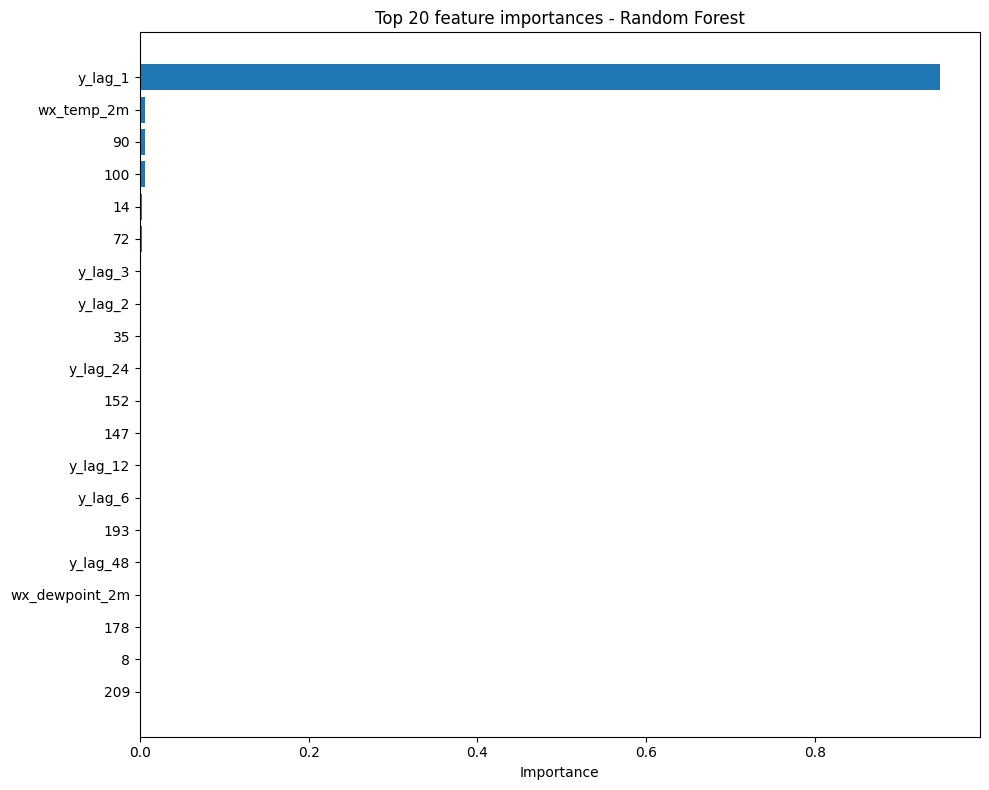

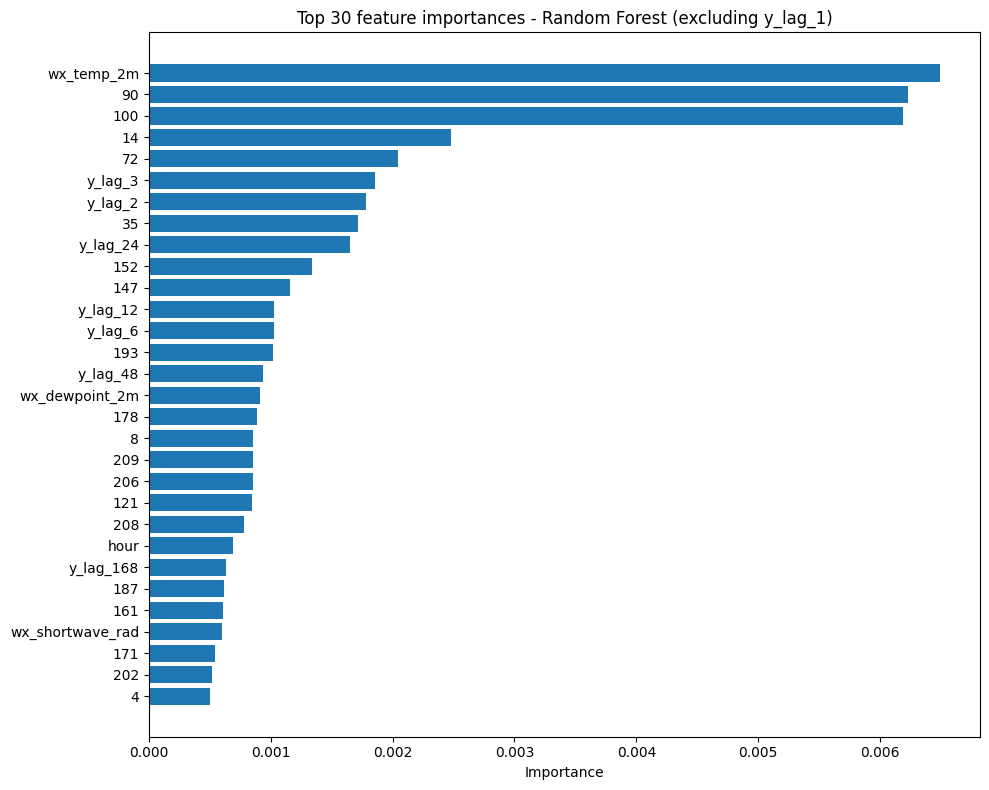

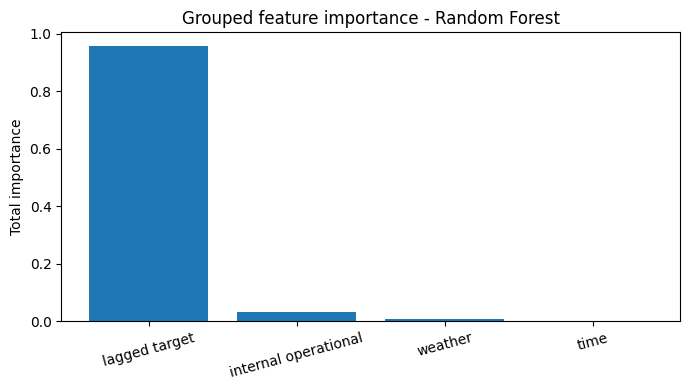

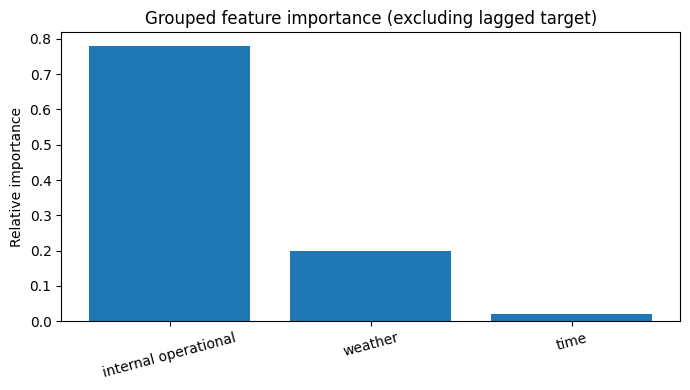

lag_cols: 8
weather_cols: 5
time_cols: 4
internal_operational_cols: 36
sibling_only_cols: 23


,feature_set,n_features,MAE,RMSE
0,lags_weather_operational_siblings,76,185.109024,261.193115
1,lags_weather_operational,53,186.313859,261.874440
2,lags_plus_operational,48,198.248004,273.307318
3,lags_only,8,178.694615,296.699644
4,lags_plus_weather,13,195.624292,305.706284


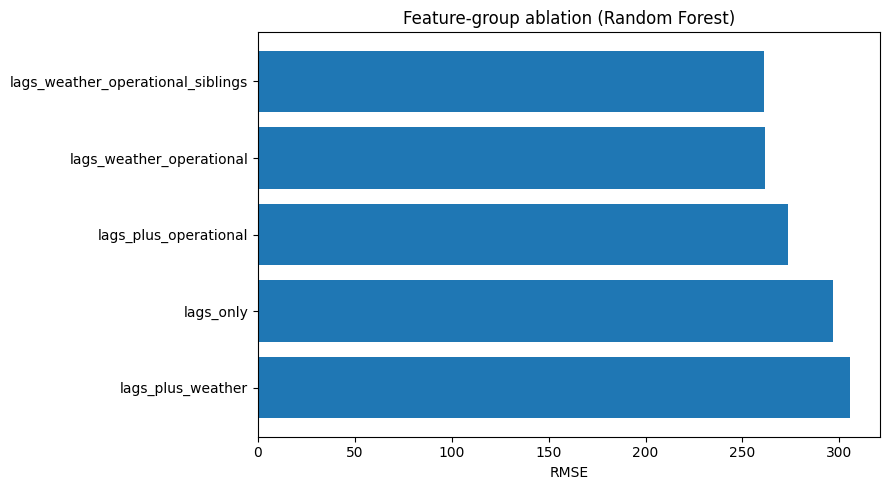

,dataset,model,MAE,RMSE,n_features
0,compare,Random Forest + lags,185.263078,261.214454,76
1,main,Random Forest + lags,186.268427,261.884303,53


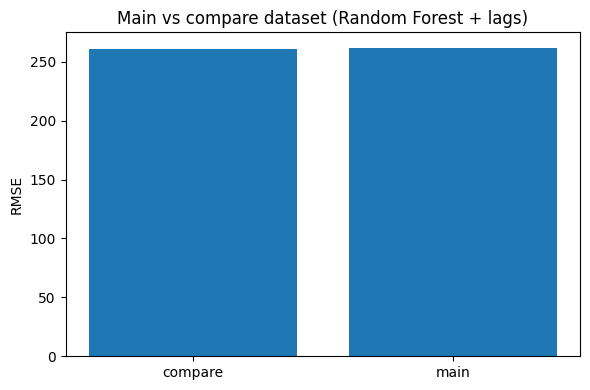

,dataset,n_features,n_lags,n_weather,n_time,n_internal_operational,n_sibling_only
0,main,53,8,5,4,36,0
1,compare,76,8,5,4,36,23


In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# E4. MODEL INTERPRETATION AND DATASET COMPARISON
# =========================================================

# ---------------------------------------------------------
# 1. LOAD FINAL DATASETS
# ---------------------------------------------------------
dataset_main = pd.read_csv(csv_dir_C / "model_dataset_main.csv", index_col=0)
dataset_compare = pd.read_csv(csv_dir_C / "model_dataset_compare.csv", index_col=0)

dataset_main.index = pd.to_datetime(dataset_main.index, errors="coerce")
dataset_compare.index = pd.to_datetime(dataset_compare.index, errors="coerce")

dataset_main = dataset_main.sort_index().copy()
dataset_compare = dataset_compare.sort_index().copy()

print("dataset_main:", dataset_main.shape)
print("dataset_compare:", dataset_compare.shape)

# ---------------------------------------------------------
# 2. BUILD FINAL LAGGED VERSIONS
# ---------------------------------------------------------
lag_list = [1, 2, 3, 6, 12, 24, 48, 168]

def add_target_lags(df, target_col="y", lag_list=None):
    out = df.copy()
    for lag in lag_list:
        out[f"y_lag_{lag}"] = out[target_col].shift(lag)
    return out.dropna().copy()

main_lag = add_target_lags(dataset_main, "y", lag_list)
compare_lag = add_target_lags(dataset_compare, "y", lag_list)

print("main_lag:", main_lag.shape)
print("compare_lag:", compare_lag.shape)

# ---------------------------------------------------------
# 3. HELPER FUNCTIONS
# ---------------------------------------------------------
def calc_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def calc_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def fit_rf_single_split(df, target_col="y"):
    feature_cols = [c for c in df.columns if c != target_col]
    split_idx = int(len(df) * 0.8)

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = train_df[target_col]
    y_test = test_df[target_col]

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = pd.Series(rf.predict(X_test), index=X_test.index)

    return {
        "model": rf,
        "feature_cols": feature_cols,
        "train_df": train_df,
        "test_df": test_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "MAE": calc_mae(y_test, y_pred),
        "RMSE": calc_rmse(y_test, y_pred)
    }

# ---------------------------------------------------------
# 4. FIT RF ON MAIN DATASET FOR INTERPRETATION
# ---------------------------------------------------------
rf_main_fit = fit_rf_single_split(main_lag, target_col="y")

print("RF main single-split MAE:", rf_main_fit["MAE"])
print("RF main single-split RMSE:", rf_main_fit["RMSE"])

rf_model = rf_main_fit["model"]
feature_cols = rf_main_fit["feature_cols"]

# ---------------------------------------------------------
# 5. FULL FEATURE IMPORTANCE
# ---------------------------------------------------------
fi_rf = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

fi_rf.to_csv(csv_dir_E / "rf_feature_importance_full.csv", index=False)

top20_fi = fi_rf.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20_fi["feature"][::-1], top20_fi["importance"][::-1])
plt.title("Top 20 feature importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. FEATURE IMPORTANCE EXCLUDING y_lag_1
# ---------------------------------------------------------
fi_rf_no_lag1 = fi_rf[fi_rf["feature"] != "y_lag_1"].copy().head(30)

fi_rf_no_lag1.to_csv(csv_dir_E / "E4_rf_feature_importance_no_lag1.csv", index=False)

plt.figure(figsize=(10, 8))
plt.barh(fi_rf_no_lag1["feature"][::-1], fi_rf_no_lag1["importance"][::-1])
plt.title("Top 30 feature importances - Random Forest (excluding y_lag_1)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. GROUPED FEATURE IMPORTANCE
# ---------------------------------------------------------
def feature_group(feature):
    feature = str(feature)
    if feature.startswith("y_lag_"):
        return "lagged target"
    if feature.startswith("wx_") or feature.startswith("internal_temp_"):
        return "weather"
    if feature in ["hour", "dayofweek", "month", "is_weekend"]:
        return "time"
    return "internal operational"

grouped_fi = fi_rf.copy()
grouped_fi["group"] = grouped_fi["feature"].apply(feature_group)

grouped_fi_summary = (
    grouped_fi.groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

grouped_fi_summary.to_csv(csv_dir_E / "E4_grouped_feature_importance.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(grouped_fi_summary["group"], grouped_fi_summary["importance"])
plt.title("Grouped feature importance - Random Forest")
plt.ylabel("Total importance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# optional: grouped importance excluding lagged target
grouped_no_lag = grouped_fi_summary[grouped_fi_summary["group"] != "lagged target"].copy()
if not grouped_no_lag.empty:
    grouped_no_lag["importance_norm"] = grouped_no_lag["importance"] / grouped_no_lag["importance"].sum()

    plt.figure(figsize=(7, 4))
    plt.bar(grouped_no_lag["group"], grouped_no_lag["importance_norm"])
    plt.title("Grouped feature importance (excluding lagged target)")
    plt.ylabel("Relative importance")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 8. FEATURE-GROUP ABLATION
# ---------------------------------------------------------
all_main_cols = [c for c in main_lag.columns if c != "y"]

lag_cols = [c for c in all_main_cols if str(c).startswith("y_lag_")]
weather_cols = [
    c for c in all_main_cols
    if str(c).startswith("wx_")
]
time_cols = [c for c in ["hour", "dayofweek", "month", "is_weekend"] if c in all_main_cols]
internal_operational_cols = [
    c for c in all_main_cols
    if c not in lag_cols + weather_cols + time_cols
]

all_compare_cols = [c for c in compare_lag.columns if c != "y"]
sibling_only_cols = [c for c in all_compare_cols if c not in all_main_cols]

print("lag_cols:", len(lag_cols))
print("weather_cols:", len(weather_cols))
print("time_cols:", len(time_cols))
print("internal_operational_cols:", len(internal_operational_cols))
print("sibling_only_cols:", len(sibling_only_cols))

def evaluate_rf_on_features(df, feature_cols, target_col="y"):
    tmp = df[feature_cols + [target_col]].dropna().copy()
    split_idx = int(len(tmp) * 0.8)

    train_df = tmp.iloc[:split_idx].copy()
    test_df = tmp.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = train_df[target_col]
    y_test = test_df[target_col]

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    return {
        "n_features": len(feature_cols),
        "MAE": calc_mae(y_test, y_pred),
        "RMSE": calc_rmse(y_test, y_pred)
    }

ablation_rows = []

ablation_rows.append({
    "feature_set": "lags_only",
    **evaluate_rf_on_features(main_lag, lag_cols)
})

ablation_rows.append({
    "feature_set": "lags_plus_weather",
    **evaluate_rf_on_features(main_lag, lag_cols + weather_cols)
})

ablation_rows.append({
    "feature_set": "lags_plus_operational",
    **evaluate_rf_on_features(main_lag, lag_cols + internal_operational_cols + time_cols)
})

ablation_rows.append({
    "feature_set": "lags_weather_operational",
    **evaluate_rf_on_features(main_lag, lag_cols + weather_cols + internal_operational_cols + time_cols)
})

ablation_rows.append({
    "feature_set": "lags_weather_operational_siblings",
    **evaluate_rf_on_features(compare_lag, lag_cols + weather_cols + internal_operational_cols + time_cols + sibling_only_cols)
})

ablation_results = pd.DataFrame(ablation_rows).sort_values("RMSE").reset_index(drop=True)
display(ablation_results)

ablation_results.to_csv(csv_dir_E / "E4_feature_group_ablation.csv", index=False)

plt.figure(figsize=(9, 5))
plt.barh(ablation_results["feature_set"][::-1], ablation_results["RMSE"][::-1])
plt.title("Feature-group ablation (Random Forest)")
plt.xlabel("RMSE")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. MAIN VS COMPARE DATASET COMPARISON
# ---------------------------------------------------------
rf_main_compare = fit_rf_single_split(main_lag, target_col="y")
rf_compare_compare = fit_rf_single_split(compare_lag, target_col="y")

dataset_compare_results = pd.DataFrame([
    {
        "dataset": "main",
        "model": "Random Forest + lags",
        "MAE": rf_main_compare["MAE"],
        "RMSE": rf_main_compare["RMSE"],
        "n_features": len(rf_main_compare["feature_cols"])
    },
    {
        "dataset": "compare",
        "model": "Random Forest + lags",
        "MAE": rf_compare_compare["MAE"],
        "RMSE": rf_compare_compare["RMSE"],
        "n_features": len(rf_compare_compare["feature_cols"])
    }
]).sort_values("RMSE").reset_index(drop=True)

display(dataset_compare_results)
dataset_compare_results.to_csv(csv_dir_E / "main_vs_compare_results.csv", index=False)

plt.figure(figsize=(6, 4))
plt.bar(dataset_compare_results["dataset"], dataset_compare_results["RMSE"])
plt.title("Main vs compare dataset (Random Forest + lags)")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 10. SMALL FEATURE-COMPOSITION SUMMARY
# ---------------------------------------------------------
feature_summary = pd.DataFrame([
    {
        "dataset": "main",
        "n_features": len([c for c in main_lag.columns if c != "y"]),
        "n_lags": len(lag_cols),
        "n_weather": len(weather_cols),
        "n_time": len(time_cols),
        "n_internal_operational": len(internal_operational_cols),
        "n_sibling_only": 0
    },
    {
        "dataset": "compare",
        "n_features": len([c for c in compare_lag.columns if c != "y"]),
        "n_lags": len([c for c in compare_lag.columns if str(c).startswith("y_lag_")]),
        "n_weather": len([
            c for c in compare_lag.columns
            if str(c).startswith("wx_") or str(c).startswith("internal_temp")
        ]),
        "n_time": len([c for c in ["hour", "dayofweek", "month", "is_weekend"] if c in compare_lag.columns]),
        "n_internal_operational": len(internal_operational_cols),
        "n_sibling_only": len(sibling_only_cols)
    }
])

display(feature_summary)
feature_summary.to_csv(csv_dir_E / "feature_composition_summary.csv", index=False)

The Random Forest importance ranking confirms that the one-hour lag of the cooling target is by far the dominant predictor. This is consistent with the strong performance of the naive persistence baseline and indicates that short-term cooling demand is highly persistence-driven.

Once the dominant one-hour lag is excluded, outside temperature, several internal operational/electrical signals, and longer target lags emerge as the most important secondary predictors. This indicates that the model relies not only on persistence but also on operational and environmental context.

Grouped importance shows that lagged target variables provide most of the predictive power, while internal operational signals contribute substantially more than weather. Time features remain weak. This suggests that the strongest models are driven first by autoregressive structure and second by internal load-related system behavior.

The ablation results show that lagged target variables alone are not sufficient for best performance. Adding internal operational signals provides a substantial improvement, while adding weather variables gives further refinement. The sibling-extended dataset yields only a marginal additional gain relative to the main driver-based dataset.

The compare dataset improves RMSE only marginally relative to the main dataset despite adding 23 additional sibling proxy features. Because this gain is very small, the main dataset remains the preferred analytical basis due to its stronger interpretability and lower target-proximity risk.

The sibling-extended dataset is treated as a comparison variant rather than a primary analytical dataset. For this reason, robust rolling-origin backtesting is centered on the main dataset, while the sibling set is evaluated in a controlled comparison to assess whether target-adjacent proxy signals provide enough additional value to justify their lower interpretability.

,feature,importance_mean,importance_std
0,y_lag_1,390.941680,8.431659
1,90,22.065791,1.989904
2,wx_temp_2m,18.045276,1.338777
3,72,15.625937,1.099950
4,100,12.904101,2.030763
5,35,10.420941,0.713318
6,y_lag_12,7.385311,0.655784
7,14,6.964530,0.932955
8,187,6.485617,0.426581
9,171,6.406678,0.401004


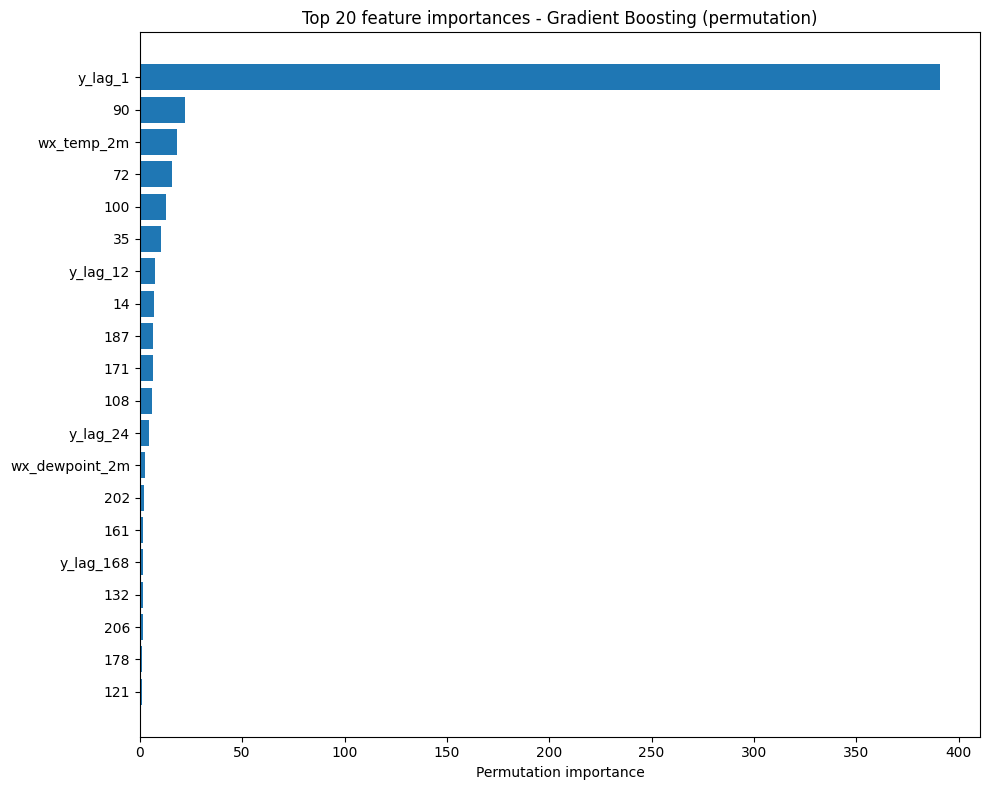

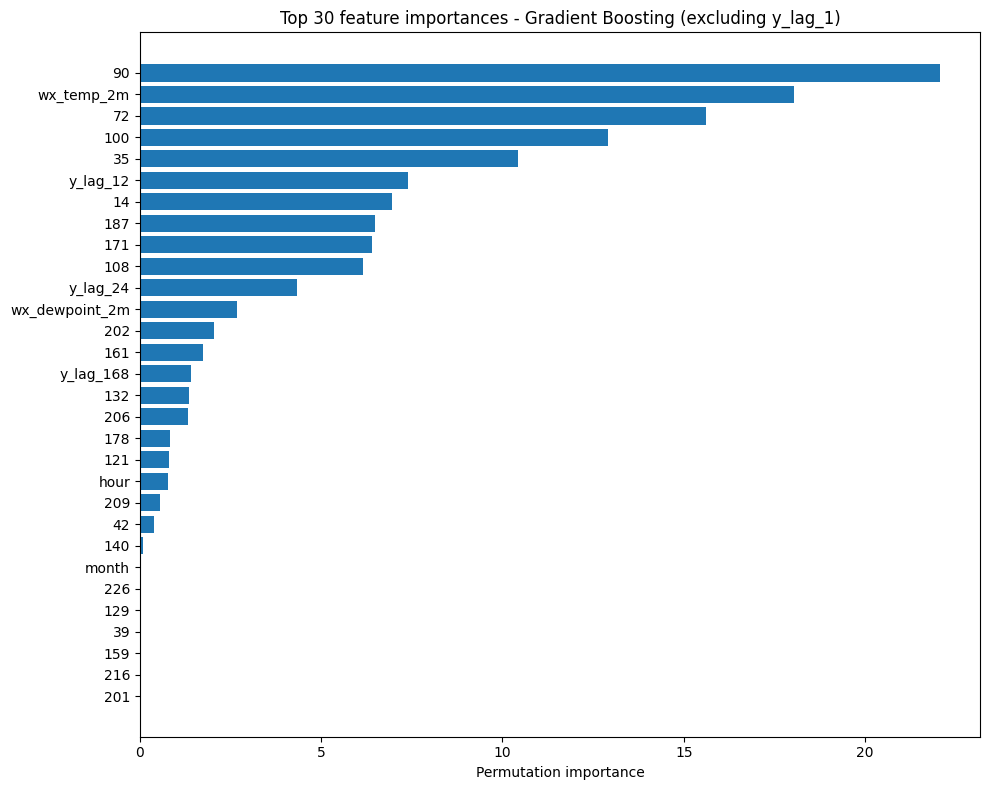

,group,importance_mean
0,lagged target,387.803936
1,internal operational,84.769746
2,weather,19.863015
3,time,0.634776


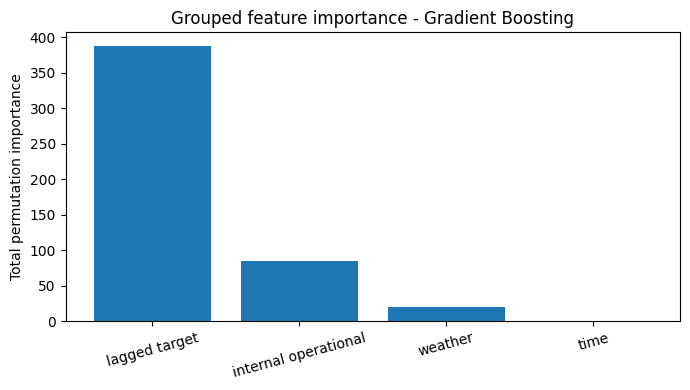

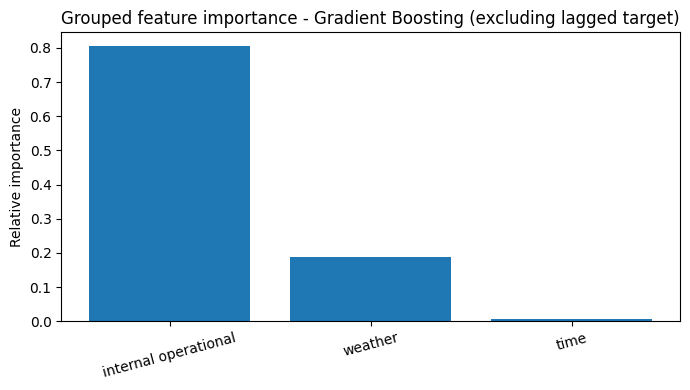

In [108]:
from sklearn.inspection import permutation_importance

# ---------------------------------------------------------
# 11. GRADIENT BOOSTING PERMUTATION IMPORTANCE
# ---------------------------------------------------------
# use the same single-split setup on main_lag
split_idx = int(len(main_lag) * 0.8)

train_df_gb = main_lag.iloc[:split_idx].copy()
test_df_gb = main_lag.iloc[split_idx:].copy()

X_train_gb = train_df_gb.drop(columns=["y"])
X_test_gb = test_df_gb.drop(columns=["y"])
y_train_gb = train_df_gb["y"]
y_test_gb = test_df_gb["y"]

gbr_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=8,
    max_iter=300,
    min_samples_leaf=20,
    random_state=42
)
gbr_model.fit(X_train_gb, y_train_gb)

perm = permutation_importance(
    gbr_model,
    X_test_gb,
    y_test_gb,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

fi_gb = pd.DataFrame({
    "feature": X_test_gb.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(fi_gb.head(20))
fi_gb.to_csv(csv_dir_E / "gb_permutation_importance_full.csv", index=False)

# top 20
top20_gb = fi_gb.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20_gb["feature"][::-1], top20_gb["importance_mean"][::-1])
plt.title("Top 20 feature importances - Gradient Boosting (permutation)")
plt.xlabel("Permutation importance")
plt.tight_layout()
plt.show()

# excluding y_lag_1
fi_gb_no_lag1 = fi_gb[fi_gb["feature"] != "y_lag_1"].copy().head(30)

plt.figure(figsize=(10, 8))
plt.barh(fi_gb_no_lag1["feature"][::-1], fi_gb_no_lag1["importance_mean"][::-1])
plt.title("Top 30 feature importances - Gradient Boosting (excluding y_lag_1)")
plt.xlabel("Permutation importance")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 12. GROUPED PERMUTATION IMPORTANCE FOR GB
# ---------------------------------------------------------
def feature_group(feature):
    feature = str(feature)
    if feature.startswith("y_lag_"):
        return "lagged target"
    if feature.startswith("wx_"):
        return "weather"
    if feature in ["hour", "dayofweek", "month", "is_weekend"]:
        return "time"
    return "internal operational"

grouped_gb = fi_gb.copy()
grouped_gb["group"] = grouped_gb["feature"].apply(feature_group)

grouped_gb_summary = (
    grouped_gb.groupby("group", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(grouped_gb_summary)
grouped_gb_summary.to_csv(csv_dir_E / "E4_gb_grouped_permutation_importance.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(grouped_gb_summary["group"], grouped_gb_summary["importance_mean"])
plt.title("Grouped feature importance - Gradient Boosting")
plt.ylabel("Total permutation importance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# optional: grouped excluding lagged target
grouped_gb_no_lag = grouped_gb_summary[grouped_gb_summary["group"] != "lagged target"].copy()
if not grouped_gb_no_lag.empty:
    grouped_gb_no_lag["importance_norm"] = (
        grouped_gb_no_lag["importance_mean"] / grouped_gb_no_lag["importance_mean"].sum()
    )

    plt.figure(figsize=(7, 4))
    plt.bar(grouped_gb_no_lag["group"], grouped_gb_no_lag["importance_norm"])
    plt.title("Grouped feature importance - Gradient Boosting (excluding lagged target)")
    plt.ylabel("Relative importance")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

Permutation importance for the best-performing Gradient Boosting model confirms the same general structure as the Random Forest analysis: lagged target history dominates, internal operational signals form the strongest secondary group, and weather contributes meaningful but smaller additional value.

A controlled feature-group ablation is used to test whether forecasting performance is driven only by autoregressive structure or whether weather, internal operational signals, and sibling cooling proxies provide meaningful additional information.

dataset_main: (8603, 46)
dataset_compare: (8603, 69)
main_lag: (8435, 54)
compare_lag: (8435, 77)
lag_cols: 8
weather_cols: 5
time_cols: 4
internal_operational_cols: 36
sibling_only_cols: 23

Weather columns: ['wx_temp_2m', 'wx_dewpoint_2m', 'wx_shortwave_rad', 'wx_rh_2m', 'wx_cloud_cover']
Time columns: ['hour', 'dayofweek', 'month', 'is_weekend']
First 10 internal operational columns: ['66', '164', '129', '39', '159', '216', '201', '167', '98', '202']
First 10 sibling-only columns: ['1', '143', '26', '179', '198', '54', '151', '123', '19', '215']


,feature_set,n_features,MAE,RMSE
0,lags_weather_operational_siblings,76,185.109024,261.193115
1,lags_weather_operational,53,186.313859,261.874440
2,lags_plus_operational,48,198.248004,273.307318
3,lags_only,8,178.694615,296.699644
4,lags_plus_weather,13,195.624292,305.706284


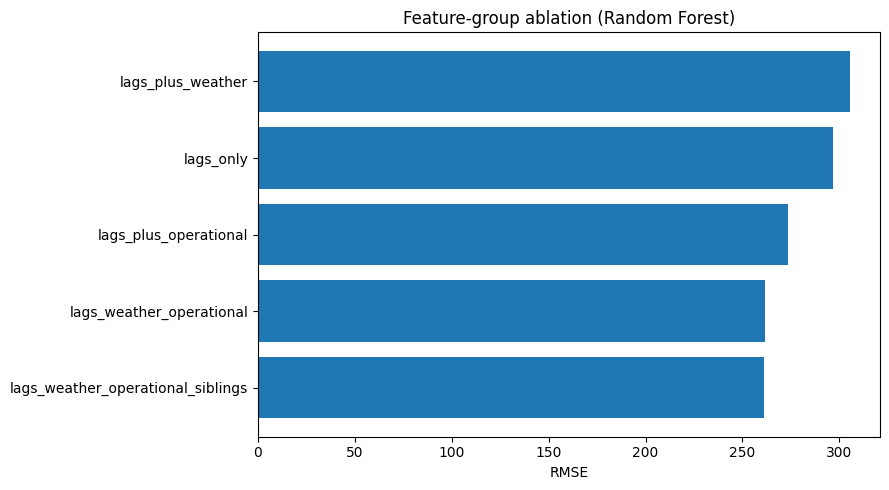

,group,count
0,lags,8
1,weather,5
2,time,4
3,internal operational,36
4,sibling only,23


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# E4. FEATURE-GROUP ABLATION
# =========================================================

# ---------------------------------------------------------
# 1. LOAD FINAL CLEAN DATASETS
# ---------------------------------------------------------
dataset_main = pd.read_csv(csv_dir_C / "model_dataset_main.csv", index_col=0)
dataset_compare = pd.read_csv(csv_dir_C / "model_dataset_compare.csv", index_col=0)

dataset_main.index = pd.to_datetime(dataset_main.index, errors="coerce")
dataset_compare.index = pd.to_datetime(dataset_compare.index, errors="coerce")

dataset_main = dataset_main.sort_index().copy()
dataset_compare = dataset_compare.sort_index().copy()

print("dataset_main:", dataset_main.shape)
print("dataset_compare:", dataset_compare.shape)

# ---------------------------------------------------------
# 2. ADD FINAL TARGET LAGS
# ---------------------------------------------------------
lag_list = [1, 2, 3, 6, 12, 24, 48, 168]

def add_target_lags(df, target_col="y", lag_list=None):
    out = df.copy()
    for lag in lag_list:
        out[f"y_lag_{lag}"] = out[target_col].shift(lag)
    return out.dropna().copy()

main_lag = add_target_lags(dataset_main, "y", lag_list)
compare_lag = add_target_lags(dataset_compare, "y", lag_list)

print("main_lag:", main_lag.shape)
print("compare_lag:", compare_lag.shape)

# ---------------------------------------------------------
# 3. DEFINE FEATURE GROUPS FROM FINAL DATASETS
# ---------------------------------------------------------
all_main_cols = [c for c in main_lag.columns if c != "y"]

lag_cols = [c for c in all_main_cols if str(c).startswith("y_lag_")]
weather_cols = [c for c in all_main_cols if str(c).startswith("wx_")]
time_cols = [c for c in ["hour", "dayofweek", "month", "is_weekend"] if c in all_main_cols]

internal_operational_cols = [
    c for c in all_main_cols
    if c not in lag_cols + weather_cols + time_cols
]

all_compare_cols = [c for c in compare_lag.columns if c != "y"]
sibling_only_cols = [c for c in all_compare_cols if c not in all_main_cols]

print("lag_cols:", len(lag_cols))
print("weather_cols:", len(weather_cols))
print("time_cols:", len(time_cols))
print("internal_operational_cols:", len(internal_operational_cols))
print("sibling_only_cols:", len(sibling_only_cols))

# sanity checks
print("\nWeather columns:", weather_cols)
print("Time columns:", time_cols)
print("First 10 internal operational columns:", internal_operational_cols[:10])
print("First 10 sibling-only columns:", sibling_only_cols[:10])

# ---------------------------------------------------------
# 4. METRICS
# ---------------------------------------------------------
def calc_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def calc_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ---------------------------------------------------------
# 5. CONTROLLED RF EVALUATION
# ---------------------------------------------------------
def evaluate_rf_single_split(df, feature_cols, target_col="y"):
    tmp = df[feature_cols + [target_col]].dropna().copy()

    split_idx = int(len(tmp) * 0.8)

    train_df = tmp.iloc[:split_idx].copy()
    test_df = tmp.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = train_df[target_col]
    y_test = test_df[target_col]

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    return {
        "n_features": len(feature_cols),
        "MAE": calc_mae(y_test, y_pred),
        "RMSE": calc_rmse(y_test, y_pred)
    }

# ---------------------------------------------------------
# 6. ABLATION EXPERIMENTS
# ---------------------------------------------------------
ablation_rows = []

# A. lags only
ablation_rows.append({
    "feature_set": "lags_only",
    **evaluate_rf_single_split(main_lag, lag_cols)
})

# B. lags + weather
ablation_rows.append({
    "feature_set": "lags_plus_weather",
    **evaluate_rf_single_split(main_lag, lag_cols + weather_cols)
})

# C. lags + operational (+ time)
ablation_rows.append({
    "feature_set": "lags_plus_operational",
    **evaluate_rf_single_split(main_lag, lag_cols + internal_operational_cols + time_cols)
})

# D. lags + weather + operational (+ time) -> main dataset full design
ablation_rows.append({
    "feature_set": "lags_weather_operational",
    **evaluate_rf_single_split(main_lag, lag_cols + weather_cols + internal_operational_cols + time_cols)
})

# E. lags + weather + operational (+ time) + siblings -> compare dataset full design
ablation_rows.append({
    "feature_set": "lags_weather_operational_siblings",
    **evaluate_rf_single_split(compare_lag, lag_cols + weather_cols + internal_operational_cols + time_cols + sibling_only_cols)
})

ablation_results = pd.DataFrame(ablation_rows).sort_values("RMSE").reset_index(drop=True)
display(ablation_results)

ablation_results.to_csv(csv_dir_E / "feature_group_ablation.csv", index=False)

# ---------------------------------------------------------
# 7. THESIS-READY BAR CHART
# ---------------------------------------------------------
ablation_plot = ablation_results.sort_values("RMSE", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(ablation_plot["feature_set"], ablation_plot["RMSE"])
plt.title("Feature-group ablation (Random Forest)")
plt.xlabel("RMSE")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. OPTIONAL FEATURE-GROUP SUMMARY TABLE
# ---------------------------------------------------------
group_summary = pd.DataFrame([
    {"group": "lags", "count": len(lag_cols)},
    {"group": "weather", "count": len(weather_cols)},
    {"group": "time", "count": len(time_cols)},
    {"group": "internal operational", "count": len(internal_operational_cols)},
    {"group": "sibling only", "count": len(sibling_only_cols)},
])

display(group_summary)
group_summary.to_csv(csv_dir_E / "feature_group_counts.csv", index=False)

A controlled feature-group ablation is used to test whether forecasting performance is driven only by autoregressive structure or whether weather, internal operational signals, and sibling cooling proxies provide meaningful additional information. Since Gradient Boosting achieved the strongest rolling-origin performance, the same lagged Gradient Boosting setup is used throughout this comparison.

lag_cols: 8
weather_cols: 5
time_cols: 4
internal_operational_cols: 36
sibling_only_cols: 23
Common test_start_ts: 2025-10-22 16:00:00
main train/test: (6748, 54) (1687, 54)
compare train/test: (6748, 77) (1687, 77)


,feature_set,n_train,n_test,n_features,MAE,RMSE
0,lags_only,6748,1687,8,192.940583,310.698448
1,lags_weather_operational,6748,1687,53,258.247380,323.814637
2,lags_plus_weather,6748,1687,13,214.565389,324.571211
3,lags_weather_operational_siblings,6748,1687,76,295.243279,361.207706
4,lags_plus_operational,6748,1687,48,307.621732,369.870925


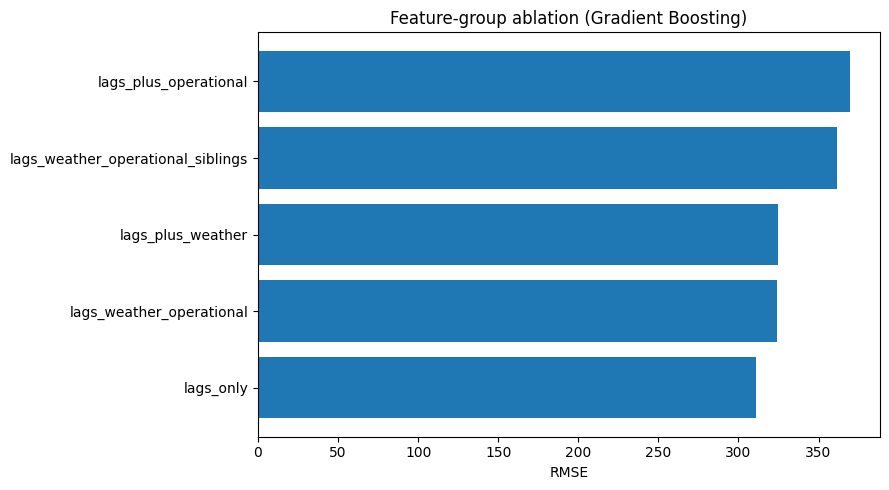

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# DEBUGGED GB ABLATION
# =========================================================

# ---------------------------------------------------------
# 1. LOAD FINAL CLEAN DATASETS
# ---------------------------------------------------------
dataset_main = pd.read_csv(csv_dir_C / "model_dataset_main.csv", index_col=0)
dataset_compare = pd.read_csv(csv_dir_C / "model_dataset_compare.csv", index_col=0)

dataset_main.index = pd.to_datetime(dataset_main.index, errors="coerce")
dataset_compare.index = pd.to_datetime(dataset_compare.index, errors="coerce")

dataset_main = dataset_main.sort_index().copy()
dataset_compare = dataset_compare.sort_index().copy()

# ---------------------------------------------------------
# 2. ADD FINAL TARGET LAGS
# ---------------------------------------------------------
lag_list = [1, 2, 3, 6, 12, 24, 48, 168]

def add_target_lags(df, target_col="y", lag_list=None):
    out = df.copy()
    for lag in lag_list:
        out[f"y_lag_{lag}"] = out[target_col].shift(lag)
    return out.dropna().copy()

main_lag = add_target_lags(dataset_main, "y", lag_list)
compare_lag = add_target_lags(dataset_compare, "y", lag_list)

# ---------------------------------------------------------
# 3. DEFINE FEATURE GROUPS
# ---------------------------------------------------------
all_main_cols = [c for c in main_lag.columns if c != "y"]

lag_cols = [c for c in all_main_cols if str(c).startswith("y_lag_")]
weather_cols = [c for c in all_main_cols if str(c).startswith("wx_") or str(c).startswith("internal_temp")]
time_cols = [c for c in ["hour", "dayofweek", "month", "is_weekend"] if c in all_main_cols]

internal_operational_cols = [
    c for c in all_main_cols
    if c not in lag_cols + weather_cols + time_cols
]

all_compare_cols = [c for c in compare_lag.columns if c != "y"]
sibling_only_cols = [c for c in all_compare_cols if c not in all_main_cols]

print("lag_cols:", len(lag_cols))
print("weather_cols:", len(weather_cols))
print("time_cols:", len(time_cols))
print("internal_operational_cols:", len(internal_operational_cols))
print("sibling_only_cols:", len(sibling_only_cols))

# ---------------------------------------------------------
# 4. METRICS
# ---------------------------------------------------------
def calc_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def calc_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ---------------------------------------------------------
# 5. FIX ONE COMMON SPLIT WINDOW
# ---------------------------------------------------------
# force same split point based on main_lag index
split_idx_main = int(len(main_lag) * 0.8)
test_start_ts = main_lag.index[split_idx_main]

print("Common test_start_ts:", test_start_ts)

# restrict compare_lag to same test start onward for fairness
main_train = main_lag.loc[main_lag.index < test_start_ts].copy()
main_test = main_lag.loc[main_lag.index >= test_start_ts].copy()

compare_train = compare_lag.loc[compare_lag.index < test_start_ts].copy()
compare_test = compare_lag.loc[compare_lag.index >= test_start_ts].copy()

print("main train/test:", main_train.shape, main_test.shape)
print("compare train/test:", compare_train.shape, compare_test.shape)

# ---------------------------------------------------------
# 6. CONTROLLED GB EVALUATION
# ---------------------------------------------------------
def evaluate_gb_on_fixed_split(train_df, test_df, feature_cols, target_col="y"):
    # align to selected columns only
    train_tmp = train_df[feature_cols + [target_col]].dropna().copy()
    test_tmp = test_df[feature_cols + [target_col]].dropna().copy()

    X_train = train_tmp[feature_cols]
    X_test = test_tmp[feature_cols]
    y_train = train_tmp[target_col]
    y_test = test_tmp[target_col]

    gb = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=8,
        max_iter=300,
        min_samples_leaf=20,
        early_stopping=False,   # IMPORTANT FIX
        random_state=42
    )
    gb.fit(X_train, y_train)
    y_pred = gb.predict(X_test)

    return {
        "n_train": len(train_tmp),
        "n_test": len(test_tmp),
        "n_features": len(feature_cols),
        "MAE": calc_mae(y_test, y_pred),
        "RMSE": calc_rmse(y_test, y_pred)
    }

# ---------------------------------------------------------
# 7. ABLATION RUNS
# ---------------------------------------------------------
ablation_rows = []

ablation_rows.append({
    "feature_set": "lags_only",
    **evaluate_gb_on_fixed_split(main_train, main_test, lag_cols)
})

ablation_rows.append({
    "feature_set": "lags_plus_weather",
    **evaluate_gb_on_fixed_split(main_train, main_test, lag_cols + weather_cols)
})

ablation_rows.append({
    "feature_set": "lags_plus_operational",
    **evaluate_gb_on_fixed_split(main_train, main_test, lag_cols + internal_operational_cols + time_cols)
})

ablation_rows.append({
    "feature_set": "lags_weather_operational",
    **evaluate_gb_on_fixed_split(main_train, main_test, lag_cols + weather_cols + internal_operational_cols + time_cols)
})

ablation_rows.append({
    "feature_set": "lags_weather_operational_siblings",
    **evaluate_gb_on_fixed_split(compare_train, compare_test, lag_cols + weather_cols + internal_operational_cols + time_cols + sibling_only_cols)
})

ablation_results_gb_fixed = pd.DataFrame(ablation_rows).sort_values("RMSE").reset_index(drop=True)
display(ablation_results_gb_fixed)

ablation_results_gb_fixed.to_csv(csv_dir_E / "feature_group_ablation_gb_fixed.csv", index=False)

# ---------------------------------------------------------
# 8. PLOT
# ---------------------------------------------------------
plot_df = ablation_results_gb_fixed.sort_values("RMSE", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["feature_set"], plot_df["RMSE"])
plt.title("Feature-group ablation (Gradient Boosting)")
plt.xlabel("RMSE")
plt.tight_layout()
plt.show()

The Gradient Boosting ablation under a fixed chronological split suggests that the model can rely more heavily on lagged target structure alone than Random Forest. However, because this pattern is less consistent with the broader interpretation from permutation importance and dataset-comparison results, the Random Forest ablation is retained as the primary feature-group comparison, while Gradient Boosting permutation importance is used for interpretation of the best-performing model.

As a final consistency check before the operational benchmarking step, the expected-versus-actual cooling analysis is repeated for both Gradient Boosting and Random Forest on the same final main dataset. This checks whether the operational conclusions depend strongly on the choice of the near-tied tree-based benchmark model.

,model,full_excess_pct,full_reduced_pct,full_net_pct,warm_excess_pct,warm_reduced_pct,warm_net_pct
0,Gradient Boosting,1.703198,1.703198,-2.911987e-15,1.340705,1.360980,-0.020275
1,Random Forest,1.848968,1.848968,-1.659888e-16,1.511112,1.472109,0.039003


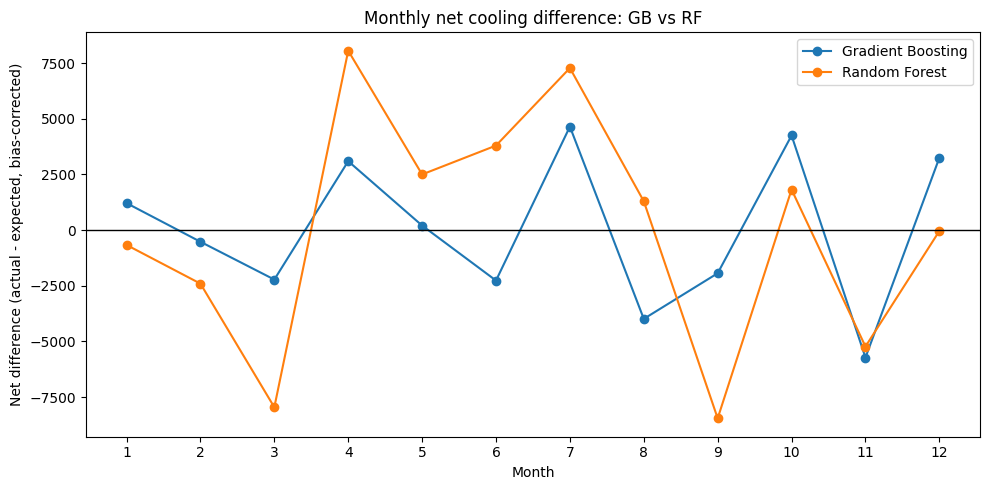

,model,warm_excess_pct,warm_reduced_pct,warm_net_pct
0,Gradient Boosting,1.340705,1.360980,-0.020275
1,Random Forest,1.511112,1.472109,0.039003


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# ---------------------------------------------------------
# load final main dataset
# ---------------------------------------------------------
dataset_main = pd.read_csv(csv_dir_C / "model_dataset_main.csv", index_col=0)
dataset_main.index = pd.to_datetime(dataset_main.index, errors="coerce")
dataset_main = dataset_main.sort_index().copy()

lag_list = [1, 2, 3, 6, 12, 24, 48, 168]

df = dataset_main.copy()
for lag in lag_list:
    df[f"y_lag_{lag}"] = df["y"].shift(lag)

df = df.dropna().copy()

X = df.drop(columns=["y"]).copy()
y = df["y"].copy()

# ---------------------------------------------------------
# fit GB and RF on full data
# ---------------------------------------------------------
gb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=8,
    max_iter=300,
    min_samples_leaf=20,
    random_state=42
)
gb.fit(X, y)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

pred_gb = pd.Series(gb.predict(X), index=y.index, name="pred_gb")
pred_rf = pd.Series(rf.predict(X), index=y.index, name="pred_rf")

# ---------------------------------------------------------
# helper
# ---------------------------------------------------------
def build_benchmark_df(actual, predicted):
    out = pd.DataFrame({
        "actual": actual,
        "predicted": predicted
    }, index=actual.index)
    out["residual"] = out["actual"] - out["predicted"]
    bias = out["residual"].mean()
    out["predicted_bc"] = out["predicted"] + bias
    out["residual_bc"] = out["actual"] - out["predicted_bc"]
    out["excess_bc"] = out["residual_bc"].clip(lower=0)
    out["reduced_bc"] = (-out["residual_bc"]).clip(lower=0)
    out["month"] = out.index.month
    return out, bias

def summarize_model(name, bench_df):
    warm_df = bench_df[bench_df["month"].isin([5, 6, 7, 8, 9])].copy()
    return {
        "model": name,
        "full_excess_pct": bench_df["excess_bc"].sum() / bench_df["actual"].sum() * 100,
        "full_reduced_pct": bench_df["reduced_bc"].sum() / bench_df["actual"].sum() * 100,
        "full_net_pct": bench_df["residual_bc"].sum() / bench_df["actual"].sum() * 100,
        "warm_excess_pct": warm_df["excess_bc"].sum() / warm_df["actual"].sum() * 100,
        "warm_reduced_pct": warm_df["reduced_bc"].sum() / warm_df["actual"].sum() * 100,
        "warm_net_pct": warm_df["residual_bc"].sum() / warm_df["actual"].sum() * 100,
    }

def monthly_summary(bench_df, model_name):
    m = (
        bench_df.groupby("month")
        .agg(
            actual_total=("actual", "sum"),
            predicted_bc_total=("predicted_bc", "sum"),
            net_difference_bc=("residual_bc", "sum"),
            excess_bc=("excess_bc", "sum"),
            reduced_bc=("reduced_bc", "sum"),
        )
        .reset_index()
    )
    m["model"] = model_name
    return m

# ---------------------------------------------------------
# build benchmark dfs
# ---------------------------------------------------------
gb_df, gb_bias = build_benchmark_df(y, pred_gb)
rf_df, rf_bias = build_benchmark_df(y, pred_rf)

comparison_summary = pd.DataFrame([
    summarize_model("Gradient Boosting", gb_df),
    summarize_model("Random Forest", rf_df),
])

display(comparison_summary)

monthly_gb = monthly_summary(gb_df, "Gradient Boosting")
monthly_rf = monthly_summary(rf_df, "Random Forest")
monthly_compare = pd.concat([monthly_gb, monthly_rf], ignore_index=True)

# ---------------------------------------------------------
# plot monthly net difference
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(monthly_gb["month"], monthly_gb["net_difference_bc"], marker="o", label="Gradient Boosting")
plt.plot(monthly_rf["month"], monthly_rf["net_difference_bc"], marker="o", label="Random Forest")
plt.axhline(0, color="black", linewidth=1)
plt.title("Monthly net cooling difference: GB vs RF")
plt.xlabel("Month")
plt.ylabel("Net difference (actual - expected, bias-corrected)")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# warm-season side-by-side
# ---------------------------------------------------------
warm_compare = comparison_summary[["model", "warm_excess_pct", "warm_reduced_pct", "warm_net_pct"]]
display(warm_compare)

The operational benchmarking conclusions are stable across the two near-tied tree-based models: Gradient Boosting and Random Forest produce very similar full-year and warm-season expected-vs-actual results. The main dataset is retained as the primary analytical basis because the sibling-extended dataset improves fit only marginally while reducing interpretability and increasing target-proximity risk.

## E5. Forecast-based benchmarking and efficiency analysis

The selected benchmark model is now used as an expected-demand reference for operational cooling analysis. The goal is to compare actual versus expected cooling, assess whether warm-season excess above expectation is present, and estimate the possible reduction potential under conservative assumptions.

The final benchmark model is taken from the rolling-origin results in Section E3, where Gradient Boosting performed best overall and Random Forest remained very close. Gradient Boosting is therefore used as the primary expected-demand model in the operational analysis below.


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor

# =========================================================
# Load final main dataset and build lagged version
# =========================================================
dataset_main = pd.read_csv(csv_dir_C / "model_dataset_main.csv", index_col=0)
dataset_main.index = pd.to_datetime(dataset_main.index, errors="coerce")
dataset_main = dataset_main.sort_index().copy()

lag_list = [1, 2, 3, 6, 12, 24, 48, 168]

lagged_df = dataset_main.copy()
for lag in lag_list:
    lagged_df[f"y_lag_{lag}"] = lagged_df["y"].shift(lag)

lagged_df = lagged_df.dropna().copy()

feature_cols = [c for c in lagged_df.columns if c != "y"]

print("lagged_df shape:", lagged_df.shape)
print("date range:", lagged_df.index.min(), "to", lagged_df.index.max())

# =========================================================
# Fit selected benchmark model on full data
# =========================================================
gb_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=8,
    max_iter=300,
    min_samples_leaf=20,
    random_state=42
)

gb_final.fit(lagged_df[feature_cols], lagged_df["y"])

y_pred_full = pd.Series(
    gb_final.predict(lagged_df[feature_cols]),
    index=lagged_df.index,
    name="predicted"
)

full_pred_df = pd.DataFrame({
    "actual": lagged_df["y"],
    "predicted": y_pred_full
}, index=lagged_df.index)

full_pred_df["residual"] = full_pred_df["actual"] - full_pred_df["predicted"]
full_pred_df["month"] = full_pred_df.index.month
full_pred_df["hour"] = full_pred_df.index.hour

full_pred_df.head(10)

lagged_df shape: (8435, 54)
date range: 2025-01-08 01:00:00 to 2025-12-31 23:00:00


,actual,predicted,residual,month,hour
ts_hour,,,,,
2025-01-08 01:00:00,2147.0,2253.771364,-106.771364,1,1
2025-01-08 02:00:00,1792.0,2021.448428,-229.448428,1,2
2025-01-08 03:00:00,1907.0,2027.106931,-120.106931,1,3
2025-01-08 04:00:00,2105.0,2228.635884,-123.635884,1,4
2025-01-08 05:00:00,2251.0,2136.166825,114.833175,1,5
2025-01-08 06:00:00,2129.0,2202.377272,-73.377272,1,6
2025-01-08 07:00:00,2326.0,2167.754532,158.245468,1,7
2025-01-08 08:00:00,2297.0,2346.735751,-49.735751,1,8
2025-01-08 09:00:00,2120.0,2173.365004,-53.365004,1,9


Because residual-based benchmarking is sensitive to systematic forecast bias, a simple bias-correction step is applied before interpreting excess or reduced cooling. Monthly and warm-season summaries are then used to assess whether deviations between actual and expected cooling are persistent and operationally meaningful.

In [113]:
# bias correction
bias = full_pred_df["residual"].mean()

full_pred_df["predicted_bias_corrected"] = full_pred_df["predicted"] + bias
full_pred_df["residual_bc"] = full_pred_df["actual"] - full_pred_df["predicted_bias_corrected"]

full_pred_df["excess_cooling_bc"] = full_pred_df["residual_bc"].clip(lower=0)
full_pred_df["reduced_cooling_bc"] = (-full_pred_df["residual_bc"]).clip(lower=0)

bias_summary = pd.DataFrame({
    "metric": [
        "mean_residual_raw",
        "median_residual_raw",
        "mean_actual",
        "mean_predicted_raw",
        "applied_bias_correction"
    ],
    "value": [
        full_pred_df["residual"].mean(),
        full_pred_df["residual"].median(),
        full_pred_df["actual"].mean(),
        full_pred_df["predicted"].mean(),
        bias
    ]
})

bias_summary

,metric,value
0,mean_residual_raw,9.226725e-09
1,median_residual_raw,-3.288362e+00
2,mean_actual,3.377844e+03
3,mean_predicted_raw,3.377844e+03
4,applied_bias_correction,9.226725e-09


In [114]:
summary_full = pd.DataFrame({
    "metric": [
        "total_actual",
        "total_predicted_raw",
        "total_predicted_bias_corrected",
        "net_difference_raw",
        "net_difference_bias_corrected",
        "excess_cooling_bc",
        "reduced_cooling_bc"
    ],
    "value": [
        full_pred_df["actual"].sum(),
        full_pred_df["predicted"].sum(),
        full_pred_df["predicted_bias_corrected"].sum(),
        (full_pred_df["actual"] - full_pred_df["predicted"]).sum(),
        (full_pred_df["actual"] - full_pred_df["predicted_bias_corrected"]).sum(),
        full_pred_df["excess_cooling_bc"].sum(),
        full_pred_df["reduced_cooling_bc"].sum(),
    ]
})

summary_full

,metric,value
0,total_actual,2.849211e+07
1,total_predicted_raw,2.849211e+07
2,total_predicted_bias_corrected,2.849211e+07
3,net_difference_raw,7.782743e-05
4,net_difference_bias_corrected,-8.296865e-10
5,excess_cooling_bc,4.852770e+05
6,reduced_cooling_bc,4.852770e+05


In [115]:
monthly_bc = (
    full_pred_df.groupby("month")
    .agg(
        actual_total=("actual", "sum"),
        predicted_bc_total=("predicted_bias_corrected", "sum"),
        net_difference_bc=("residual_bc", "sum"),
        excess_cooling_bc=("excess_cooling_bc", "sum"),
        reduced_cooling_bc=("reduced_cooling_bc", "sum")
    )
    .reset_index()
)

monthly_bc["pct_net_vs_actual"] = monthly_bc["net_difference_bc"] / monthly_bc["actual_total"] * 100
monthly_bc["pct_excess_vs_actual"] = monthly_bc["excess_cooling_bc"] / monthly_bc["actual_total"] * 100

monthly_bc

,month,actual_total,predicted_bc_total,net_difference_bc,excess_cooling_bc,reduced_cooling_bc,pct_net_vs_actual,pct_excess_vs_actual
0,1,1237336.0,1.236123e+06,1212.834635,27563.421297,26350.586662,0.098020,2.227642
1,2,1504705.0,1.505229e+06,-523.814561,27455.131779,27978.946340,-0.034812,1.824619
2,3,1856178.0,1.858400e+06,-2222.187722,41903.679246,44125.866968,-0.119718,2.257525
3,4,2272514.0,2.269418e+06,3095.671614,50914.834797,47819.163183,0.136222,2.240463
4,5,2898493.0,2.898288e+06,204.931250,56452.194144,56247.262894,0.007070,1.947639
5,6,3573010.0,3.575276e+06,-2265.654061,35350.373572,37616.027634,-0.063410,0.989372
6,7,3646484.0,3.641836e+06,4648.192923,44295.691277,39647.498354,0.127471,1.214751
7,8,3375100.0,3.379087e+06,-3987.361559,37027.339079,41014.700637,-0.118141,1.097074
8,9,2968264.0,2.970202e+06,-1937.640793,47572.496608,49510.137402,-0.065279,1.602704
9,10,1979372.0,1.975122e+06,4250.303277,53306.531285,49056.228008,0.214730,2.693103


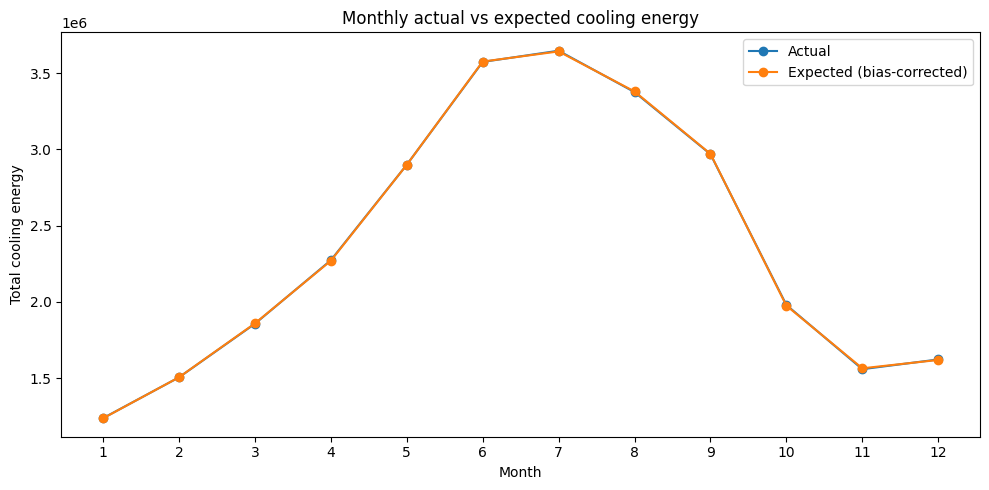

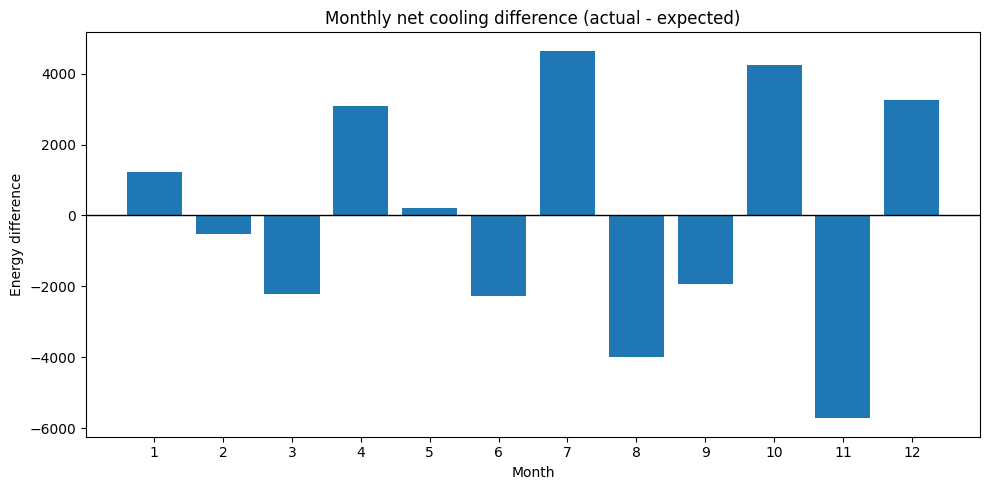

In [116]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_bc["month"], monthly_bc["actual_total"], marker="o", label="Actual")
plt.plot(monthly_bc["month"], monthly_bc["predicted_bc_total"], marker="o", label="Expected (bias-corrected)")
plt.title("Monthly actual vs expected cooling energy")
plt.xlabel("Month")
plt.ylabel("Total cooling energy")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(monthly_bc["month"], monthly_bc["net_difference_bc"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Monthly net cooling difference (actual - expected)")
plt.xlabel("Month")
plt.ylabel("Energy difference")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Because cooling inefficiency is most plausibly expressed during thermally demanding periods, the residual analysis is repeated for the warm season only. Positive residuals are not interpreted directly as reducible energy; instead, a conservative scenario framework is used to identify only persistent and operationally plausible candidate periods of excess cooling.

In [117]:
warm_months = [5, 6, 7, 8, 9]
warm_df = full_pred_df[full_pred_df["month"].isin(warm_months)].copy()

warm_summary = pd.DataFrame({
    "metric": [
        "total_actual",
        "total_predicted_bias_corrected",
        "net_difference_bias_corrected",
        "excess_cooling_bc",
        "reduced_cooling_bc"
    ],
    "value": [
        warm_df["actual"].sum(),
        warm_df["predicted_bias_corrected"].sum(),
        (warm_df["actual"] - warm_df["predicted_bias_corrected"]).sum(),
        warm_df["excess_cooling_bc"].sum(),
        warm_df["reduced_cooling_bc"].sum(),
    ]
})

warm_summary

,metric,value
0,total_actual,1.646135e+07
1,total_predicted_bias_corrected,1.646469e+07
2,net_difference_bias_corrected,-3.337532e+03
3,excess_cooling_bc,2.206981e+05
4,reduced_cooling_bc,2.240356e+05


In [118]:
warm_total_actual = warm_df["actual"].sum()

warm_percent_summary = pd.DataFrame({
    "metric": [
        "warm_excess_pct",
        "warm_reduced_pct",
        "warm_net_pct"
    ],
    "value": [
        warm_df["excess_cooling_bc"].sum() / warm_total_actual * 100,
        warm_df["reduced_cooling_bc"].sum() / warm_total_actual * 100,
        warm_df["residual_bc"].sum() / warm_total_actual * 100
    ]
})

warm_percent_summary

,metric,value
0,warm_excess_pct,1.340705
1,warm_reduced_pct,1.360980
2,warm_net_pct,-0.020275


In [119]:
# meaningful excess threshold = upper quartile of positive residuals
positive_residuals = warm_df.loc[warm_df["residual_bc"] > 0, "residual_bc"]
excess_threshold = positive_residuals.quantile(0.75)

# non-critical load threshold = below 80th percentile actual load
high_load_threshold = warm_df["actual"].quantile(0.80)

warm_df["meaningful_excess"] = warm_df["residual_bc"] >= excess_threshold
warm_df["non_critical_load"] = warm_df["actual"] <= high_load_threshold
warm_df["eligible_reduction"] = warm_df["meaningful_excess"] & warm_df["non_critical_load"]

# persistence filter: at least 2 consecutive hours
warm_df["eligible_int"] = warm_df["eligible_reduction"].astype(int)
group_id = (warm_df["eligible_int"].diff().fillna(0) != 0).cumsum()
run_lengths = warm_df.groupby(group_id)["eligible_int"].transform("sum")
warm_df["control_eligible"] = warm_df["eligible_reduction"] & (run_lengths >= 2)

hours_summary = pd.DataFrame({
    "metric": [
        "warm_hours_total",
        "positive_residual_hours",
        "meaningful_excess_hours",
        "control_eligible_hours"
    ],
    "value": [
        len(warm_df),
        int((warm_df["residual_bc"] > 0).sum()),
        int(warm_df["meaningful_excess"].sum()),
        int(warm_df["control_eligible"].sum())
    ]
})

hours_summary

,metric,value
0,warm_hours_total,3537
1,positive_residual_hours,1832
2,meaningful_excess_hours,458
3,control_eligible_hours,38


In [120]:
warm_df["control_reduction_5pct"] = np.where(
    warm_df["control_eligible"],
    np.minimum(warm_df["residual_bc"], warm_df["actual"] * 0.05),
    0.0
)

warm_df["control_reduction_10pct"] = np.where(
    warm_df["control_eligible"],
    np.minimum(warm_df["residual_bc"], warm_df["actual"] * 0.10),
    0.0
)

improvement_summary = pd.DataFrame({
    "scenario": [
        "raw_warm_excess",
        "persistent_5pct_cap",
        "persistent_10pct_cap"
    ],
    "energy": [
        warm_df["excess_cooling_bc"].sum(),
        warm_df["control_reduction_5pct"].sum(),
        warm_df["control_reduction_10pct"].sum()
    ]
})

improvement_summary["pct_of_warm_actual"] = improvement_summary["energy"] / warm_total_actual * 100
improvement_summary

,scenario,energy,pct_of_warm_actual
0,raw_warm_excess,220698.094680,1.340705
1,persistent_5pct_cap,7630.792324,0.046356
2,persistent_10pct_cap,9420.517506,0.057228


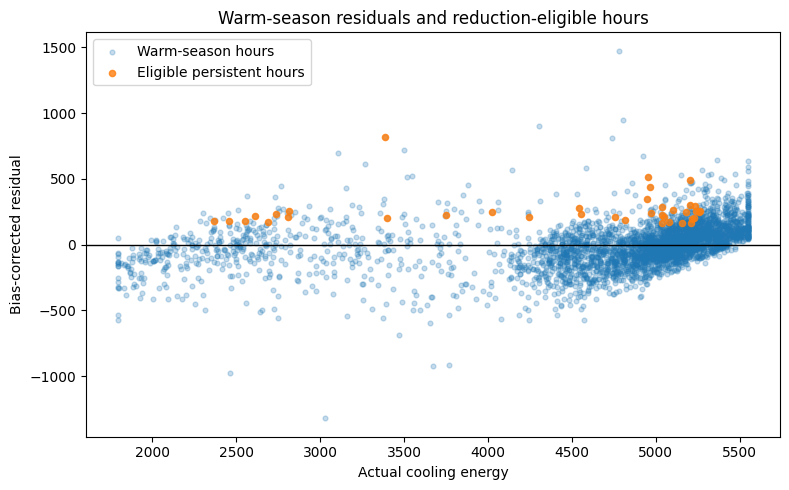

In [121]:
plt.figure(figsize=(8, 5))
plt.scatter(warm_df["actual"], warm_df["residual_bc"], alpha=0.25, s=12, label="Warm-season hours")
plt.scatter(
    warm_df.loc[warm_df["control_eligible"], "actual"],
    warm_df.loc[warm_df["control_eligible"], "residual_bc"],
    alpha=0.8, s=20, label="Eligible persistent hours"
)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Actual cooling energy")
plt.ylabel("Bias-corrected residual")
plt.title("Warm-season residuals and reduction-eligible hours")
plt.legend()
plt.tight_layout()
plt.show()

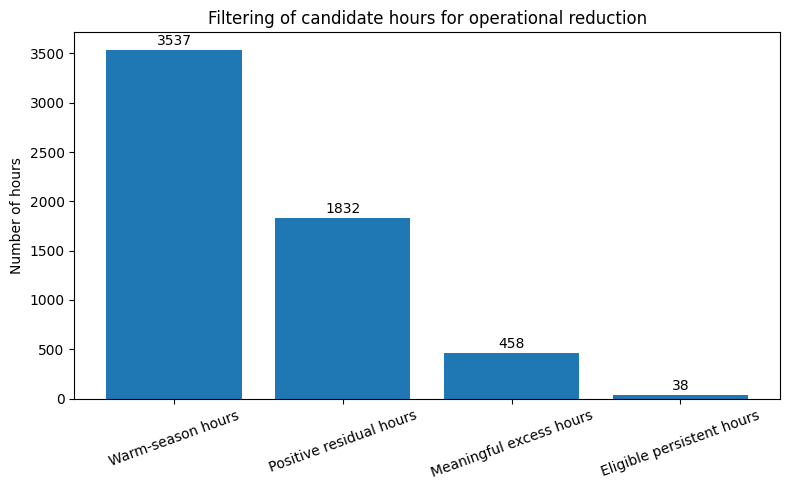

In [122]:
hours_plot = pd.DataFrame({
    "stage": [
        "Warm-season hours",
        "Positive residual hours",
        "Meaningful excess hours",
        "Eligible persistent hours"
    ],
    "count": [
        int(hours_summary.loc[hours_summary["metric"] == "warm_hours_total", "value"].iloc[0]),
        int(hours_summary.loc[hours_summary["metric"] == "positive_residual_hours", "value"].iloc[0]),
        int(hours_summary.loc[hours_summary["metric"] == "meaningful_excess_hours", "value"].iloc[0]),
        int(hours_summary.loc[hours_summary["metric"] == "control_eligible_hours", "value"].iloc[0]),
    ]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(hours_plot["stage"], hours_plot["count"])
plt.ylabel("Number of hours")
plt.title("Filtering of candidate hours for operational reduction")
plt.xticks(rotation=20)

for bar, val in zip(bars, hours_plot["count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{val}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

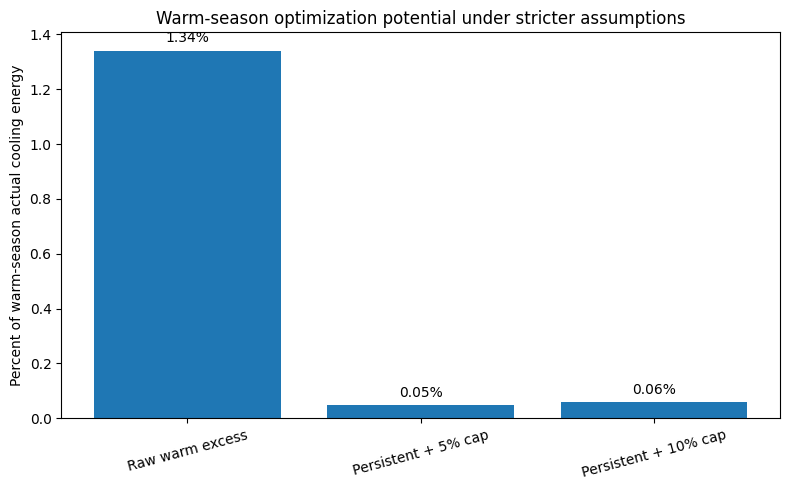

In [123]:
scenario_labels = [
    "Raw warm excess",
    "Persistent + 5% cap",
    "Persistent + 10% cap"
]

values = improvement_summary["pct_of_warm_actual"].values

plt.figure(figsize=(8, 5))
bars = plt.bar(scenario_labels, values)
plt.ylabel("Percent of warm-season actual cooling energy")
plt.title("Warm-season optimization potential under stricter assumptions")
plt.xticks(rotation=15)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

A sensitivity analysis is used to check whether the estimated reduction potential depends strongly on the exact screening rules. This makes the final operational interpretation more robust.

In [124]:
residual_quantiles = [0.50, 0.75, 0.90]
load_quantiles = [0.70, 0.80, 0.90]
persistence_hours = [2, 3]
reduction_caps = [0.05, 0.10]

rows = []

for rq in residual_quantiles:
    pos_res = warm_df.loc[warm_df["residual_bc"] > 0, "residual_bc"]
    excess_threshold = pos_res.quantile(rq)

    for lq in load_quantiles:
        high_load_threshold = warm_df["actual"].quantile(lq)

        tmp = warm_df.copy()
        tmp["meaningful_excess"] = tmp["residual_bc"] >= excess_threshold
        tmp["non_critical_load"] = tmp["actual"] <= high_load_threshold
        tmp["eligible_reduction"] = tmp["meaningful_excess"] & tmp["non_critical_load"]

        tmp["eligible_int"] = tmp["eligible_reduction"].astype(int)
        group_id = (tmp["eligible_int"].diff().fillna(0) != 0).cumsum()
        run_lengths = tmp.groupby(group_id)["eligible_int"].transform("sum")

        for p in persistence_hours:
            tmp["control_eligible"] = tmp["eligible_reduction"] & (run_lengths >= p)

            for cap in reduction_caps:
                reducible = np.where(
                    tmp["control_eligible"],
                    np.minimum(tmp["residual_bc"], tmp["actual"] * cap),
                    0.0
                )

                rows.append({
                    "residual_quantile": rq,
                    "load_quantile": lq,
                    "persistence_hours": p,
                    "reduction_cap": cap,
                    "control_eligible_hours": int(tmp["control_eligible"].sum()),
                    "reducible_energy": reducible.sum(),
                    "pct_of_warm_actual": reducible.sum() / warm_total_actual * 100
                })

sensitivity_results = pd.DataFrame(rows).sort_values(
    ["reduction_cap", "persistence_hours", "residual_quantile", "load_quantile"]
).reset_index(drop=True)

sensitivity_results.head(20)

,residual_quantile,load_quantile,persistence_hours,reduction_cap,control_eligible_hours,reducible_energy,pct_of_warm_actual
0,0.50,0.7,2,0.05,95,14442.798592,0.087738
1,0.50,0.8,2,0.05,151,23820.830434,0.144708
2,0.50,0.9,2,0.05,228,37436.231312,0.227419
3,0.75,0.7,2,0.05,23,4255.700706,0.025853
4,0.75,0.8,2,0.05,38,7630.792324,0.046356
5,0.75,0.9,2,0.05,62,13094.378623,0.079546
6,0.90,0.7,2,0.05,2,502.400000,0.003052
7,0.90,0.8,2,0.05,4,1014.500000,0.006163
8,0.90,0.9,2,0.05,8,2003.600000,0.012172
9,0.50,0.7,3,0.05,11,1406.408428,0.008544


In [125]:
sensitivity_summary = (
    sensitivity_results.groupby(["reduction_cap", "persistence_hours"])
    .agg(
        min_pct=("pct_of_warm_actual", "min"),
        mean_pct=("pct_of_warm_actual", "mean"),
        max_pct=("pct_of_warm_actual", "max")
    )
    .reset_index()
)

sensitivity_summary

,reduction_cap,persistence_hours,min_pct,mean_pct,max_pct
0,0.05,2,0.003052,0.070334,0.227419
1,0.05,3,0.000000,0.012428,0.055511
2,0.10,2,0.003690,0.082068,0.255158
3,0.10,3,0.000000,0.014425,0.062113


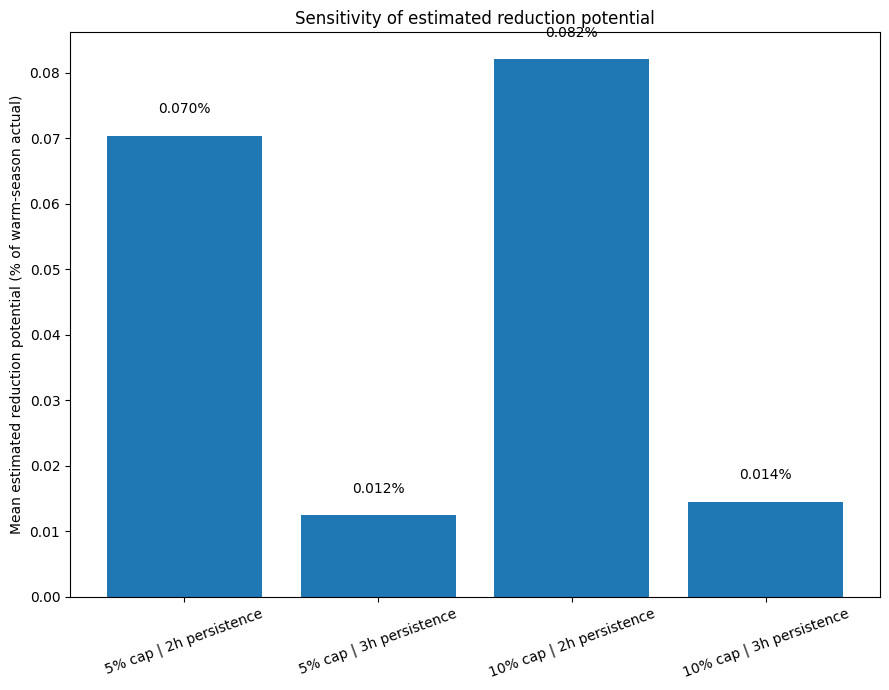

In [126]:
plot_df = sensitivity_summary.copy()
plot_df["label"] = (
    plot_df["reduction_cap"].map({0.05: "5% cap", 0.10: "10% cap"})
    + " | "
    + plot_df["persistence_hours"].astype(str)
    + "h persistence"
)

plt.figure(figsize=(9, 7))
bars = plt.bar(plot_df["label"], plot_df["mean_pct"])
plt.ylabel("Mean estimated reduction potential (% of warm-season actual)")
plt.title("Sensitivity of estimated reduction potential")
plt.xticks(rotation=20)

for bar, val in zip(bars, plot_df["mean_pct"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{val:.3f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Finally, one representative flagged period is inspected directly to illustrate how forecast-based benchmarking identifies candidate hours of above-expected cooling demand in the time series.

In [127]:
flagged_hours = warm_df[warm_df["control_eligible"]].copy()
flagged_hours = flagged_hours.sort_values("residual_bc", ascending=False)

top_flagged = flagged_hours[[
    "actual", "predicted_bias_corrected", "residual_bc", "month"
]].head(20)

top_flagged

,actual,predicted_bias_corrected,residual_bc,month
ts_hour,,,,
2025-05-07 23:00:00,3388.0,2566.560088,821.439912,5
2025-08-04 09:00:00,4952.0,4436.931699,515.068301,8
2025-08-30 05:00:00,5206.0,4718.263898,487.736102,8
2025-05-08 16:00:00,4967.0,4527.137570,439.862430,5
2025-09-17 07:00:00,4946.0,4598.627259,347.372741,9
2025-05-15 22:00:00,5204.0,4904.832136,299.167864,5
2025-05-02 05:00:00,5231.0,4938.953134,292.046866,5
2025-05-15 21:00:00,5038.0,4755.683112,282.316888,5
2025-05-19 09:00:00,4544.0,4268.099182,275.900818,5


## F. Forecast-Informed Intelligent Supervisory Control Strategy Simulation

### F1. Control objective and supervisory architecture

The purpose of this section is to translate the selected cooling-demand forecasting model into an explicit intelligent supervisory control framework for historical simulation. The controller is designed to identify periods in which actual cooling demand exceeds model-expected demand and to test whether bounded intervention would have been plausible under conservative operating conditions.

The implemented control approach is not a deployed closed-loop model predictive controller and does not represent actuator-level industrial control. Instead, it is formulated as a forecast-informed intelligent supervisory control strategy. This positioning is consistent with the reviewed literature, which shows that predictive, constraint-aware decision-making is central to intelligent HVAC control, but that practical deployment of advanced control depends on richer sensing, controllable variables, and validated process models than are available in the present dataset.

The supervisory architecture contains four layers:

1. a forecasting layer that estimates expected cooling demand;
2. a control-state layer that evaluates forecast deviation and operating context;
3. a supervisory decision layer that assigns control states;
4. an action-simulation layer that applies bounded cooling-reduction actions to historical operation.

The manipulated variable is represented in supervisory form as cooling-reduction intensity rather than as a direct actuator command.

### F2. Forecast benchmark generation

The control design uses the final selected forecasting model from the previous section as its benchmark layer. Specifically, Gradient Boosting with lagged target features is fitted on the final lagged main dataset and used to generate expected hourly cooling demand.

The forecasting output is then bias-corrected before operational interpretation. This step is important because residual-based benchmarking is sensitive to systematic prediction bias. The resulting bias-corrected residual, defined as the difference between actual and expected cooling demand, is used as the main trigger for supervisory control logic. Positive residuals are interpreted as model-relative excess cooling demand, but are not treated directly as actionable savings without additional contextual filtering.

### F3. Control-extended dataset construction and operational proxy selection

Because the forecasting dataset was intentionally kept compact and target-focused, an additional control-extended dataset was constructed for the supervisory-control section. This extended dataset retained the final forecasting structure while adding a small number of candidate operational-proxy signals from the broader hourly telemetry exploration.

The purpose of this step is not to redesign the forecasting dataset, but to identify one interpretable indicator of site operating intensity for the control layer. This distinction is important because the engineered cooling target already summarizes multiple cooling-related subsystem signals. Reusing many target-adjacent variables in the supervisory controller would improve numerical coupling but weaken interpretability and increase circularity risk.

Candidate operational proxies were therefore compared on four criteria:
1. data completeness,
2. variability,
3. relation to actual cooling demand,
4. practical interpretability as indicators of operating intensity.

One final proxy is then selected and used as the supervisory load variable in the subsequent control-state design.

In [128]:
# =========================================================
# F3. CONTROL-EXTENDED DATASET CONSTRUCTION
# using hourly_long_2025_exploration.csv
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

candidate_proxy_ids = [33, 169, 122, 179, 80, 188, 90]
candidate_proxy_cols = [str(x) for x in candidate_proxy_ids]

# 1. load hourly exploration file
hourly_long_2025 = pd.read_csv(csv_dir / "hourly_long_2025_exploration.csv")

print("hourly_long_2025 raw:", hourly_long_2025.shape)
display(hourly_long_2025.head())

hourly_long_2025 raw: (942045, 3)


,datapoint_id,ts_hour,value_hour
0,1,2025-01-01 00:00:00+00:00,4900.304688
1,1,2025-01-01 01:00:00+00:00,4900.304688
2,1,2025-01-01 02:00:00+00:00,4900.304688
3,1,2025-01-01 03:00:00+00:00,4900.304688
4,1,2025-01-01 04:00:00+00:00,4900.304688


In [131]:
# 2. clean and filter to candidate proxies
hourly_long_2025["ts_hour"] = pd.to_datetime(hourly_long_2025["ts_hour"], errors="coerce")
hourly_long_2025["datapoint_id"] = hourly_long_2025["datapoint_id"].astype(str)

proxy_long = hourly_long_2025[
    hourly_long_2025["datapoint_id"].isin(candidate_proxy_cols)
].copy()

print("proxy_long:", proxy_long.shape)
display(proxy_long.head(5))

proxy_long: (34444, 3)


,datapoint_id,ts_hour,value_hour
25296,80,2025-01-01 00:00:00+00:00,4.558055
25297,80,2025-01-01 01:00:00+00:00,0.000000
25298,80,2025-01-01 02:00:00+00:00,0.000000
25299,80,2025-01-01 03:00:00+00:00,0.000000
25300,80,2025-01-01 04:00:00+00:00,0.000000


In [132]:
# 3. pivot to wide format
proxy_wide = (
    proxy_long
    .pivot_table(
        index="ts_hour",
        columns="datapoint_id",
        values="value_hour",
        aggfunc="mean"
    )
    .sort_index()
)

proxy_wide.columns = [str(c) for c in proxy_wide.columns]

print("proxy_wide:", proxy_wide.shape)
display(proxy_wide.head())

proxy_wide: (8611, 4)


,179,188,80,90
ts_hour,,,,
2025-01-01 00:00:00+00:00,193277.15625,2.287222,4.558055,163.666191
2025-01-01 01:00:00+00:00,193277.15625,0.000000,0.000000,169.334431
2025-01-01 02:00:00+00:00,193277.15625,0.000000,0.000000,166.187340
2025-01-01 03:00:00+00:00,193277.15625,0.000000,0.000000,169.021465
2025-01-01 04:00:00+00:00,193277.15625,0.000000,0.000000,164.831135


In [133]:
lag_list = [1, 2, 3, 6, 12, 24, 48, 168]

control_df = dataset_main.copy()
for lag in lag_list:
    control_df[f"y_lag_{lag}"] = control_df["y"].shift(lag)

control_df = control_df.dropna().copy()

feature_cols = [c for c in control_df.columns if c != "y"]

# refit final GB
from sklearn.ensemble import HistGradientBoostingRegressor

gb_control = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=8,
    max_iter=300,
    min_samples_leaf=20,
    random_state=42
)

gb_control.fit(control_df[feature_cols], control_df["y"])

control_df["actual"] = control_df["y"]
control_df["predicted"] = gb_control.predict(control_df[feature_cols])
control_df["residual"] = control_df["actual"] - control_df["predicted"]

bias = control_df["residual"].mean()
control_df["predicted_bias_corrected"] = control_df["predicted"] + bias
control_df["residual_bc"] = control_df["actual"] - control_df["predicted_bias_corrected"]

control_df["month"] = control_df.index.month
control_df["hour"] = control_df.index.hour

print(control_df.shape)


(8435, 59)


In [134]:
# make proxy index timezone-naive
proxy_wide_fix = proxy_wide.copy()
proxy_wide_fix.index = pd.to_datetime(proxy_wide_fix.index, errors="coerce")
proxy_wide_fix.index = proxy_wide_fix.index.tz_convert(None).floor("h")
proxy_wide_fix.index.name = "ts_hour"

# make sure control_df index is also normalized
control_df_ext = control_df.copy()
control_df_ext.index = pd.to_datetime(control_df_ext.index, errors="coerce").floor("h")
control_df_ext.index.name = "ts_hour"

# now join
proxy_cols_to_add = [c for c in proxy_wide_fix.columns if c not in control_df_ext.columns]
control_df_ext = control_df_ext.join(proxy_wide_fix[proxy_cols_to_add], how="left")

print("control_df_ext:", control_df_ext.shape)
print("added proxy cols:", proxy_cols_to_add)

common_idx = control_df_ext.index.intersection(proxy_wide_fix.index)
print("n_common_hours:", len(common_idx))
print("first common:", common_idx.min() if len(common_idx) else None)
print("last common :", common_idx.max() if len(common_idx) else None)

proxy_missing = (
    control_df_ext[[c for c in proxy_cols_to_add if c in control_df_ext.columns]]
    .isna()
    .mean()
    .sort_values()
)
display(proxy_missing)

control_df_ext: (8435, 62)
added proxy cols: ['179', '188', '80']
n_common_hours: 8435
first common: 2025-01-08 01:00:00
last common : 2025-12-31 23:00:00


179    0.0
188    0.0
80     0.0
dtype: float64

In [211]:
candidate_proxy_cols = [c for c in ["179", "188", "80"] if c in control_df_ext.columns]

proxy_rows = []

for col in candidate_proxy_cols:
    s = control_df_ext[col].copy()

    completeness = 1 - s.isna().mean()
    std = s.std()
    mean_val = s.mean()

    corr_y = control_df_ext["actual"].corr(s)
    corr_resid = control_df_ext["residual_bc"].corr(s)

    warm_mean = control_df_ext.loc[control_df_ext["month"].isin([5, 6, 7, 8, 9]), col].mean()
    nonwarm_mean = control_df_ext.loc[~control_df_ext["month"].isin([5, 6, 7, 8, 9]), col].mean()

    day_mean = control_df_ext.loc[control_df_ext["hour"].isin(range(10, 19)), col].mean()
    night_mean = control_df_ext.loc[~control_df_ext["hour"].isin(range(10, 19)), col].mean()

    proxy_rows.append({
        "proxy_col": col,
        "completeness": completeness,
        "mean": mean_val,
        "std": std,
        "corr_with_actual": corr_y,
        "corr_with_residual_bc": corr_resid,
        "warm_minus_nonwarm": warm_mean - nonwarm_mean,
        "day_minus_night": day_mean - night_mean
    })

proxy_comparison = pd.DataFrame(proxy_rows).sort_values(
    ["completeness", "corr_with_actual"], ascending=[False, False]
).reset_index(drop=True)

proxy_comparison

,proxy_col,completeness,mean,std,corr_with_actual,corr_with_residual_bc,warm_minus_nonwarm,day_minus_night
0,80,1.0,9.238145,11.028646,0.852726,0.042977,17.205127,1.432680
1,188,1.0,10.791736,12.920856,0.851444,0.043934,20.110189,1.717449
2,179,1.0,193392.700416,66.073517,0.043440,-0.001708,10.330902,0.144397


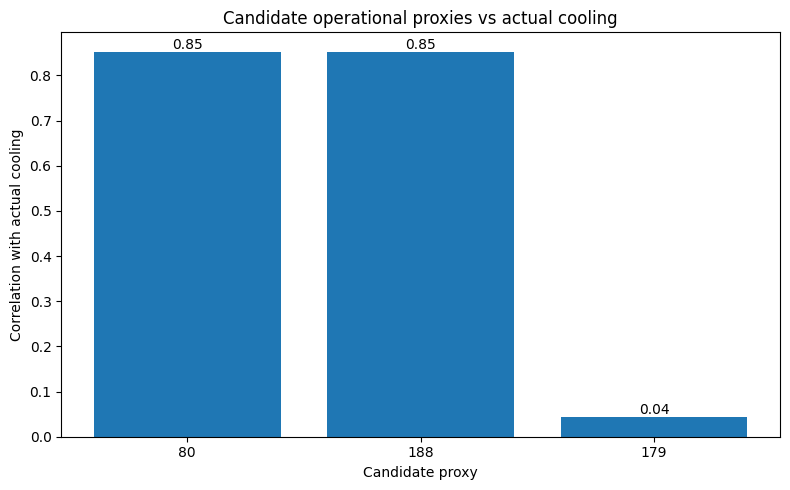

In [212]:
plt.figure(figsize=(8, 5))
bars = plt.bar(proxy_comparison["proxy_col"], proxy_comparison["corr_with_actual"])
plt.xlabel("Candidate proxy")
plt.ylabel("Correlation with actual cooling")
plt.title("Candidate operational proxies vs actual cooling")

for b, h in zip(bars, proxy_comparison["corr_with_actual"]):
    plt.text(b.get_x() + b.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### F4. Control-state design

After selecting the final operational load proxy, the supervisory controller state is constructed from forecast deviation and contextual operating variables. The main decision signal is the bias-corrected residual between actual and expected cooling demand. This is combined with the selected load proxy, a weather-derived thermal-stress proxy, persistence of above-expected demand, and an allowed-hour window. Together, these variables define the operational context in which intervention may or may not be allowed.

In [139]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [213]:
# =========================================================
# F4. CONTROL-STATE DESIGN
# FINAL VERSION WITHOUT internal_temp_proxy
# =========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 0. Final selected load proxy
# ---------------------------------------------------------
load_proxy_col = "179"

control_df_f = control_df_ext.copy()
control_df_f["load_proxy"] = control_df_f[load_proxy_col]

# ---------------------------------------------------------
# 1. ACTIVE CONTROL WINDOW
# ---------------------------------------------------------
warm_months = [5, 6, 7, 8, 9]
allowed_hours = list(range(10, 19))  # 10:00–18:00

control_df_f["warm_season"] = control_df_f["month"].isin(warm_months)
control_df_f["allowed_hour"] = control_df_f["hour"].isin(allowed_hours)

# ---------------------------------------------------------
# 2. DATA-DRIVEN THERMAL CONTEXT SCORE
# final version uses only external weather
# ---------------------------------------------------------
required_cols = ["wx_temp_2m", "wx_dewpoint_2m"]
missing_cols = [c for c in required_cols if c not in control_df_f.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for thermal context: {missing_cols}")

thermal_df = control_df_f[required_cols].copy().dropna()

thermal_scaler = StandardScaler()
thermal_X = thermal_scaler.fit_transform(thermal_df)

thermal_pca = PCA(n_components=1, random_state=42)
thermal_score = thermal_pca.fit_transform(thermal_X).flatten()

# orient score so higher = warmer / more stressful
if np.corrcoef(thermal_score, thermal_df["wx_temp_2m"].values)[0, 1] < 0:
    thermal_score = -thermal_score

control_df_f["thermal_context_score"] = np.nan
control_df_f.loc[thermal_df.index, "thermal_context_score"] = thermal_score
control_df_f["thermal_context_score"] = control_df_f["thermal_context_score"].interpolate(limit_direction="both")

# ---------------------------------------------------------
# 3. THERMAL STATE
# ---------------------------------------------------------
stress_q1 = control_df_f["thermal_context_score"].quantile(0.33)
stress_q2 = control_df_f["thermal_context_score"].quantile(0.66)

def thermal_state(x):
    if x <= stress_q1:
        return "LOW"
    elif x <= stress_q2:
        return "MEDIUM"
    else:
        return "HIGH"

control_df_f["thermal_state"] = control_df_f["thermal_context_score"].apply(thermal_state)

# ---------------------------------------------------------
# 4. EXCESS STATE
# ---------------------------------------------------------
positive_residuals = control_df_f.loc[control_df_f["residual_bc"] > 0, "residual_bc"]

mild_excess_threshold = positive_residuals.quantile(0.50)
strong_excess_threshold = positive_residuals.quantile(0.75)

def excess_state(x):
    if x <= 0:
        return "NONE"
    elif x < strong_excess_threshold:
        return "MILD"
    else:
        return "STRONG"

control_df_f["excess_state"] = control_df_f["residual_bc"].apply(excess_state)

# ---------------------------------------------------------
# 5. PERSISTENCE
# ---------------------------------------------------------
control_df_f["meaningful_excess_flag"] = control_df_f["residual_bc"] >= strong_excess_threshold
control_df_f["meaningful_excess_int"] = control_df_f["meaningful_excess_flag"].astype(int)

group_id = (control_df_f["meaningful_excess_int"].diff().fillna(0) != 0).cumsum()
run_lengths = control_df_f.groupby(group_id)["meaningful_excess_int"].transform("sum")

control_df_f["persistent_excess"] = (
    control_df_f["meaningful_excess_flag"] & (run_lengths >= 2)
)

# ---------------------------------------------------------
# 6. LOAD STATE
# ---------------------------------------------------------
load_q1 = control_df_f["load_proxy"].quantile(0.33)
load_q2 = control_df_f["load_proxy"].quantile(0.66)

def load_state(x):
    if x <= load_q1:
        return "LOW"
    elif x <= load_q2:
        return "MEDIUM"
    else:
        return "HIGH"

control_df_f["load_state"] = control_df_f["load_proxy"].apply(load_state)

# ---------------------------------------------------------
# 7. SUMMARY
# ---------------------------------------------------------
state_summary_f = {
    "warm_season_hours": int(control_df_f["warm_season"].sum()),
    "allowed_hour_hours": int(control_df_f["allowed_hour"].sum()),
    "positive_residual_hours": int((control_df_f["residual_bc"] > 0).sum()),
    "meaningful_excess_hours": int(control_df_f["meaningful_excess_flag"].sum()),
    "persistent_excess_hours": int(control_df_f["persistent_excess"].sum()),
    "load_state_counts": control_df_f["load_state"].value_counts().to_dict(),
    "thermal_state_counts": control_df_f["thermal_state"].value_counts().to_dict(),
    "excess_state_counts": control_df_f["excess_state"].value_counts().to_dict(),
    "thermal_pca_explained_variance": float(thermal_pca.explained_variance_ratio_[0])
}

state_summary_f

{'warm_season_hours': 3537,
 'allowed_hour_hours': 3159,
 'positive_residual_hours': 4130,
 'meaningful_excess_hours': 1033,
 'persistent_excess_hours': 213,
 'load_state_counts': {'HIGH': 2858, 'MEDIUM': 2793, 'LOW': 2784},
 'thermal_state_counts': {'HIGH': 2868, 'LOW': 2784, 'MEDIUM': 2783},
 'excess_state_counts': {'NONE': 4305, 'MILD': 3097, 'STRONG': 1033},
 'thermal_pca_explained_variance': 0.9433282566143305}

### F5. Operating-mode discovery

To add a data-driven supervisory context layer, K-means clustering is applied to the selected load proxy, outside temperature, dew point, and hour of day. The discovered clusters are interpreted as low-, medium-, and high-risk operating modes and used by the strongest control strategy to determine whether intervention should be allowed, limited, or blocked.

In [214]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# K selection for operating-mode clustering
# FINAL VERSION
# =========================================================

# ---------------------------------------------------------
# 1. Choose the variables used for clustering
# final design:
#   load proxy
#   thermal context score
#   hour
# ---------------------------------------------------------
cluster_vars = ["load_proxy", "thermal_context_score", "hour"]
missing_cluster_vars = [c for c in cluster_vars if c not in control_df_f.columns]
if missing_cluster_vars:
    raise ValueError(f"Missing clustering variables in control_df_f: {missing_cluster_vars}")

cluster_eval_df = control_df_f[cluster_vars].dropna().copy()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_eval_df)

# ---------------------------------------------------------
# 2. Evaluate candidate K values
# ---------------------------------------------------------
k_rows = []

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)

    sil = silhouette_score(X_cluster, labels)
    ch = calinski_harabasz_score(X_cluster, labels)
    db = davies_bouldin_score(X_cluster, labels)

    counts = pd.Series(labels).value_counts().sort_index()
    min_cluster = counts.min()
    max_cluster = counts.max()
    imbalance_ratio = max_cluster / min_cluster

    k_rows.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster),
        "max_cluster_size": int(max_cluster),
        "imbalance_ratio": imbalance_ratio
    })

k_eval = pd.DataFrame(k_rows)
display(k_eval)

,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,imbalance_ratio
0,2,0.319056,3814.389019,1.280317,2955,5480,1.854484
1,3,0.366267,4683.768571,1.076463,2204,3424,1.553539
2,4,0.354662,5068.663835,0.909915,1752,2421,1.381849
3,5,0.368762,5461.673664,0.882785,1417,2026,1.429781


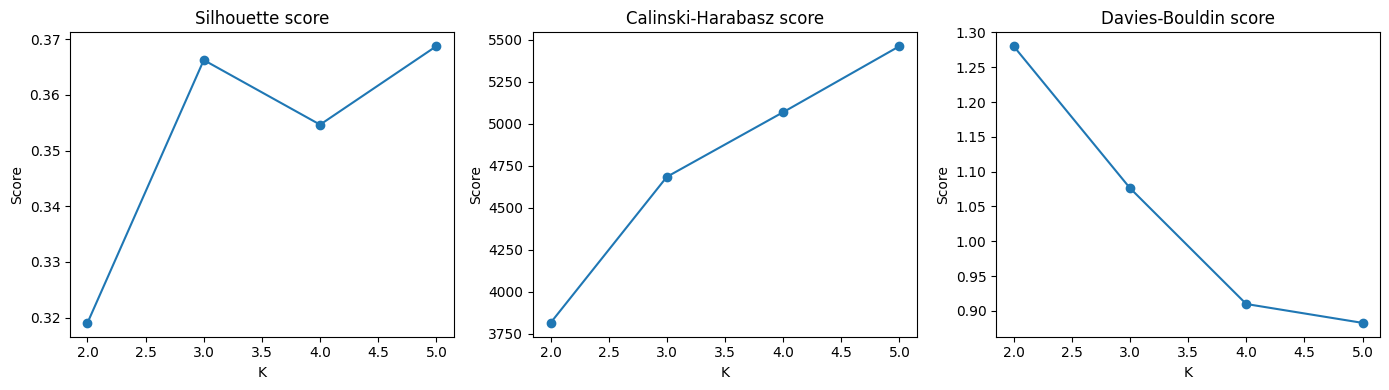

In [215]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(k_eval["k"], k_eval["silhouette"], marker="o")
axes[0].set_title("Silhouette score")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Score")

axes[1].plot(k_eval["k"], k_eval["calinski_harabasz"], marker="o")
axes[1].set_title("Calinski-Harabasz score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

axes[2].plot(k_eval["k"], k_eval["davies_bouldin"], marker="o")
axes[2].set_title("Davies-Bouldin score")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [218]:
# choose smallest K within 95% of best silhouette
best_sil = k_eval["silhouette"].max()
candidate_k = k_eval[k_eval["silhouette"] >= 0.95 * best_sil].copy()
k_eval["silhouette_gap"] = best_sil - k_eval["silhouette"]

# prefer 3 if its silhouette is close enough to the best
sil_k3 = float(k_eval.loc[k_eval["k"] == 3, "silhouette"].iloc[0])

if sil_k3 >= 0.95 * best_sil:
    best_k = 3
else:
    best_k = int(k_eval.sort_values(["silhouette", "calinski_harabasz"], ascending=[False, False]).iloc[0]["k"])

print("Selected best_k:", best_k)

Selected best_k: 3


In [220]:
# ---------------------------------------------------------
# 5. Fit final K-means
# ---------------------------------------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
final_labels = kmeans.fit_predict(X_cluster)

cluster_df = cluster_eval_df.copy()
cluster_df["cluster"] = final_labels

control_df_f["cluster"] = np.nan
control_df_f.loc[cluster_df.index, "cluster"] = cluster_df["cluster"]

In [221]:
# ---------------------------------------------------------
# 6. Build cluster summary correctly
# ---------------------------------------------------------
cluster_summary = (
    control_df_f.groupby("cluster")
    .agg(
        n_hours=("actual", "count"),
        load_proxy_mean=("load_proxy", "mean"),
        thermal_context_mean=("thermal_context_score", "mean"),
        internal_temp_mean=("internal_temp_proxy", "mean") if "internal_temp_proxy" in control_df_f.columns else ("load_proxy", "mean"),
        hour_mean=("hour", "mean"),
        residual_mean=("residual_bc", "mean")
    )
    .reset_index()
)

display(cluster_summary)

,cluster,n_hours,load_proxy_mean,thermal_context_mean,internal_temp_mean,hour_mean,residual_mean
0,0.0,2204,193477.709424,-0.834751,193477.709424,10.971416,-0.310631
1,1.0,3424,193399.189013,1.392468,193399.189013,12.400409,0.603317
2,2.0,2807,193318.038211,-1.043114,193318.038211,10.799074,-0.492030


The number of clusters was selected by comparing candidate partitions across several internal cluster validity criteria rather than relying on a single index. Average silhouette width was used to assess the balance between cohesion and separation (Rousseeuw, 1987), the Calinski–Harabasz index was used to compare between-cluster and within-cluster dispersion (Caliński and Harabasz, 1974), and the Davies–Bouldin index was used to evaluate cluster compactness relative to separation from the most similar neighbouring cluster (Davies and Bouldin, 1979). Because comparative studies show that no single internal criterion is uniformly optimal across all clustering settings, the final choice of K was based on concordance across indices rather than on one metric alone (Vendramin et al., 2010; Arbelaitz et al., 2013). In the present case, K=3 was selected because it maximized both the silhouette and Calinski–Harabasz criteria, while also substantially improving the Davies–Bouldin score relative to K=2. Larger values of K yielded only marginal additional improvement in Davies–Bouldin at the cost of weaker silhouette and Calinski–Harabasz values, suggesting limited additional structure beyond three clusters.

In [222]:
# ---------------------------------------------------------
# 7. Risk score and mode labels
# lower risk = lower load + lower thermal context
# ---------------------------------------------------------
cluster_summary["load_rank_pct"] = cluster_summary["load_proxy_mean"].rank(pct=True)
cluster_summary["thermal_rank_pct"] = cluster_summary["thermal_context_mean"].rank(pct=True)

cluster_summary["risk_score"] = (
    cluster_summary["load_rank_pct"] +
    cluster_summary["thermal_rank_pct"]
) / 2.0

cluster_summary = cluster_summary.sort_values("risk_score").reset_index(drop=True)

mode_labels = ["LOW_RISK", "MEDIUM_RISK", "HIGH_RISK", "VERY_HIGH_RISK"][:best_k]
mode_map = {}

for i, row in cluster_summary.iterrows():
    mode_map[row["cluster"]] = mode_labels[i]

control_df_f["operating_mode"] = control_df_f["cluster"].map(mode_map)
cluster_summary["operating_mode"] = cluster_summary["cluster"].map(mode_map)

display(cluster_summary)

,cluster,n_hours,load_proxy_mean,thermal_context_mean,internal_temp_mean,hour_mean,residual_mean,load_rank_pct,thermal_rank_pct,risk_score,operating_mode
0,2.0,2807,193318.038211,-1.043114,193318.038211,10.799074,-0.492030,0.333333,0.333333,0.333333,LOW_RISK
1,0.0,2204,193477.709424,-0.834751,193477.709424,10.971416,-0.310631,1.000000,0.666667,0.833333,MEDIUM_RISK
2,1.0,3424,193399.189013,1.392468,193399.189013,12.400409,0.603317,0.666667,1.000000,0.833333,HIGH_RISK


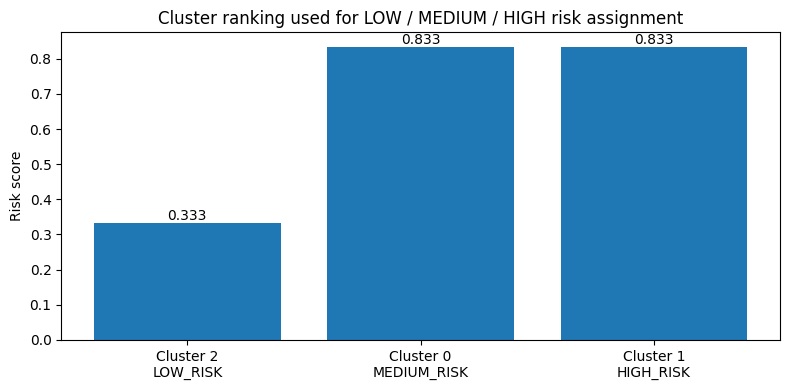

In [223]:
# ---------------------------------------------------------
# 8. Visualize risk ranking
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
bars = plt.bar(
    [f"Cluster {int(c)}\n{m}" for c, m in zip(cluster_summary["cluster"], cluster_summary["operating_mode"])],
    cluster_summary["risk_score"]
)

plt.ylabel("Risk score")
plt.title("Cluster ranking used for LOW / MEDIUM / HIGH risk assignment")

for b, h in zip(bars, cluster_summary["risk_score"]):
    plt.text(b.get_x() + b.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

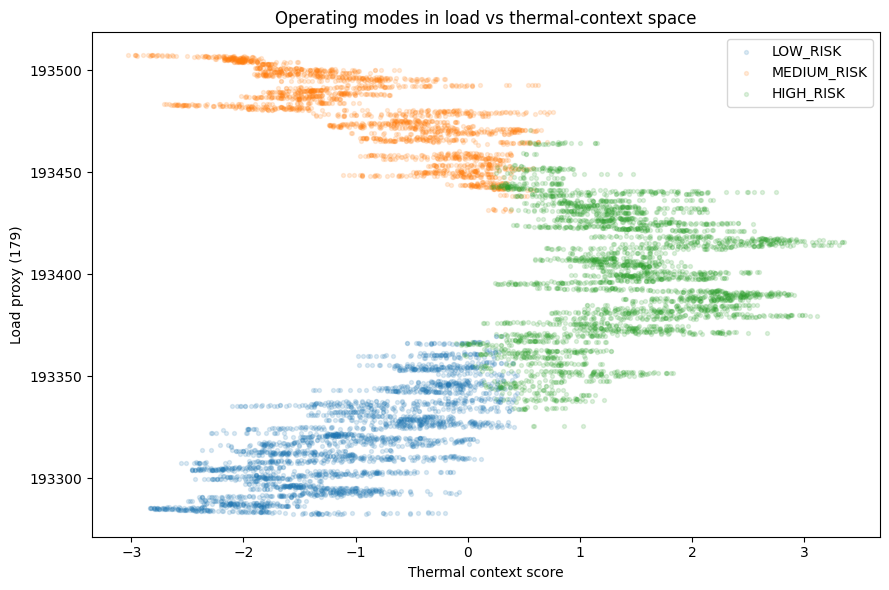

In [224]:
# ---------------------------------------------------------
# 9. Scatterplot in the final clustering space
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))

for mode in cluster_summary["operating_mode"]:
    tmp = control_df_f[control_df_f["operating_mode"] == mode]
    plt.scatter(
        tmp["thermal_context_score"],
        tmp["load_proxy"],
        alpha=0.15,
        s=8,
        label=mode
    )

plt.xlabel("Thermal context score")
plt.ylabel(f"Load proxy ({load_proxy_col})")
plt.title("Operating modes in load vs thermal-context space")
plt.legend()
plt.tight_layout()
plt.show()

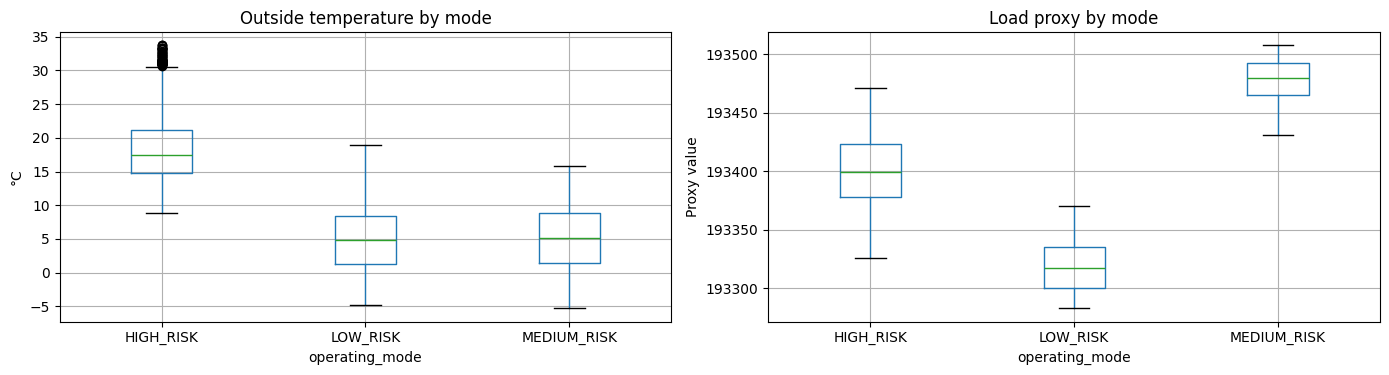

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

control_df_f.boxplot(column="wx_temp_2m", by="operating_mode", ax=axes[0])
axes[0].set_title("Outside temperature by mode")
axes[0].set_ylabel("°C")

control_df_f.boxplot(column="load_proxy", by="operating_mode", ax=axes[1])
axes[1].set_title("Load proxy by mode")
axes[1].set_ylabel("Proxy value")

plt.suptitle("")
plt.tight_layout()
plt.show()

Although signals 80 and 188 showed the strongest raw correlation with actual cooling demand, they proved less suitable for supervisory control design. The proxy is not selected to maximize predictive similarity to the cooling target, but to provide an interpretable and discriminative indicator of operating context. Signals 80 and 188 behaved too closely to direct cooling-state indicators and made the load-aware and mode-aware strategies overly restrictive, leaving little or no bounded intervention potential.

By contrast, signal 179 produced the clearest operating-mode separation in the K-means clustering step and supported a more useful supervisory partition of low-, medium-, and high-risk operating contexts. This made it more suitable as a contextual control variable rather than as a target-adjacent predictor. For that reason, signal 179 was selected as the final operational load proxy for the intelligent supervisory control design, despite its lower simple correlation with actual cooling demand.

### F6. Intelligent supervisory control strategies

Three supervisory strategies are evaluated under the same historical conditions.

**S1: Forecast-only conservative supervisory control**  
This strategy uses forecast deviation and persistence only. It acts as the least constrained intelligent-control baseline.

**S2: Load-aware supervisory control**  
This strategy extends S1 by incorporating the selected operational load proxy and an allowed operating-hour window. It is designed to avoid intervention during more demanding periods.

**S3: Load-and-mode-aware supervisory control**  
This is the primary control strategy of the thesis. It extends S2 by additionally incorporating the data-driven operating-mode labels obtained from K-means clustering. Intervention is blocked or restricted depending on whether the operating context is classified as high-, medium-, or low-risk.

Together, S1-S3 define a progression from simpler to richer supervisory control logic.

In [225]:
# =========================================================
# F6. INTELLIGENT SUPERVISORY CONTROL STRATEGIES
# =========================================================

def strategy_s1(row):
    if not row["warm_season"]:
        return "PROTECT"
    if row["excess_state"] == "NONE":
        return "NORMAL"
    if not row["persistent_excess"]:
        return "NORMAL"
    if row["excess_state"] == "MILD":
        return "RELAXED_1"
    if row["excess_state"] == "STRONG":
        return "RELAXED_2"
    return "NORMAL"

def strategy_s2(row):
    if not row["warm_season"]:
        return "PROTECT"
    if not row["allowed_hour"]:
        return "PROTECT"
    if row["load_state"] == "HIGH":
        return "PROTECT"
    if row["excess_state"] == "NONE":
        return "NORMAL"
    if not row["persistent_excess"]:
        return "NORMAL"
    if row["excess_state"] == "MILD":
        return "RELAXED_1"
    if row["excess_state"] == "STRONG":
        return "RELAXED_2"
    return "NORMAL"

def strategy_s3(row):
    if not row["warm_season"]:
        return "PROTECT"
    if not row["allowed_hour"]:
        return "PROTECT"
    if row["load_state"] == "HIGH":
        return "PROTECT"
    if row["excess_state"] == "NONE":
        return "NORMAL"
    if not row["persistent_excess"]:
        return "NORMAL"

    mode = row["operating_mode"]

    if mode == "HIGH_RISK":
        return "PROTECT"

    if mode == "MEDIUM_RISK":
        if row["excess_state"] in ["MILD", "STRONG"]:
            return "RELAXED_1"
        return "NORMAL"

    if mode == "LOW_RISK":
        if row["excess_state"] == "MILD":
            return "RELAXED_1"
        if row["excess_state"] == "STRONG":
            return "RELAXED_2"

    return "NORMAL"

state_to_pct = {
    "PROTECT": 0.00,
    "NORMAL": 0.00,
    "RELAXED_1": 0.05,
    "RELAXED_2": 0.10
}

strategies = {
    "S1_forecast_only": strategy_s1,
    "S2_load_aware": strategy_s2,
    "S3_load_mode_aware": strategy_s3
}

### F7. Control action simulation and controller performance metrics

Each strategy is simulated on the historical cooling-demand series. When a control state allows intervention, the historical cooling value is reduced by the corresponding bounded action level, capped by the estimated positive excess above expected demand.

In addition to total reduction relative to historical cooling demand, the strategies are compared using controller-oriented metrics:
- active control hours,
- number of mild-control and stronger-control hours,
- mean action intensity,
- fraction of actions by operating mode,
- selectivity, defined as active-control hours relative to eligible hours.

In [226]:
# =========================================================
# F7. CONTROL ACTION SIMULATION AND METRICS
# =========================================================

strategy_results = []
monthly_strategy_results = []
strategy_case_tables = {}
strategy_series = {}

eligible_hours_total = int(
    control_df_f["warm_season"].sum()
)

for strategy_name, strategy_fn in strategies.items():
    tmp = control_df_f.copy()

    tmp["control_state"] = tmp.apply(strategy_fn, axis=1)
    tmp["control_reduction_pct"] = tmp["control_state"].map(state_to_pct)

    tmp["control_reduction_energy"] = np.minimum(
        tmp["actual"] * tmp["control_reduction_pct"],
        tmp["residual_bc"].clip(lower=0)
    )

    tmp["simulated_controlled_cooling"] = (
        tmp["actual"] - tmp["control_reduction_energy"]
    )

    tmp_warm = tmp[tmp["warm_season"]].copy()

    active_mask = tmp_warm["control_reduction_pct"] > 0
    active_hours = int(active_mask.sum())

    mean_action_intensity = tmp_warm.loc[active_mask, "control_reduction_pct"].mean()
    if pd.isna(mean_action_intensity):
        mean_action_intensity = 0.0

    low_risk_frac = (
        (tmp_warm.loc[active_mask, "operating_mode"] == "LOW_RISK").mean()
        if active_hours > 0 else 0.0
    )
    med_risk_frac = (
        (tmp_warm.loc[active_mask, "operating_mode"] == "MEDIUM_RISK").mean()
        if active_hours > 0 else 0.0
    )
    high_risk_frac = (
        (tmp_warm.loc[active_mask, "operating_mode"] == "HIGH_RISK").mean()
        if active_hours > 0 else 0.0
    )

    historical_total = tmp_warm["actual"].sum()
    simulated_total = tmp_warm["simulated_controlled_cooling"].sum()

    strategy_results.append({
        "strategy": strategy_name,
        "historical_actual": historical_total,
        "simulated_controlled_cooling": simulated_total,
        "reduction_vs_historical_pct": (
            (historical_total - simulated_total) / historical_total * 100
        ),
        "active_control_hours": active_hours,
        "relaxed_1_hours": int((tmp_warm["control_state"] == "RELAXED_1").sum()),
        "relaxed_2_hours": int((tmp_warm["control_state"] == "RELAXED_2").sum()),
        "mean_action_intensity_pct": mean_action_intensity * 100,
        "low_risk_action_frac": low_risk_frac,
        "medium_risk_action_frac": med_risk_frac,
        "high_risk_action_frac": high_risk_frac,
        "selectivity_vs_warm_hours": active_hours / eligible_hours_total if eligible_hours_total > 0 else np.nan
    })

    monthly = (
        tmp_warm.groupby(tmp_warm.index.month)
        .agg(
            historical_actual=("actual", "sum"),
            simulated_controlled_cooling=("simulated_controlled_cooling", "sum"),
            active_control_hours=("control_reduction_pct", lambda s: (s > 0).sum())
        )
        .reset_index()
    )
    monthly = monthly.rename(columns={monthly.columns[0]: "month"})
    monthly["reduction_pct"] = (
        (monthly["historical_actual"] - monthly["simulated_controlled_cooling"])
        / monthly["historical_actual"] * 100
    )
    monthly["strategy"] = strategy_name
    monthly_strategy_results.append(monthly)

    strategy_case_tables[strategy_name] = (
        tmp[tmp["control_reduction_pct"] > 0][[
            "actual", "predicted_bias_corrected", "residual_bc",
            "load_proxy", "wx_temp_2m", "wx_dewpoint_2m",
            "operating_mode", "control_state", "control_reduction_energy"
        ]]
        .sort_values("residual_bc", ascending=False)
        .head(10)
    )

    strategy_series[strategy_name] = tmp.copy()

strategy_summary_f = pd.DataFrame(strategy_results)
monthly_strategy_df_f = pd.concat(monthly_strategy_results, ignore_index=True)

strategy_summary_f

,strategy,historical_actual,simulated_controlled_cooling,reduction_vs_historical_pct,active_control_hours,relaxed_1_hours,relaxed_2_hours,mean_action_intensity_pct,low_risk_action_frac,medium_risk_action_frac,high_risk_action_frac,selectivity_vs_warm_hours
0,S1_forecast_only,16461351.0,1.643518e+07,0.158979,106,0,106,10.0,0.188679,0.066038,0.745283,0.029969
1,S2_load_aware,16461351.0,1.645549e+07,0.035591,25,0,25,10.0,0.240000,0.000000,0.760000,0.007068
2,S3_load_mode_aware,16461351.0,1.645966e+07,0.010249,6,0,6,10.0,1.000000,0.000000,0.000000,0.001696


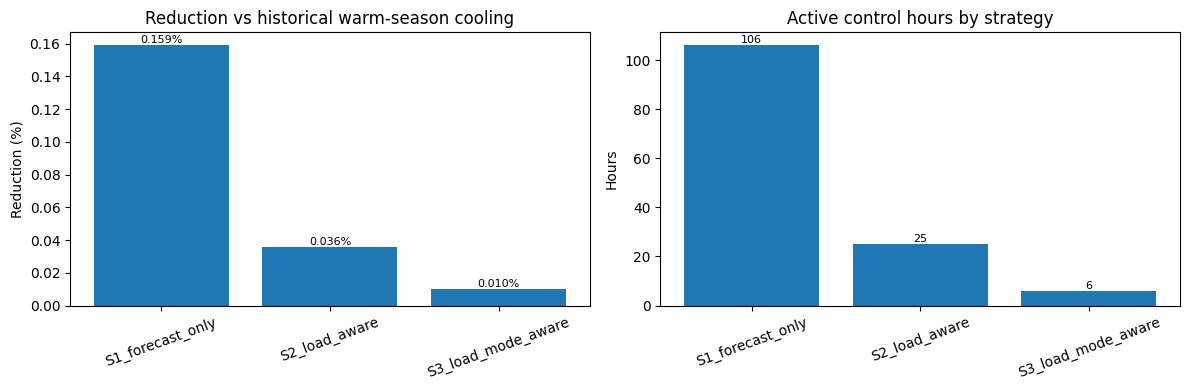

In [227]:
# ---------------------------------------------------------
# Strategy comparison
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars1 = axes[0].bar(strategy_summary_f["strategy"], strategy_summary_f["reduction_vs_historical_pct"])
axes[0].set_title("Reduction vs historical warm-season cooling")
axes[0].set_ylabel("Reduction (%)")
axes[0].tick_params(axis="x", rotation=20)

for b, h in zip(bars1, strategy_summary_f["reduction_vs_historical_pct"]):
    axes[0].text(b.get_x() + b.get_width()/2, h, f"{h:.3f}%", ha="center", va="bottom", fontsize=8)

bars2 = axes[1].bar(strategy_summary_f["strategy"], strategy_summary_f["active_control_hours"])
axes[1].set_title("Active control hours by strategy")
axes[1].set_ylabel("Hours")
axes[1].tick_params(axis="x", rotation=20)

for b, h in zip(bars2, strategy_summary_f["active_control_hours"]):
    axes[1].text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

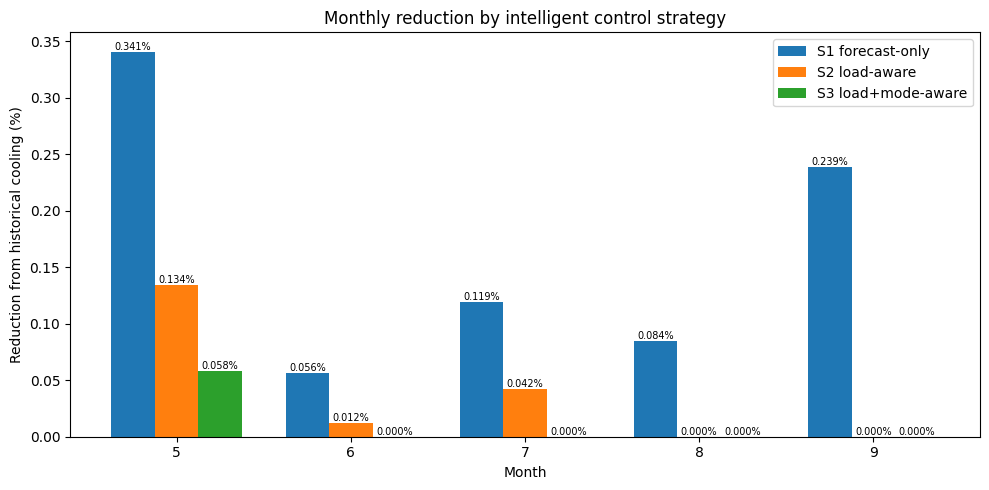

In [228]:
# ---------------------------------------------------------
# Monthly reduction
# ---------------------------------------------------------
months = sorted(monthly_strategy_df_f["month"].unique())
x = np.arange(len(months))
w = 0.25

s1 = monthly_strategy_df_f[monthly_strategy_df_f["strategy"] == "S1_forecast_only"].set_index("month").reindex(months)
s2 = monthly_strategy_df_f[monthly_strategy_df_f["strategy"] == "S2_load_aware"].set_index("month").reindex(months)
s3 = monthly_strategy_df_f[monthly_strategy_df_f["strategy"] == "S3_load_mode_aware"].set_index("month").reindex(months)

plt.figure(figsize=(10, 5))
b1 = plt.bar(x - w, s1["reduction_pct"], width=w, label="S1 forecast-only")
b2 = plt.bar(x,     s2["reduction_pct"], width=w, label="S2 load-aware")
b3 = plt.bar(x + w, s3["reduction_pct"], width=w, label="S3 load+mode-aware")

plt.xticks(x, months)
plt.xlabel("Month")
plt.ylabel("Reduction from historical cooling (%)")
plt.title("Monthly reduction by intelligent control strategy")
plt.legend()

for bars in [b1, b2, b3]:
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h, f"{h:.3f}%", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

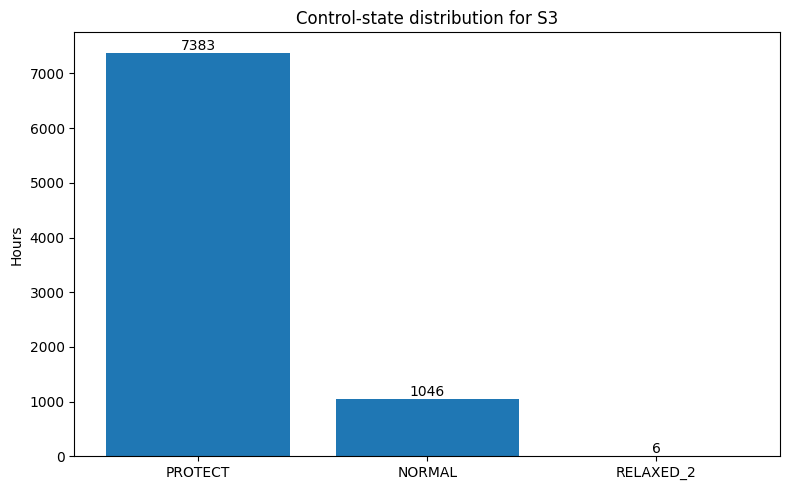

In [229]:
# ---------------------------------------------------------
# S3 control-state distribution
# ---------------------------------------------------------
s3_states = (
    strategy_series["S3_load_mode_aware"]["control_state"]
    .value_counts()
    .rename_axis("control_state")
    .reset_index(name="hours")
)

plt.figure(figsize=(8, 5))
bars = plt.bar(s3_states["control_state"], s3_states["hours"])
plt.ylabel("Hours")
plt.title("Control-state distribution for S3")

for b, h in zip(bars, s3_states["hours"]):
    plt.text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### F8. Example control opportunities and final interpretation

Representative S3 control-active periods are inspected directly by comparing historical actual cooling, expected cooling, and simulated controlled cooling. These examples are not used to claim actuator-level feasibility, but to illustrate when and how the supervisory controller would intervene under the imposed constraints.

The final control comparison is interpreted in terms of selectivity as well as reduction. If the strongest strategy acts only rarely and produces only a very small bounded effect, this is not evidence of methodological failure. Rather, it indicates that the site offers only a narrow forecast-informed intervention margin once realistic supervisory constraints are respected.

In [230]:
# =========================================================
# F8. EXAMPLE CONTROL OPPORTUNITIES
# =========================================================

print("Top cases for S3_load_mode_aware")
display(strategy_case_tables["S3_load_mode_aware"].head(5))

Top cases for S3_load_mode_aware


,actual,predicted_bias_corrected,residual_bc,load_proxy,wx_temp_2m,wx_dewpoint_2m,operating_mode,control_state,control_reduction_energy
ts_hour,,,,,,,,,
2025-05-08 16:00:00,4967.0,4527.137570,439.862430,193354.468750,13.5,4.7,LOW_RISK,RELAXED_2,439.862430
2025-05-16 15:00:00,5282.0,4863.032964,418.967036,193360.453125,16.1,0.3,LOW_RISK,RELAXED_2,418.967036
2025-05-16 17:00:00,5260.0,5026.431324,233.568676,193360.453125,16.5,-0.4,LOW_RISK,RELAXED_2,233.568676
2025-05-08 17:00:00,5036.0,4814.242630,221.757370,193354.468750,13.4,4.9,LOW_RISK,RELAXED_2,221.757370
2025-05-10 11:00:00,3400.0,3195.962500,204.037500,193355.468750,12.5,7.2,LOW_RISK,RELAXED_2,204.037500


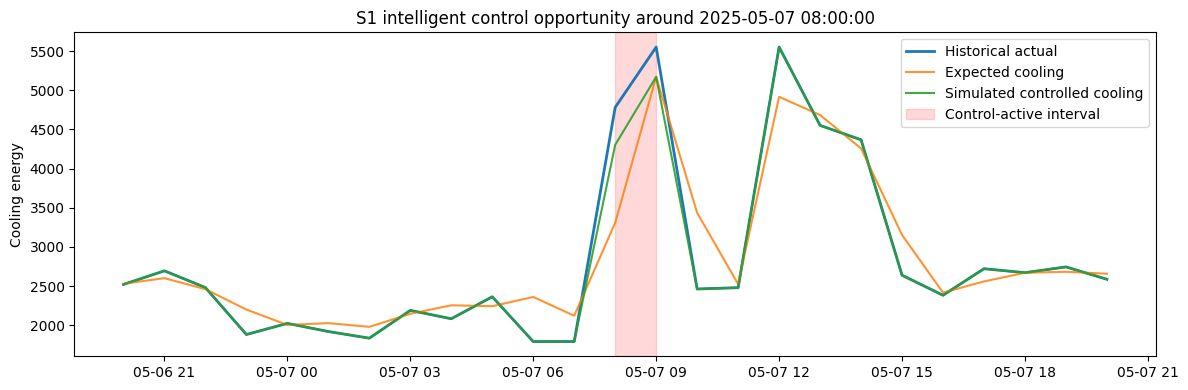

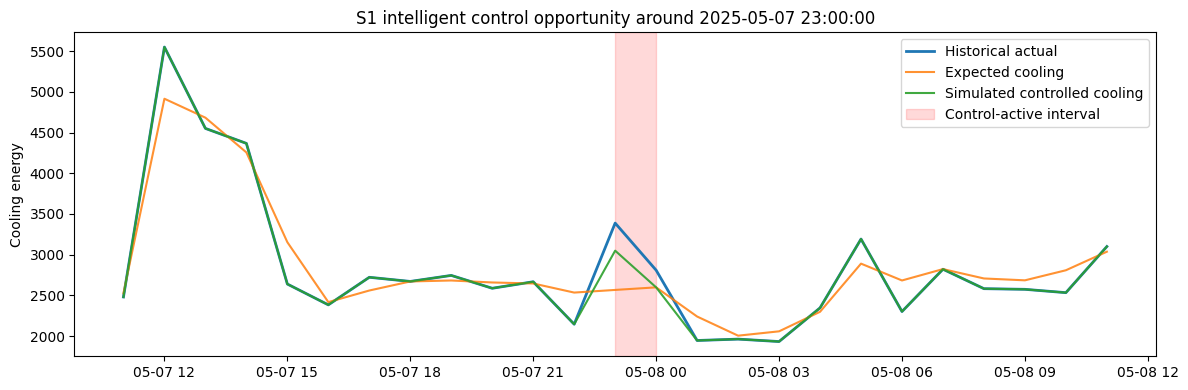

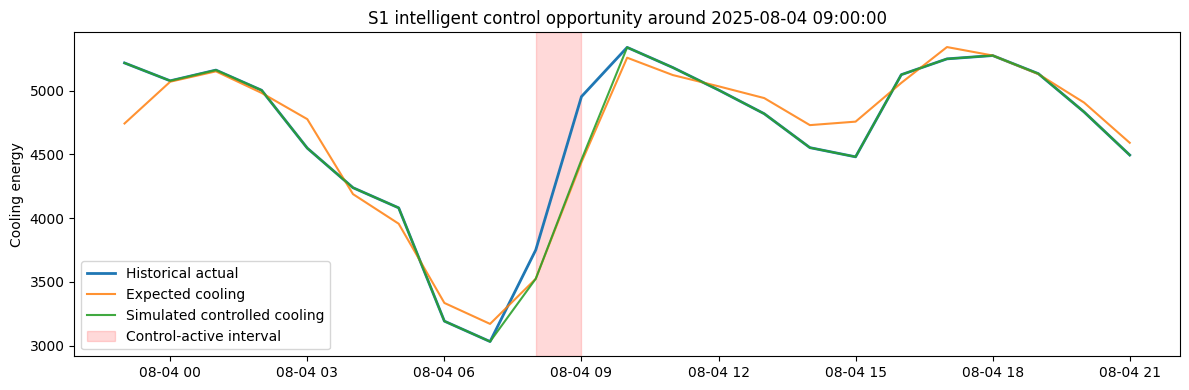

In [231]:
top_cases_s3 = strategy_case_tables["S1_forecast_only"].head(3)

for example_case in top_cases_s3.index:
    case_df = strategy_series["S1_forecast_only"].loc[
        example_case - pd.Timedelta(hours=12): example_case + pd.Timedelta(hours=12)
    ].copy()

    active_window = case_df[case_df["control_reduction_pct"] > 0]

    plt.figure(figsize=(12, 4))
    plt.plot(case_df.index, case_df["actual"], label="Historical actual", linewidth=2)
    plt.plot(case_df.index, case_df["predicted_bias_corrected"], label="Expected cooling", alpha=0.85)
    plt.plot(case_df.index, case_df["simulated_controlled_cooling"], label="Simulated controlled cooling", alpha=0.9)

    if not active_window.empty:
        start_ts = active_window.index.min()
        end_ts = active_window.index.max()
        plt.axvspan(start_ts, end_ts, color="red", alpha=0.15, label="Control-active interval")

    plt.title(f"S1 intelligent control opportunity around {example_case}")
    plt.ylabel("Cooling energy")
    plt.legend()
    plt.tight_layout()
    plt.show()

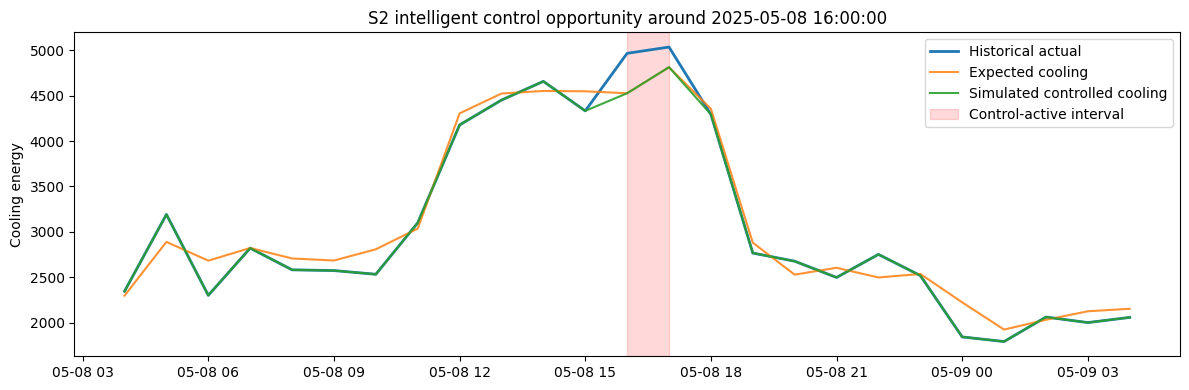

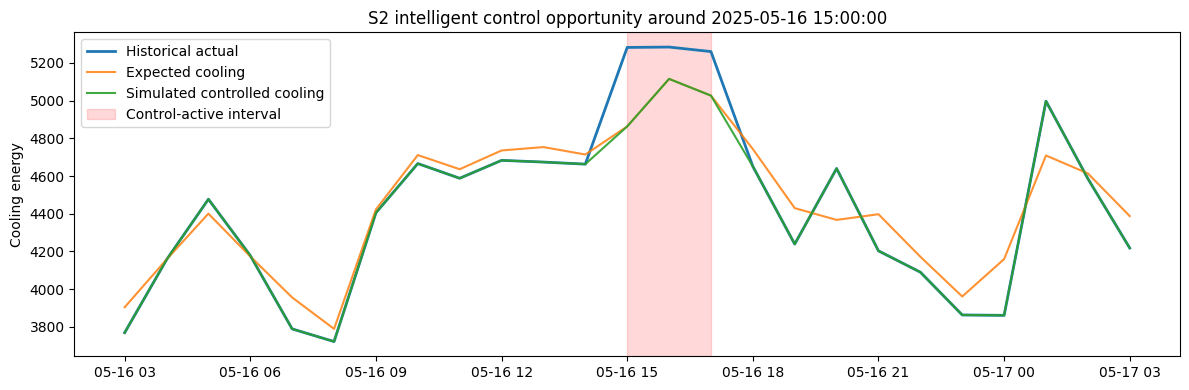

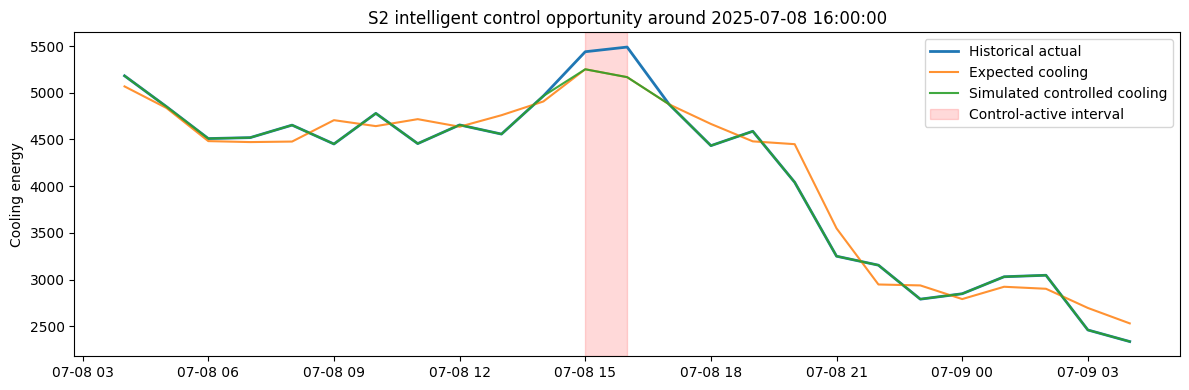

In [232]:
top_cases_s3 = strategy_case_tables["S2_load_aware"].head(3)

for example_case in top_cases_s3.index:
    case_df = strategy_series["S2_load_aware"].loc[
        example_case - pd.Timedelta(hours=12): example_case + pd.Timedelta(hours=12)
    ].copy()

    active_window = case_df[case_df["control_reduction_pct"] > 0]

    plt.figure(figsize=(12, 4))
    plt.plot(case_df.index, case_df["actual"], label="Historical actual", linewidth=2)
    plt.plot(case_df.index, case_df["predicted_bias_corrected"], label="Expected cooling", alpha=0.85)
    plt.plot(case_df.index, case_df["simulated_controlled_cooling"], label="Simulated controlled cooling", alpha=0.9)

    if not active_window.empty:
        start_ts = active_window.index.min()
        end_ts = active_window.index.max()
        plt.axvspan(start_ts, end_ts, color="red", alpha=0.15, label="Control-active interval")

    plt.title(f"S2 intelligent control opportunity around {example_case}")
    plt.ylabel("Cooling energy")
    plt.legend()
    plt.tight_layout()
    plt.show()

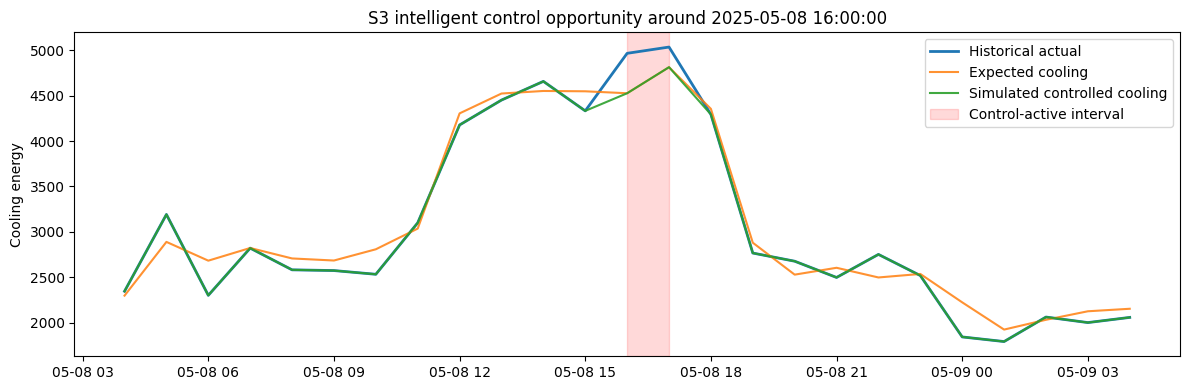

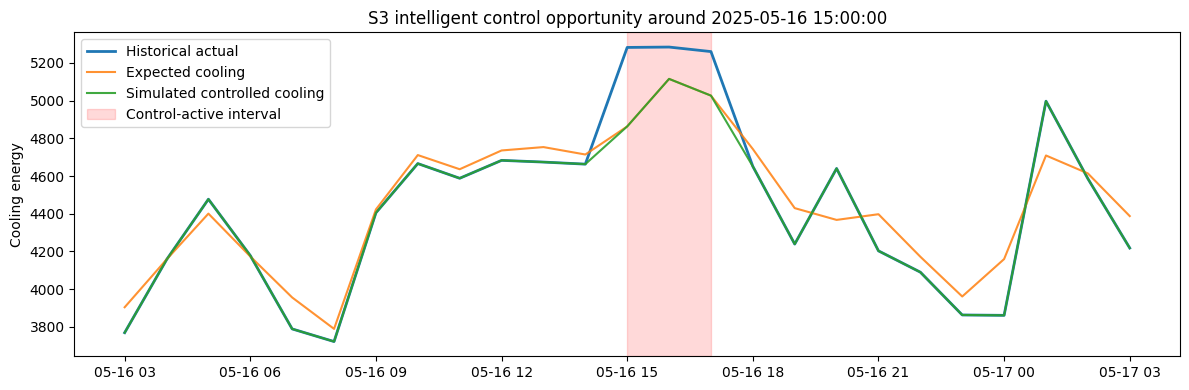

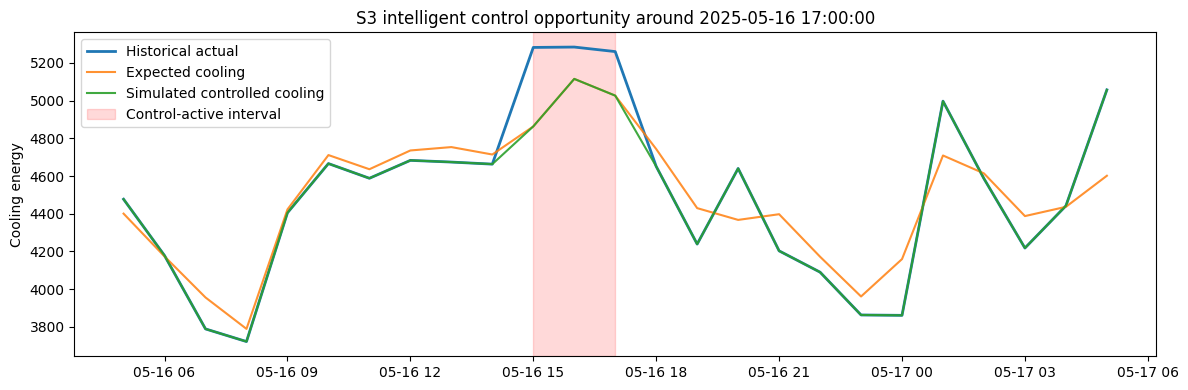

In [233]:
top_cases_s3 = strategy_case_tables["S3_load_mode_aware"].head(3)

for example_case in top_cases_s3.index:
    case_df = strategy_series["S3_load_mode_aware"].loc[
        example_case - pd.Timedelta(hours=12): example_case + pd.Timedelta(hours=12)
    ].copy()

    active_window = case_df[case_df["control_reduction_pct"] > 0]

    plt.figure(figsize=(12, 4))
    plt.plot(case_df.index, case_df["actual"], label="Historical actual", linewidth=2)
    plt.plot(case_df.index, case_df["predicted_bias_corrected"], label="Expected cooling", alpha=0.85)
    plt.plot(case_df.index, case_df["simulated_controlled_cooling"], label="Simulated controlled cooling", alpha=0.9)

    if not active_window.empty:
        start_ts = active_window.index.min()
        end_ts = active_window.index.max()
        plt.axvspan(start_ts, end_ts, color="red", alpha=0.15, label="Control-active interval")

    plt.title(f"S3 intelligent control opportunity around {example_case}")
    plt.ylabel("Cooling energy")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Validation package for intelligent-control section

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [234]:
# =========================================================
# V1. BASELINE VS S1/S2/S3
# =========================================================

# simple threshold baseline:
# - warm season only
# - residual threshold only
# - no persistence
# - no load / mode context
# - one bounded action level

baseline_threshold = control_df_f.loc[
    control_df_f["residual_bc"] > 0, "residual_bc"
].quantile(0.75)

def strategy_baseline_simple(row):
    if not row["warm_season"]:
        return "PROTECT"
    if row["residual_bc"] <= 0:
        return "NORMAL"
    if row["residual_bc"] < baseline_threshold:
        return "NORMAL"
    return "RELAXED_1"

strategies_validation = {
    "B0_simple_threshold": strategy_baseline_simple,
    "S1_forecast_only": strategy_s1,
    "S2_load_aware": strategy_s2,
    "S3_load_mode_aware": strategy_s3
}

In [235]:
# =========================================================
# Unified simulation function
# =========================================================

def simulate_strategy_family(df: pd.DataFrame, strategies_dict: dict):
    results = []
    monthly_results = []
    series_store = {}

    eligible_hours_total = int(df["warm_season"].sum())

    for strategy_name, strategy_fn in strategies_dict.items():
        tmp = df.copy()

        tmp["control_state"] = tmp.apply(strategy_fn, axis=1)
        tmp["control_reduction_pct"] = tmp["control_state"].map(state_to_pct)

        tmp["control_reduction_energy"] = np.minimum(
            tmp["actual"] * tmp["control_reduction_pct"],
            tmp["residual_bc"].clip(lower=0)
        )

        tmp["simulated_controlled_cooling"] = (
            tmp["actual"] - tmp["control_reduction_energy"]
        )

        tmp_warm = tmp[tmp["warm_season"]].copy()
        active_mask = tmp_warm["control_reduction_pct"] > 0
        active_hours = int(active_mask.sum())

        mean_action_intensity = tmp_warm.loc[active_mask, "control_reduction_pct"].mean()
        if pd.isna(mean_action_intensity):
            mean_action_intensity = 0.0

        low_risk_frac = (
            (tmp_warm.loc[active_mask, "operating_mode"] == "LOW_RISK").mean()
            if active_hours > 0 else 0.0
        )
        med_risk_frac = (
            (tmp_warm.loc[active_mask, "operating_mode"] == "MEDIUM_RISK").mean()
            if active_hours > 0 else 0.0
        )
        high_risk_frac = (
            (tmp_warm.loc[active_mask, "operating_mode"] == "HIGH_RISK").mean()
            if active_hours > 0 else 0.0
        )

        protected_hours = int((tmp_warm["control_state"] == "PROTECT").sum())
        avoided_high_risk_hours = int(
            ((tmp_warm["operating_mode"] == "HIGH_RISK") & (tmp_warm["control_state"] == "PROTECT")).sum()
        )

        historical_total = tmp_warm["actual"].sum()
        simulated_total = tmp_warm["simulated_controlled_cooling"].sum()

        results.append({
            "strategy": strategy_name,
            "historical_actual": historical_total,
            "simulated_controlled_cooling": simulated_total,
            "reduction_vs_historical_pct": (
                (historical_total - simulated_total) / historical_total * 100
            ),
            "active_control_hours": active_hours,
            "relaxed_1_hours": int((tmp_warm["control_state"] == "RELAXED_1").sum()),
            "relaxed_2_hours": int((tmp_warm["control_state"] == "RELAXED_2").sum()),
            "mean_action_intensity_pct": mean_action_intensity * 100,
            "low_risk_action_frac": low_risk_frac,
            "medium_risk_action_frac": med_risk_frac,
            "high_risk_action_frac": high_risk_frac,
            "protected_hours": protected_hours,
            "avoided_high_risk_hours": avoided_high_risk_hours,
            "selectivity_vs_warm_hours": active_hours / eligible_hours_total if eligible_hours_total > 0 else np.nan
        })

        monthly = (
            tmp_warm.groupby(tmp_warm.index.month)
            .agg(
                historical_actual=("actual", "sum"),
                simulated_controlled_cooling=("simulated_controlled_cooling", "sum"),
                active_control_hours=("control_reduction_pct", lambda s: (s > 0).sum())
            )
            .reset_index()
        )
        monthly = monthly.rename(columns={monthly.columns[0]: "month"})
        monthly["reduction_pct"] = (
            (monthly["historical_actual"] - monthly["simulated_controlled_cooling"])
            / monthly["historical_actual"] * 100
        )
        monthly["strategy"] = strategy_name
        monthly_results.append(monthly)

        series_store[strategy_name] = tmp.copy()

    return (
        pd.DataFrame(results),
        pd.concat(monthly_results, ignore_index=True),
        series_store
    )

strategy_summary_val, monthly_val, series_val = simulate_strategy_family(
    control_df_f,
    strategies_validation
)

display(strategy_summary_val)

,strategy,historical_actual,simulated_controlled_cooling,reduction_vs_historical_pct,active_control_hours,relaxed_1_hours,relaxed_2_hours,mean_action_intensity_pct,low_risk_action_frac,medium_risk_action_frac,high_risk_action_frac,protected_hours,avoided_high_risk_hours,selectivity_vs_warm_hours
0,B0_simple_threshold,16461351.0,1.635744e+07,0.631270,497,497,0,5.0,0.098592,0.044266,0.857143,0,0,0.140515
1,S1_forecast_only,16461351.0,1.643518e+07,0.158979,106,0,106,10.0,0.188679,0.066038,0.745283,0,0,0.029969
2,S2_load_aware,16461351.0,1.645549e+07,0.035591,25,0,25,10.0,0.240000,0.000000,0.760000,2466,2127,0.007068
3,S3_load_mode_aware,16461351.0,1.645966e+07,0.010249,6,0,6,10.0,1.000000,0.000000,0.000000,2485,2146,0.001696


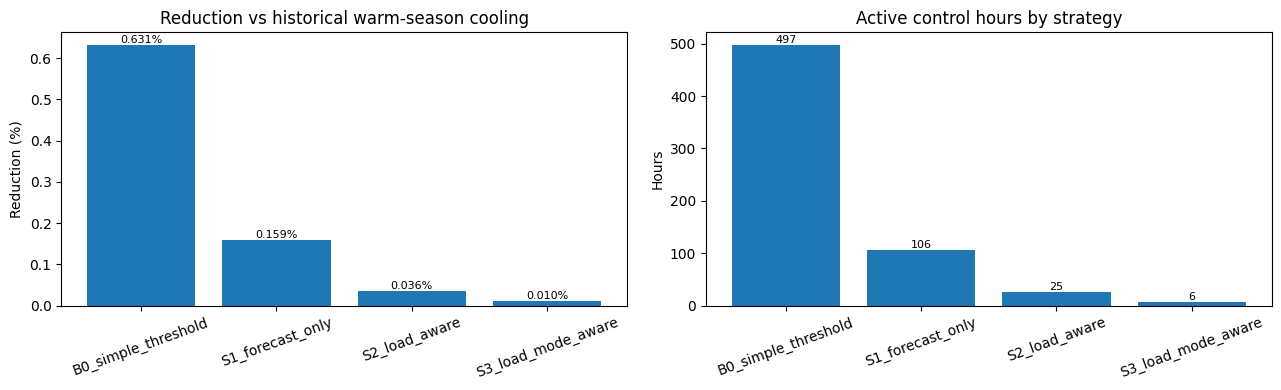

In [ ]:
# Main bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars1 = axes[0].bar(strategy_summary_val["strategy"], strategy_summary_val["reduction_vs_historical_pct"])
axes[0].set_title("Reduction vs historical warm-season cooling")
axes[0].set_ylabel("Reduction (%)")
axes[0].tick_params(axis="x", rotation=20)

for b, h in zip(bars1, strategy_summary_val["reduction_vs_historical_pct"]):
    axes[0].text(b.get_x() + b.get_width()/2, h, f"{h:.3f}%", ha="center", va="bottom", fontsize=8)

bars2 = axes[1].bar(strategy_summary_val["strategy"], strategy_summary_val["active_control_hours"])
axes[1].set_title("Active control hours by strategy")
axes[1].set_ylabel("Hours")
axes[1].tick_params(axis="x", rotation=20)

for b, h in zip(bars2, strategy_summary_val["active_control_hours"]):
    axes[1].text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [237]:
# =========================================================
# V2. CONTROLLER METRICS TABLE
# =========================================================

validation_table = strategy_summary_val[[
    "strategy",
    "active_control_hours",
    "relaxed_1_hours",
    "relaxed_2_hours",
    "mean_action_intensity_pct",
    "low_risk_action_frac",
    "medium_risk_action_frac",
    "high_risk_action_frac",
    "avoided_high_risk_hours",
    "selectivity_vs_warm_hours",
    "reduction_vs_historical_pct"
]].copy()

display(validation_table)

,strategy,active_control_hours,relaxed_1_hours,relaxed_2_hours,mean_action_intensity_pct,low_risk_action_frac,medium_risk_action_frac,high_risk_action_frac,avoided_high_risk_hours,selectivity_vs_warm_hours,reduction_vs_historical_pct
0,B0_simple_threshold,497,497,0,5.0,0.098592,0.044266,0.857143,0,0.140515,0.631270
1,S1_forecast_only,106,0,106,10.0,0.188679,0.066038,0.745283,0,0.029969,0.158979
2,S2_load_aware,25,0,25,10.0,0.240000,0.000000,0.760000,2127,0.007068,0.035591
3,S3_load_mode_aware,6,0,6,10.0,1.000000,0.000000,0.000000,2146,0.001696,0.010249


In [238]:
# =========================================================
# THRESHOLD / PERSISTENCE / CAP SENSITIVITY
# =========================================================

def build_control_df_variant(
    base_df: pd.DataFrame,
    residual_quantile: float = 0.75,
    persistence_hours: int = 2
):
    out = base_df.copy()

    positive_residuals = out.loc[out["residual_bc"] > 0, "residual_bc"]
    strong_excess_threshold = positive_residuals.quantile(residual_quantile)

    def excess_state(x):
        if x <= 0:
            return "NONE"
        elif x < strong_excess_threshold:
            return "MILD"
        else:
            return "STRONG"

    out["excess_state"] = out["residual_bc"].apply(excess_state)

    out["meaningful_excess_flag"] = out["residual_bc"] >= strong_excess_threshold
    out["meaningful_excess_int"] = out["meaningful_excess_flag"].astype(int)

    group_id = (out["meaningful_excess_int"].diff().fillna(0) != 0).cumsum()
    run_lengths = out.groupby(group_id)["meaningful_excess_int"].transform("sum")

    out["persistent_excess"] = (
        out["meaningful_excess_flag"] & (run_lengths >= persistence_hours)
    )

    return out


def simulate_strategy_family_with_caps(df: pd.DataFrame, strategies_dict: dict, cap_map: dict):
    results = []

    eligible_hours_total = int(df["warm_season"].sum())

    for strategy_name, strategy_fn in strategies_dict.items():
        tmp = df.copy()

        tmp["control_state"] = tmp.apply(strategy_fn, axis=1)
        tmp["control_reduction_pct"] = tmp["control_state"].map(cap_map)

        tmp["control_reduction_energy"] = np.minimum(
            tmp["actual"] * tmp["control_reduction_pct"],
            tmp["residual_bc"].clip(lower=0)
        )

        tmp["simulated_controlled_cooling"] = (
            tmp["actual"] - tmp["control_reduction_energy"]
        )

        tmp_warm = tmp[tmp["warm_season"]].copy()
        active_mask = tmp_warm["control_reduction_pct"] > 0
        active_hours = int(active_mask.sum())

        historical_total = tmp_warm["actual"].sum()
        simulated_total = tmp_warm["simulated_controlled_cooling"].sum()

        results.append({
            "strategy": strategy_name,
            "active_control_hours": active_hours,
            "reduction_vs_historical_pct": (
                (historical_total - simulated_total) / historical_total * 100
            ),
            "selectivity_vs_warm_hours": active_hours / eligible_hours_total if eligible_hours_total > 0 else np.nan
        })

    return pd.DataFrame(results)


sensitivity_rows = []

residual_quantiles = [0.50, 0.75, 0.90]
persistence_values = [1, 2, 3]
cap_values = [0.05, 0.10]

for rq in residual_quantiles:
    for p in persistence_values:
        for cap in cap_values:
            tmp_df = build_control_df_variant(control_df_f.copy(), residual_quantile=rq, persistence_hours=p)

            cap_map_variant = {
                "PROTECT": 0.00,
                "NORMAL": 0.00,
                "RELAXED_1": cap,
                "RELAXED_2": min(2 * cap, 0.20)
            }

            tmp_summary = simulate_strategy_family_with_caps(
                tmp_df,
                strategies_validation,
                cap_map_variant
            )

            row = {
                "residual_quantile": rq,
                "persistence_hours": p,
                "action_cap": cap
            }

            for _, r in tmp_summary.iterrows():
                row[f"{r['strategy']}_hours"] = r["active_control_hours"]
                row[f"{r['strategy']}_reduction_pct"] = r["reduction_vs_historical_pct"]

            sensitivity_rows.append(row)

controller_sensitivity = pd.DataFrame(sensitivity_rows)
display(controller_sensitivity)

,residual_quantile,persistence_hours,action_cap,B0_simple_threshold_hours,B0_simple_threshold_reduction_pct,S1_forecast_only_hours,S1_forecast_only_reduction_pct,S2_load_aware_hours,S2_load_aware_reduction_pct,S3_load_mode_aware_hours,S3_load_mode_aware_reduction_pct
0,0.50,1,0.05,497,0.631270,985,1.098385,288,0.301273,16,0.025262
1,0.50,1,0.10,497,0.755367,985,1.126715,288,0.306526,16,0.030515
2,0.50,2,0.05,497,0.631270,407,0.440357,122,0.122034,10,0.015223
3,0.50,2,0.10,497,0.755367,407,0.451542,122,0.124860,10,0.018049
4,0.50,3,0.05,497,0.631270,137,0.140206,47,0.045359,3,0.004990
5,0.50,3,0.10,497,0.755367,137,0.140206,47,0.045359,3,0.004990
6,0.75,1,0.05,497,0.631270,497,0.755367,125,0.187562,10,0.021212
7,0.75,1,0.10,497,0.755367,497,0.783697,125,0.192815,10,0.026465
8,0.75,2,0.05,497,0.631270,106,0.158979,25,0.035591,6,0.010249
9,0.75,2,0.10,497,0.755367,106,0.164062,25,0.035591,6,0.010249


In [239]:
s3_sensitivity = controller_sensitivity[[
    "residual_quantile",
    "persistence_hours",
    "action_cap",
    "S3_load_mode_aware_hours",
    "S3_load_mode_aware_reduction_pct"
]].copy()

display(s3_sensitivity)

,residual_quantile,persistence_hours,action_cap,S3_load_mode_aware_hours,S3_load_mode_aware_reduction_pct
0,0.50,1,0.05,16,0.025262
1,0.50,1,0.10,16,0.030515
2,0.50,2,0.05,10,0.015223
3,0.50,2,0.10,10,0.018049
4,0.50,3,0.05,3,0.004990
5,0.50,3,0.10,3,0.004990
6,0.75,1,0.05,10,0.021212
7,0.75,1,0.10,10,0.026465
8,0.75,2,0.05,6,0.010249
9,0.75,2,0.10,6,0.010249


The additional validation confirms that the intelligent-control hierarchy behaves systematically under shared historical conditions. The simpler threshold-based controller identifies the largest intervention set, while progressively richer supervisory strategies become more selective and produce smaller bounded reductions. Proxy sensitivity, cluster-number sensitivity, and supervisory-parameter sensitivity all indicate that the final conclusion is stable: the site contains a small number of lower-risk intervention opportunities, but no evidence of broad reducible cooling demand under conservative supervisory control logic.

### Bidirectional benchmark interpretation

In addition to identifying forecast-relative excess cooling demand, the same benchmark structure can be used diagnostically to identify periods in which actual cooling falls below model-expected demand under demanding contextual conditions. These periods are not interpreted as direct increase commands, but as candidate insufficient-cooling windows requiring operational attention.

In [244]:
# ---------------------------------------------------------
# 1. Define negative residual thresholds
# ---------------------------------------------------------
negative_residuals = control_df_f.loc[control_df_f["residual_bc"] < 0, "residual_bc"]

mild_under_threshold = negative_residuals.quantile(0.50)   # more negative than this = stronger under-expected
strong_under_threshold = negative_residuals.quantile(0.25) # even more negative

print("mild_under_threshold:", mild_under_threshold)
print("strong_under_threshold:", strong_under_threshold)

mild_under_threshold: -87.75330730374435
strong_under_threshold: -152.1694276356052


In [245]:
# ---------------------------------------------------------
# 2. Classify under-expected state
# ---------------------------------------------------------
def under_state(x):
    if x >= 0:
        return "NONE"
    elif x > mild_under_threshold:
        return "MILD_UNDER"
    elif x > strong_under_threshold:
        return "MODERATE_UNDER"
    else:
        return "STRONG_UNDER"

control_df_f["under_state"] = control_df_f["residual_bc"].apply(under_state)

display(control_df_f["under_state"].value_counts())

under_state
NONE              4130
MILD_UNDER        2152
STRONG_UNDER      1077
MODERATE_UNDER    1076
Name: count, dtype: int64

In [246]:
# ---------------------------------------------------------
# 3. Under-expected persistence
# ---------------------------------------------------------
control_df_f["meaningful_under_flag"] = control_df_f["residual_bc"] <= mild_under_threshold
control_df_f["meaningful_under_int"] = control_df_f["meaningful_under_flag"].astype(int)

group_id_under = (control_df_f["meaningful_under_int"].diff().fillna(0) != 0).cumsum()
run_lengths_under = control_df_f.groupby(group_id_under)["meaningful_under_int"].transform("sum")

control_df_f["persistent_under"] = (
    control_df_f["meaningful_under_flag"] & (run_lengths_under >= 2)
)

print("persistent_under_hours:", int(control_df_f["persistent_under"].sum()))

persistent_under_hours: 848


In [247]:
# ---------------------------------------------------------
# 4. Candidate insufficient-cooling logic
# ---------------------------------------------------------
# Conservative diagnostic flag:
# - warm season
# - allowed hour
# - persistent under-expected cooling
# - high load
# - high thermal state
# - optionally high-risk mode

control_df_f["candidate_insufficient_cooling"] = (
    control_df_f["warm_season"] &
    control_df_f["allowed_hour"] &
    control_df_f["persistent_under"] &
    (control_df_f["load_state"] == "HIGH") &
    (control_df_f["thermal_state"] == "HIGH") &
    (control_df_f["operating_mode"].isin(["HIGH_RISK"]))
)

print("candidate_insufficient_cooling_hours:",
      int(control_df_f["candidate_insufficient_cooling"].sum()))

candidate_insufficient_cooling_hours: 18


In [248]:
# ---------------------------------------------------------
# 5. Summary statistics
# ---------------------------------------------------------
insufficient_summary = {
    "negative_residual_hours": int((control_df_f["residual_bc"] < 0).sum()),
    "meaningful_under_hours": int(control_df_f["meaningful_under_flag"].sum()),
    "persistent_under_hours": int(control_df_f["persistent_under"].sum()),
    "candidate_insufficient_cooling_hours": int(control_df_f["candidate_insufficient_cooling"].sum())
}

insufficient_summary

{'negative_residual_hours': 4305,
 'meaningful_under_hours': 2153,
 'persistent_under_hours': 848,
 'candidate_insufficient_cooling_hours': 18}

In [249]:
# =========================================================
# FORECASTING ACCURACY / PERFORMANCE SUMMARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# Inputs expected:
# control_df with columns:
#   actual
#   predicted_bias_corrected
# optional:
#   naive_pred   (if you want improvement vs naive)
# ---------------------------------------------------------

forecast_eval_df = control_df[["actual", "predicted_bias_corrected"]].dropna().copy()

y_true = forecast_eval_df["actual"].values
y_pred = forecast_eval_df["predicted_bias_corrected"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mean_y = np.mean(y_true)
cvrmse_pct = (rmse / mean_y) * 100
nmae_pct = (mae / mean_y) * 100
r2 = r2_score(y_true, y_pred)

forecast_metrics = pd.DataFrame([{
    "metric": "MAE",
    "value": mae
}, {
    "metric": "RMSE",
    "value": rmse
}, {
    "metric": "Mean actual",
    "value": mean_y
}, {
    "metric": "CVRMSE (%)",
    "value": cvrmse_pct
}, {
    "metric": "NMAE (%)",
    "value": nmae_pct
}, {
    "metric": "R2",
    "value": r2
}])

display(forecast_metrics)

,metric,value
0,MAE,115.062724
1,RMSE,161.786664
2,Mean actual,3377.843983
3,CVRMSE (%),4.789643
4,NMAE (%),3.406395
5,R2,0.985501


In [251]:
if "naive_pred" in control_df.columns:
    naive_eval_df = control_df[["actual", "naive_pred"]].dropna().copy()

    y_true_n = naive_eval_df["actual"].values
    y_naive = naive_eval_df["naive_pred"].values

    rmse_naive = np.sqrt(mean_squared_error(y_true_n, y_naive))
    mae_naive = mean_absolute_error(y_true_n, y_naive)

    rmse_improvement_pct = ((rmse_naive - rmse) / rmse_naive) * 100
    mae_improvement_pct = ((mae_naive - mae) / mae_naive) * 100

    forecast_improvement = pd.DataFrame([{
        "metric": "RMSE improvement vs naive (%)",
        "value": rmse_improvement_pct
    }, {
        "metric": "MAE improvement vs naive (%)",
        "value": mae_improvement_pct
    }])

    display(forecast_improvement)

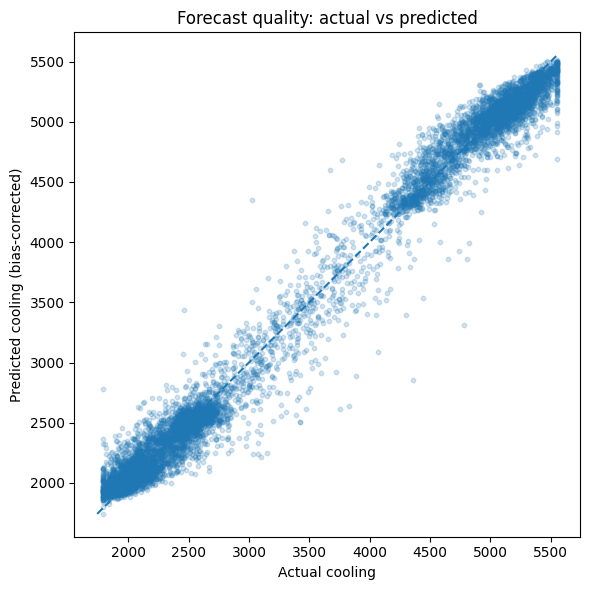

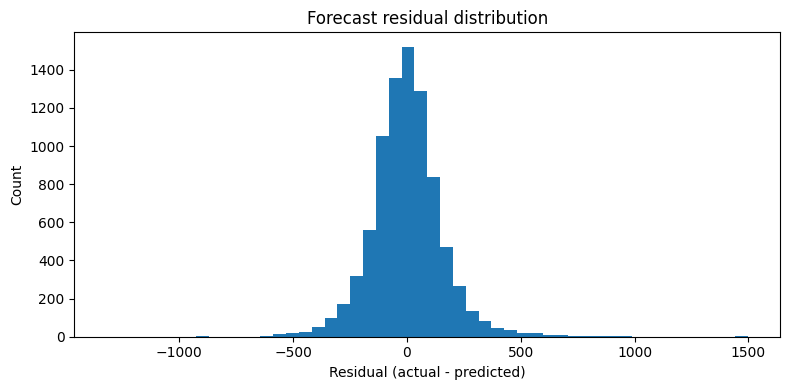

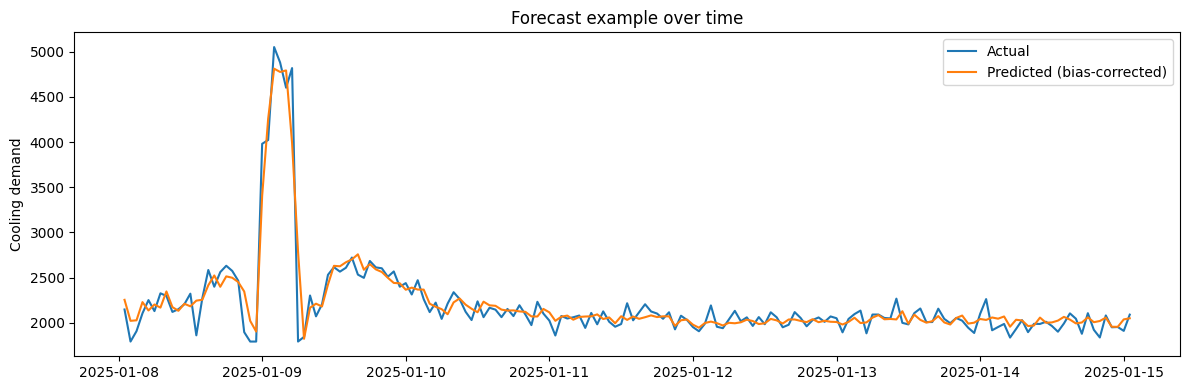

In [252]:
# =========================================================
# FORECAST VISUALIZATION
# =========================================================

# A. Actual vs predicted scatter
plt.figure(figsize=(6, 6))
plt.scatter(forecast_eval_df["actual"], forecast_eval_df["predicted_bias_corrected"], alpha=0.2, s=10)

lims = [
    min(forecast_eval_df["actual"].min(), forecast_eval_df["predicted_bias_corrected"].min()),
    max(forecast_eval_df["actual"].max(), forecast_eval_df["predicted_bias_corrected"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual cooling")
plt.ylabel("Predicted cooling (bias-corrected)")
plt.title("Forecast quality: actual vs predicted")
plt.tight_layout()
plt.show()

# B. Residual distribution
forecast_eval_df["residual_bc"] = forecast_eval_df["actual"] - forecast_eval_df["predicted_bias_corrected"]

plt.figure(figsize=(8, 4))
plt.hist(forecast_eval_df["residual_bc"], bins=50)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.title("Forecast residual distribution")
plt.tight_layout()
plt.show()

# C. Short-window time series example
plot_start = forecast_eval_df.index.min()
plot_end = plot_start + pd.Timedelta(days=7)
plot_df = forecast_eval_df.loc[plot_start:plot_end].copy()

plt.figure(figsize=(12, 4))
plt.plot(plot_df.index, plot_df["actual"], label="Actual")
plt.plot(plot_df.index, plot_df["predicted_bias_corrected"], label="Predicted (bias-corrected)")
plt.title("Forecast example over time")
plt.ylabel("Cooling demand")
plt.legend()
plt.tight_layout()
plt.show()

In [253]:
# =========================================================
# CONTROL PERFORMANCE SUMMARY
# =========================================================

# expected columns in validation_table:
# strategy
# active_control_hours
# relaxed_1_hours
# relaxed_2_hours
# mean_action_intensity_pct
# low_risk_action_frac
# medium_risk_action_frac
# high_risk_action_frac
# avoided_high_risk_hours
# selectivity_vs_warm_hours
# reduction_vs_historical_pct

control_perf = validation_table.copy()

# add % formatting helpers if desired
control_perf["selectivity_pct"] = control_perf["selectivity_vs_warm_hours"] * 100
control_perf["low_risk_action_pct"] = control_perf["low_risk_action_frac"] * 100
control_perf["medium_risk_action_pct"] = control_perf["medium_risk_action_frac"] * 100
control_perf["high_risk_action_pct"] = control_perf["high_risk_action_frac"] * 100

display(control_perf)

,strategy,active_control_hours,relaxed_1_hours,relaxed_2_hours,mean_action_intensity_pct,low_risk_action_frac,medium_risk_action_frac,high_risk_action_frac,avoided_high_risk_hours,selectivity_vs_warm_hours,reduction_vs_historical_pct,selectivity_pct,low_risk_action_pct,medium_risk_action_pct,high_risk_action_pct
0,B0_simple_threshold,497,497,0,5.0,0.098592,0.044266,0.857143,0,0.140515,0.631270,14.051456,9.859155,4.426559,85.714286
1,S1_forecast_only,106,0,106,10.0,0.188679,0.066038,0.745283,0,0.029969,0.158979,2.996890,18.867925,6.603774,74.528302
2,S2_load_aware,25,0,25,10.0,0.240000,0.000000,0.760000,2127,0.007068,0.035591,0.706814,24.000000,0.000000,76.000000
3,S3_load_mode_aware,6,0,6,10.0,1.000000,0.000000,0.000000,2146,0.001696,0.010249,0.169635,100.000000,0.000000,0.000000


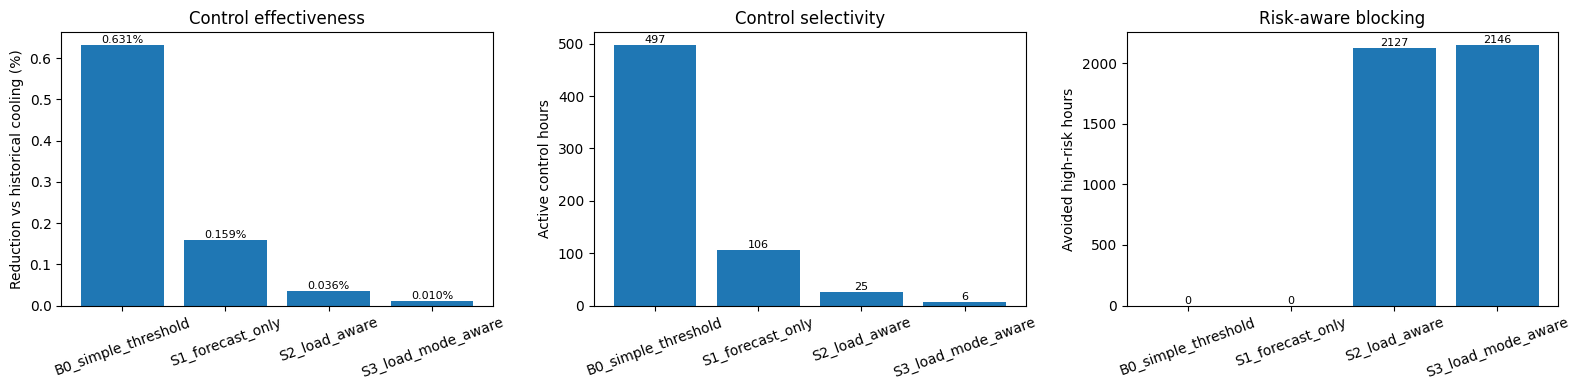

In [254]:
# =========================================================
# CONTROL PERFORMANCE VISUALIZATION
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# A. Reduction effectiveness
bars1 = axes[0].bar(control_perf["strategy"], control_perf["reduction_vs_historical_pct"])
axes[0].set_title("Control effectiveness")
axes[0].set_ylabel("Reduction vs historical cooling (%)")
axes[0].tick_params(axis="x", rotation=20)

for b, h in zip(bars1, control_perf["reduction_vs_historical_pct"]):
    axes[0].text(b.get_x() + b.get_width()/2, h, f"{h:.3f}%", ha="center", va="bottom", fontsize=8)

# B. Selectivity
bars2 = axes[1].bar(control_perf["strategy"], control_perf["active_control_hours"])
axes[1].set_title("Control selectivity")
axes[1].set_ylabel("Active control hours")
axes[1].tick_params(axis="x", rotation=20)

for b, h in zip(bars2, control_perf["active_control_hours"]):
    axes[1].text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=8)

# C. Avoided high-risk hours
bars3 = axes[2].bar(control_perf["strategy"], control_perf["avoided_high_risk_hours"])
axes[2].set_title("Risk-aware blocking")
axes[2].set_ylabel("Avoided high-risk hours")
axes[2].tick_params(axis="x", rotation=20)

for b, h in zip(bars3, control_perf["avoided_high_risk_hours"]):
    axes[2].text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

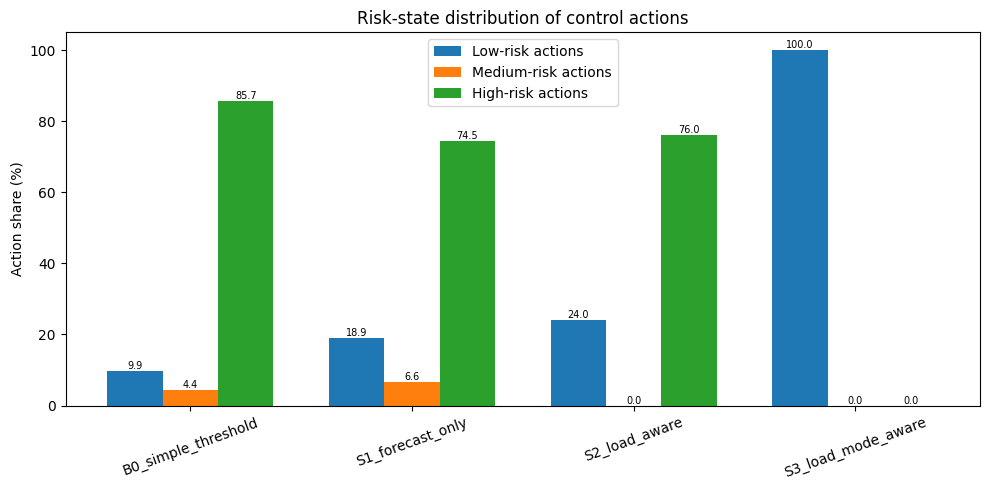

In [255]:
# =========================================================
# CONTROL RISK DISTRIBUTION
# =========================================================

risk_plot_df = control_perf[[
    "strategy",
    "low_risk_action_pct",
    "medium_risk_action_pct",
    "high_risk_action_pct"
]].copy()

x = np.arange(len(risk_plot_df))
w = 0.25

plt.figure(figsize=(10, 5))
b1 = plt.bar(x - w, risk_plot_df["low_risk_action_pct"], width=w, label="Low-risk actions")
b2 = plt.bar(x,     risk_plot_df["medium_risk_action_pct"], width=w, label="Medium-risk actions")
b3 = plt.bar(x + w, risk_plot_df["high_risk_action_pct"], width=w, label="High-risk actions")

plt.xticks(x, risk_plot_df["strategy"], rotation=20)
plt.ylabel("Action share (%)")
plt.title("Risk-state distribution of control actions")
plt.legend()

for bars in [b1, b2, b3]:
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h, f"{h:.1f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# YEAR-SELECTION EVIDENCE FOR SECTION 2.2.4
# Compare 2024, 2025, and current partial year using the
# final cooling-target components later retained in the thesis.
#
# Main output:
# 1) Monthly common hourly coverage heatmap
# 2) Annual summary bar chart
# 3) Summary table for direct thesis reporting
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from datetime import datetime, timezone

# ---------------------------------------------------------
# USER SETTINGS
# ---------------------------------------------------------
SCHEMA_NAME = "reporting"

# Use your actual local site code here when running.
# Keep it out of the thesis text if anonymization is required.
SITE_CODE = "790ZHB"

# Final target components used later in target engineering
ANALYSIS_IDS = [120, 230, 46, 49, 78]

# Start comparison from 2024 because that is the earlier
# available year you want to compare against 2025
START_YEAR = 2024

# Optional: set this if you want to compare only up to a fixed date
# Example: END_TS_OVERRIDE = "2026-04-20 23:59:59 UTC"
END_TS_OVERRIDE = None

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def to_naive_utc(ts_series: pd.Series) -> pd.Series:
    ts = pd.to_datetime(ts_series, errors="coerce", utc=True)
    return ts.dt.tz_convert(None)

def expected_hours_in_month(month_start: pd.Timestamp, analysis_end: pd.Timestamp) -> int:
    """
    Return the number of expected hourly timestamps in the month.
    For fully completed past months: full month hours.
    For the current partial month containing analysis_end: only up to analysis_end.
    For future months beyond analysis_end: 0.
    """
    month_start = pd.Timestamp(month_start)
    month_end = month_start + pd.offsets.MonthBegin(1)

    if month_start > analysis_end:
        return 0

    effective_end = min(month_end, analysis_end + pd.Timedelta(hours=1))
    if effective_end <= month_start:
        return 0

    return int((effective_end - month_start).total_seconds() // 3600)

def safe_pct(num, den):
    return np.nan if den == 0 else 100.0 * num / den

# ---------------------------------------------------------
# STEP 1. LOAD HOURLY AGGREGATED VALUES FOR THE CORE COMPONENTS
# ---------------------------------------------------------
values_sql = ",\n".join(f"({x})" for x in ANALYSIS_IDS)

if END_TS_OVERRIDE is None:
    end_ts_sql = "current_timestamp"
else:
    end_ts_sql = f"TIMESTAMP '{END_TS_OVERRIDE}'"

sql = f"""
WITH candidate_ids (datapoint_id) AS (
    VALUES
    {values_sql}
),
filtered AS (
    SELECT
        m.datapoint_id,
        date_trunc('hour', m.time) AS ts_hour,
        CAST(m.value AS double) AS value_hour
    FROM {SCHEMA_NAME}.measurement m
    INNER JOIN candidate_ids c
        ON m.datapoint_id = c.datapoint_id
    WHERE m.value IS NOT NULL
      AND m.time >= TIMESTAMP '{START_YEAR}-01-01 00:00:00 UTC'
      AND m.time < {end_ts_sql}
)
SELECT
    datapoint_id,
    ts_hour,
    AVG(value_hour) AS value_hour
FROM filtered
GROUP BY datapoint_id, ts_hour
ORDER BY ts_hour, datapoint_id
"""

coverage_long = pd.read_sql(sql, conn)

if coverage_long.empty:
    raise ValueError("No data returned for the selected components and time range.")

coverage_long["ts_hour"] = to_naive_utc(coverage_long["ts_hour"])
coverage_long["datapoint_id"] = coverage_long["datapoint_id"].astype(int)

# ---------------------------------------------------------
# STEP 2. BUILD WIDE HOURLY MATRIX
# ---------------------------------------------------------
wide = (
    coverage_long
    .pivot_table(index="ts_hour", columns="datapoint_id", values="value_hour", aggfunc="mean")
    .sort_index()
)

# Full hourly index across the available period
analysis_start = pd.Timestamp(f"{START_YEAR}-01-01 00:00:00")
analysis_end = wide.index.max().floor("h")

full_index = pd.date_range(start=analysis_start, end=analysis_end, freq="h")
wide = wide.reindex(full_index)
wide.index.name = "ts_hour"

# ---------------------------------------------------------
# STEP 3. MONTHLY COVERAGE METRICS
# ---------------------------------------------------------
# Component-level hourly presence
component_present = wide.notna().astype(int)

# Common hourly presence across all retained components
common_present = component_present.all(axis=1).astype(int)

# Build monthly calendar
month_starts = pd.date_range(
    start=pd.Timestamp(f"{START_YEAR}-01-01"),
    end=analysis_end.normalize().replace(day=1),
    freq="MS"
)

month_rows = []
for month_start in month_starts:
    year_n = month_start.year
    month_n = month_start.month
    month_end = month_start + pd.offsets.MonthBegin(1)

    expected_hours = expected_hours_in_month(month_start, analysis_end)

    mask = (wide.index >= month_start) & (wide.index < month_end)

    # Monthly common coverage
    observed_common_hours = int(common_present.loc[mask].sum()) if expected_hours > 0 else 0
    common_coverage_pct = safe_pct(observed_common_hours, expected_hours)

    # Monthly component coverage
    component_cov = {}
    for cid in ANALYSIS_IDS:
        observed_hours = int(component_present.loc[mask, cid].sum()) if expected_hours > 0 else 0
        component_cov[cid] = safe_pct(observed_hours, expected_hours)

    month_rows.append({
        "year": year_n,
        "month": month_n,
        "month_start": month_start,
        "expected_hours": expected_hours,
        "observed_common_hours": observed_common_hours,
        "common_coverage_pct": common_coverage_pct,
        "min_component_coverage_pct": np.nanmin(list(component_cov.values())),
        "mean_component_coverage_pct": np.nanmean(list(component_cov.values())),
        **{f"cov_{cid}": component_cov[cid] for cid in ANALYSIS_IDS}
    })

monthly_cov = pd.DataFrame(month_rows)

# ---------------------------------------------------------
# STEP 4. ANNUAL SUMMARY TABLE
# ---------------------------------------------------------
summary_rows = []
for year_n, grp in monthly_cov.groupby("year"):
    grp_valid = grp[grp["expected_hours"] > 0].copy()

    summary_rows.append({
        "year": year_n,
        "months_present": int(len(grp_valid)),
        "mean_monthly_common_coverage_pct": grp_valid["common_coverage_pct"].mean(),
        "min_monthly_common_coverage_pct": grp_valid["common_coverage_pct"].min(),
        "months_ge_95pct_common": int((grp_valid["common_coverage_pct"] >= 95).sum()),
        "mean_monthly_component_coverage_pct": grp_valid["mean_component_coverage_pct"].mean(),
        "min_monthly_component_coverage_pct": grp_valid["min_component_coverage_pct"].min()
    })

annual_summary = pd.DataFrame(summary_rows).sort_values("year").reset_index(drop=True)

print("\n=== ANNUAL SUMMARY FOR YEAR-SELECTION JUSTIFICATION ===")
display(annual_summary)

print("\n=== MONTHLY COVERAGE TABLE ===")
display(monthly_cov)

# Optional save
monthly_cov.to_csv("year_selection_monthly_coverage_core_components.csv", index=False)
annual_summary.to_csv("year_selection_annual_summary_core_components.csv", index=False)

# ---------------------------------------------------------
# STEP 5. FIGURE 1 - MONTHLY COMMON COVERAGE HEATMAP
# ---------------------------------------------------------
heatmap_df = (
    monthly_cov
    .pivot(index="year", columns="month", values="common_coverage_pct")
    .sort_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 4.6))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="YlGn", vmin=0, vmax=100)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index.astype(str))

ax.set_title("Monthly common hourly coverage of the core cooling-target components")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

# Annotate cells
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(ScalarMappable(norm=Normalize(0, 100), cmap="YlGn"), ax=ax)
cbar.set_label("Common hourly coverage (%)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# STEP 6. FIGURE 2 - ANNUAL SUMMARY BARS
# ---------------------------------------------------------
plot_df = annual_summary.copy()

x = np.arange(len(plot_df))
w = 0.28

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, plot_df["mean_monthly_common_coverage_pct"], width=w, label="Mean monthly common coverage")
ax.bar(x, plot_df["min_monthly_common_coverage_pct"], width=w, label="Minimum monthly common coverage")
ax.bar(x + w, plot_df["months_ge_95pct_common"], width=w, label="Months with ≥95% common coverage")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["year"].astype(str))
ax.set_title("Annual summary of common coverage for the core cooling-target components")
ax.set_xlabel("Year")
ax.set_ylabel("Value")

for i, row in plot_df.iterrows():
    ax.text(i - w, row["mean_monthly_common_coverage_pct"] + 1, f"{row['mean_monthly_common_coverage_pct']:.1f}", ha="center", fontsize=9)
    ax.text(i, row["min_monthly_common_coverage_pct"] + 1, f"{row['min_monthly_common_coverage_pct']:.1f}", ha="center", fontsize=9)
    ax.text(i + w, row["months_ge_95pct_common"] + 0.2, f"{int(row['months_ge_95pct_common'])}", ha="center", fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# STEP 7. OPTIONAL FIGURE 3 - COMPONENT-LEVEL MONTHLY COVERAGE
# Useful if you want an annex figure for more technical detail
# ---------------------------------------------------------
component_monthly_long = monthly_cov.melt(
    id_vars=["year", "month", "month_start"],
    value_vars=[f"cov_{cid}" for cid in ANALYSIS_IDS],
    var_name="component",
    value_name="coverage_pct"
)
component_monthly_long["component"] = component_monthly_long["component"].str.replace("cov_", "", regex=False)

fig, axes = plt.subplots(len(annual_summary), 1, figsize=(12, 2.6 * len(annual_summary)), sharex=True)

if len(annual_summary) == 1:
    axes = [axes]

for ax, year_n in zip(axes, sorted(component_monthly_long["year"].unique())):
    tmp = component_monthly_long[component_monthly_long["year"] == year_n]
    for cid in sorted(tmp["component"].unique(), key=lambda x: int(x)):
        s = tmp[tmp["component"] == cid]
        ax.plot(s["month"], s["coverage_pct"], marker="o", label=str(cid))
    ax.set_ylim(0, 105)
    ax.set_title(f"Monthly component coverage in {year_n}")
    ax.set_ylabel("Coverage (%)")
    ax.grid(alpha=0.3)

axes[-1].set_xticks(range(1, 13))
axes[-1].set_xticklabels(month_labels)
axes[-1].set_xlabel("Month")
axes[0].legend(title="Datapoint ID", ncol=len(ANALYSIS_IDS), bbox_to_anchor=(1.0, 1.35), loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

SCHEMA_NAME = "reporting"
SITE_CODE = "790ZHB"   # local only, anonymize in thesis
START = pd.Timestamp("2024-01-01")
END = pd.Timestamp.utcnow().floor("h")

# ---------------------------------------------------------
# helper: generate month starts
# ---------------------------------------------------------
month_starts = pd.date_range(
    start=START,
    end=END.replace(day=1),
    freq="MS"
)

rows = []

for month_start in month_starts:
    month_end = month_start + pd.offsets.MonthBegin(1)
    if month_end > END:
        month_end = END + pd.Timedelta(hours=1)

    sql = f"""
    SELECT
        COUNT(*) AS n_rows,
        COUNT(DISTINCT datapoint_id) AS n_active_datapoints,
        MIN(time) AS min_ts,
        MAX(time) AS max_ts
    FROM {SCHEMA_NAME}.measurement_all
    WHERE site_code = '{SITE_CODE}'
      AND value IS NOT NULL
      AND time >= TIMESTAMP '{month_start.strftime("%Y-%m-%d %H:%M:%S")} UTC'
      AND time < TIMESTAMP '{month_end.strftime("%Y-%m-%d %H:%M:%S")} UTC'
    """

    try:
        out = pd.read_sql(sql, conn)
        out = out.iloc[0].to_dict()
    except Exception as e:
        print(f"Failed for {month_start:%Y-%m}: {e}")
        out = {
            "n_rows": np.nan,
            "n_active_datapoints": np.nan,
            "min_ts": pd.NaT,
            "max_ts": pd.NaT,
        }

    rows.append({
        "ts_month": month_start,
        "year": month_start.year,
        "month": month_start.month,
        **out
    })

monthly = pd.DataFrame(rows)

# ---------------------------------------------------------
# clean timestamps
# ---------------------------------------------------------
for col in ["min_ts", "max_ts"]:
    monthly[col] = pd.to_datetime(monthly[col], errors="coerce", utc=True).dt.tz_convert(None)

# ---------------------------------------------------------
# compute continuity proxy
# ---------------------------------------------------------
def month_hours(month_start, end_ts):
    month_start = pd.Timestamp(month_start)
    month_end = month_start + pd.offsets.MonthBegin(1)
    effective_end = min(month_end, end_ts + pd.Timedelta(hours=1))
    return max(0, int((effective_end - month_start).total_seconds() // 3600))

monthly["expected_hours"] = monthly["ts_month"].apply(lambda x: month_hours(x, END))

monthly["observed_span_hours"] = (
    (monthly["max_ts"] - monthly["min_ts"]).dt.total_seconds() / 3600
)

monthly["observed_span_hours"] = monthly["observed_span_hours"].fillna(0)
monthly["span_pct"] = np.where(
    monthly["expected_hours"] > 0,
    monthly["observed_span_hours"] / monthly["expected_hours"] * 100.0,
    np.nan
)

# optional: simple active-datapoint normalization
max_active = monthly["n_active_datapoints"].max()
monthly["active_dp_pct_vs_max"] = monthly["n_active_datapoints"] / max_active * 100.0

print("\n=== MONTHLY SOURCE CONTINUITY SUMMARY ===")
display(monthly)

annual_summary = (
    monthly.groupby("year", as_index=False)
    .agg(
        months_present=("n_rows", lambda s: int((s.fillna(0) > 0).sum())),
        mean_active_datapoints=("n_active_datapoints", "mean"),
        min_active_datapoints=("n_active_datapoints", "min"),
        mean_span_pct=("span_pct", "mean"),
        min_span_pct=("span_pct", "min")
    )
    .sort_values("year")
    .reset_index(drop=True)
)

print("\n=== ANNUAL SUMMARY ===")
display(annual_summary)

# ---------------------------------------------------------
# FIGURE 1: heatmap of monthly span continuity
# ---------------------------------------------------------
heatmap_df = (
    monthly.pivot(index="year", columns="month", values="span_pct")
    .sort_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(11, 4.2))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="YlGn", vmin=0, vmax=100)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index.astype(str))

ax.set_title("Monthly continuity of the selected site measurement layer")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Temporal span within month (%)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 2: active datapoints by month
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))

for year_n in sorted(monthly["year"].unique()):
    tmp = monthly[monthly["year"] == year_n].sort_values("month")
    ax.plot(tmp["month"], tmp["n_active_datapoints"], marker="o", label=str(year_n))

ax.set_title("Monthly active datapoints in the selected site measurement layer")
ax.set_xlabel("Month")
ax.set_ylabel("Active datapoint count")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.grid(alpha=0.3)
ax.legend(title="Year")

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# FIGURE 1: heatmap of monthly span continuity
# Light thesis-ready version: no dark cells, black text only
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

heatmap_df = (
    monthly.pivot(index="year", columns="month", values="span_pct")
    .sort_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Use only the light-to-mid range of Blues, avoiding dark backgrounds
base_cmap = mpl.cm.get_cmap("Blues")
light_colors = base_cmap(np.linspace(0.15, 0.65, 256))
cmap = mpl.colors.ListedColormap(light_colors)
cmap.set_bad(color="#f2f2f2")  # light grey for missing values

data = np.ma.masked_invalid(heatmap_df.values)

fig, ax = plt.subplots(figsize=(11, 4.2), dpi=300)
im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=0, vmax=100)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index.astype(str))

ax.set_title("Monthly continuity of the selected site measurement layer", pad=10)
ax.set_xlabel("Month")
ax.set_ylabel("Year")

# Thin white borders between cells
ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_df.index), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)

# Always use black text
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if pd.notna(val):
            ax.text(
                j, i, f"{val:.0f}%",
                ha="center", va="center",
                fontsize=9, color="black"
            )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Temporal span within month (%)")

plt.tight_layout()
plt.show()

!!!! Show feature in presentation